# SOC Estimation: CAMEL vs CoDA vs Baseline (MLP + KF)


**Experiment**: 50/15/35 random split over 640 tasks (20 batteries × 8 temps × 4 profiles)  
**Goal**: Compare meta-learned models (CAMEL, CoDA) vs. supervised MLP+KF baseline trained only on test data  
**Reference baseline**: He et al. (2014) — *"State of charge estimation for Li-ion batteries using neural network modeling and unscented Kalman filter-based error cancellation"*


## 0. Full-Notebook Output Logging

Everything printed by every cell below (via `print()`) is duplicated to a plain-text log file, in addition to appearing normally in the notebook. Run this cell **first**, before anything else — it must execute before any other cell's `print()` calls happen to capture them all.

In [ ]:
import sys, os
from datetime import datetime

LOG_PATH = "./full_notebook_output_log.txt"

class _Tee:
    """Duplicates every write to both the real stdout and a log file."""
    def __init__(self, filepath, stream):
        self.file = open(filepath, "a", buffering=1)   # line-buffered
        self.stream = stream
    def write(self, data):
        self.stream.write(data)
        self.file.write(data)
    def flush(self):
        self.stream.flush()
        self.file.flush()
    def isatty(self):
        return False

# Guard against re-running this cell wrapping stdout multiple times.
if not isinstance(sys.stdout, _Tee):
    os.makedirs(os.path.dirname(LOG_PATH) or ".", exist_ok=True)
    with open(LOG_PATH, "w") as _f:
        _f.write(f"{'='*70}\n")
        _f.write(f"Notebook run started: {datetime.now().isoformat()}\n")
        _f.write(f"{'='*70}\n\n")
    sys.stdout = _Tee(LOG_PATH, sys.stdout)
    sys.stderr = _Tee(LOG_PATH, sys.stderr)   # also capture warnings/tracebacks
    print(f"[Logging active] All print() output from here on is also being "
          f"saved to: {LOG_PATH}")
else:
    print(f"[Logging already active] Still writing to: {LOG_PATH}")

# ── Suppress the torch.load "weights_only" FutureWarning ────────────────────
# Every torch.load(...) call in this notebook loads checkpoints WE generated
# ourselves earlier in this same pipeline -- there is no untrusted-source
# risk here (the warning exists to flag loading pickle data from elsewhere).
# With dozens of torch.load calls inside loops (the comprehensive sweep alone
# calls it hundreds of times at runtime), leaving this on floods both the
# console and the log file with an identical, non-actionable warning.
import warnings
warnings.filterwarnings("ignore", message=".*weights_only.*", category=FutureWarning)
print("[Warnings] Suppressed torch.load's weights_only FutureWarning "
      "(safe -- all checkpoints are self-generated).")



[Logging active] All print() output from here on is also being saved to: ./full_notebook_output_log.txt
[Warnings] Suppressed torch.load's weights_only FutureWarning (safe -- all checkpoints are self-generated).


Device: cpu
Config loaded.
Loaded 663 files across 21 batteries.
Batteries loaded: ['A123 - simtoreal', 'NCA103450', 'NCA463436A', 'NCA593446', 'NCA623535', 'NCA673440', 'NCA793540', 'NCA843436', 'NCR18500A', 'NCR18650BD', 'NCR18650BF', 'NCR18650PF', 'PD3032', 'T18650', 'UF103450P', 'UF463450F', 'UF553443ZU', 'UF653450S', 'UR18650A', 'UR18650F', 'UR18650ZTA']
Column check passed: ['v', 'i', 'Ts', 'SOC', 'timestamp']
Total tasks: 663
Batteries — Train: 10  Val: 3  Test: 7  Sim2Real: 1  (total: 21)
Tasks     — Train: 319  Val: 96  Test: 224  Sim2Real: 24
Train    batteries: ['UR18650ZTA', 'NCA793540', 'UF463450F', 'NCA673440', 'NCR18650BF', 'UF103450P', 'UF553443ZU', 'UR18650F', 'NCA843436', 'T18650']
Val      batteries: ['UR18650A', 'NCR18650PF', 'NCA463436A']
Test     batteries: ['PD3032', 'NCA593446', 'UF653450S', 'NCR18500A', 'NCR18650BD', 'NCA103450', 'NCA623535']
Sim2Real batteries: ['A123 - simtoreal']
Preprocessing helpers ready (fast concat-once DataLoader).
build_task_homogeneo

## 1. Imports & Shared Hyperparameters

In [2]:
import time
import os, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd


SEED = 42


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ─── SHARED HYPERPARAMETERS — identical across CAMEL, CoDA, and Baseline ────
WINDOW_SIZE   = 60       # timesteps per input window
FEATURE_DIM   = 5        # [v, i, Ts, delta_v, delta_i]
HIDDEN_DIM    = 64       # MLP hidden width (all models)
NUM_LAYERS    = 3        # MLP depth (all models)
R_DIM         = 10       # basis dim (CAMEL omega) = embedding dim (CoDA)
LR            = 2e-3
WEIGHT_DECAY  = 1e-3
EPOCHS        = 2000
# EPOCHS        = 2
RIDGE_LAMBDA  = 1e-3     # CAMEL ridge regularizer
CALIB_FRAC    = 0.10     # calibration fraction (CAMEL/CoDA adaptation)
L1_WEIGHT     = 1e-4     # CoDA lifting sparsity
BATCH_SIZE    = 1024


# KF — shared (same Q/R for all models, for the primary fair comparison)
KF_Q = 1e-5; KF_R = 1e-2


# KF — ad-hoc per-model values (Issue #6: optional separate tuning per model)
# These are used in the *ad-hoc* variant reported alongside the shared-KF results.
# Rationale: meta-learned models produce smoother raw predictions (lower intrinsic noise)
# so they can afford a lower R (trust the NN more); the baseline MLP trained from scratch
# on CALIB_FRAC data is noisier, so a higher R makes the KF smooth more aggressively.
KF_Q_CAMEL = 1e-5; KF_R_CAMEL = 5e-3   # trust CAMEL more (lower R)
KF_Q_CODA  = 1e-5; KF_R_CODA  = 5e-3   # trust CoDA more  (lower R)
KF_Q_BL    = 1e-5; KF_R_BL    = 5e-2   # smooth baseline more (higher R)


# Number of random calibration splits to average over (Issue #5)
EARLY_STOP_VAL_SEEDS = 1   # ONLY used for early-stopping checkpoint
                           # selection during meta-training (val_metric
                           # methods). Has NO effect on any final reported
                           # result -- those are all train-seed-paired
                           # (N_TRAIN_SEEDS) now. Renamed from N_CALIB_SEEDS
                           # to make this distinction unambiguous.
N_TRAIN_SEEDS = 5   # final robustness setting (raised from 3): each
                    # meta-learned method is retrained 5x for the combined
                    # training+calibration seed robustness measurement.


# KF — He et al. (2014) random-walk variant (for direct paper comparison)
# State: SOC_k = SOC_{k-1} + noise  (no physics, no current/capacity)
KF_Q_RW = 1e-5; KF_R_RW = 1e-2   # same Q/R as shared KF; state model differs

feature_cols = ["v", "i", "Ts", "delta_v", "delta_i"]
target_col   = "SOC"


CHECKPOINT_DIR = "./checkpoints"; PLOT_DIR = "./plots"
os.makedirs(CHECKPOINT_DIR, exist_ok=True); os.makedirs(PLOT_DIR, exist_ok=True)
print("Config loaded.")
def get_seed_dir(seed):
    path = os.path.join(CHECKPOINT_DIR, f"seed_{seed}")
    os.makedirs(path, exist_ok=True)
    return path



## 2. Data Loading

> **Adapt this cell** to your dataset.  
> `dataset_runs`: nested dict `{battery_id: {run_name: pd.DataFrame}}`  
> Each DataFrame must have columns: `v`, `i`, `Ts`, `SOC`, `timestamp`  
> Total expected: 640 runs (20 batteries × 8 temperatures × 4 profiles)


In [3]:
# ── USER: replace with your actual data loader ──────────────────────────────
# Example skeleton:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("./dataset_battery")

# ── USER: map your CSV column names to the notebook's expected names ─────────
COL_MAP = {
    "Voltage":          "v",      # adjust key to match your actual CSV header
    "Current":          "i",
    "Temperature_Cell": "Ts",     # or "Ambient_Temp", "T_cell", etc.
    "SOC":              "SOC",    # likely already "SOC"
    # "Time":           "timestamp"  # uncomment if you have an explicit time column
}

battery_folders = sorted([f for f in DATA_DIR.iterdir() if f.is_dir()])
# MAX_BATTERIES = 2   # ← change this to load more later

dataset_runs = {}
all_data_list = []

for battery_folder in battery_folders:   # ← only first 2
    batt_name = battery_folder.name
    dataset_runs[batt_name] = {}

    for csv_file in sorted(battery_folder.glob("*.csv")):
        file_name = csv_file.stem
        df = pd.read_csv(csv_file)
        # df = df.rename(columns=COL_MAP)

        if "timestamp" not in df.columns:
            df["timestamp"] = np.arange(len(df), dtype=np.float32)

        if " - " in file_name:
            parts = file_name.split(" - ", maxsplit=1)
            profile  = parts[0].strip()
            temp_str = parts[1].strip() if len(parts) > 1 else "Unknown"
        else:
            profile, temp_str = file_name, "Unknown"

        if not temp_str:
            temp_str = "Unknown"

        df["Battery"]     = batt_name
        df["Profile"]     = profile
        df["Temperature"] = temp_str

        dataset_runs[batt_name][file_name] = df
        all_data_list.append(df)

df_all = pd.concat(all_data_list, ignore_index=True)
print(f"Loaded {len(all_data_list)} files across {len(dataset_runs)} batteries.")
print(f"Batteries loaded: {list(dataset_runs.keys())}")

for col in ["v", "i", "Ts", "SOC", "timestamp"]:
    assert col in df_all.columns, f"Missing column: {col}. Check COL_MAP."
print("Column check passed:", ["v", "i", "Ts", "SOC", "timestamp"])

In [4]:
display(df_all)


,timestamp,v,i,Ts,SOC,Battery,Profile,Temperature
0,0,3.423737,-0.436118,264.771525,1.000000,A123 - simtoreal,DST,-10
1,1,3.389987,-0.480657,264.841760,0.999886,A123 - simtoreal,DST,-10
2,2,3.378357,-0.480657,264.779393,0.999761,A123 - simtoreal,DST,-10
3,3,3.370172,-0.480657,264.743107,0.999636,A123 - simtoreal,DST,-10
4,4,3.363061,-0.480823,264.836601,0.999511,A123 - simtoreal,DST,-10
...,...,...,...,...,...,...,...,...
13117899,20120,3.028541,-0.957594,323.294002,0.000373,UR18650ZTA,US06,50
13117900,20121,3.023462,-1.222822,323.293992,0.000272,UR18650ZTA,US06,50
13117901,20122,3.020564,-1.289928,323.294156,0.000144,UR18650ZTA,US06,50
13117902,20123,3.022283,-0.999887,323.294370,0.000009,UR18650ZTA,US06,50


In [5]:
# Add delta features
for b in dataset_runs:
    for run_name in dataset_runs[b]:
        df = dataset_runs[b][run_name]
        df["delta_v"] = df["v"].diff().fillna(0)
        df["delta_i"] = df["i"].diff().fillna(0)

# Flatten all 640 tasks
all_tasks = [
    {"battery": b, "run_name": rn, "df": df}
    for b, runs in dataset_runs.items()
    for rn, df in runs.items()
]
print(f"Total tasks: {len(all_tasks)}")
# assert len(all_tasks) == 639, "Expected 639 tasks"

## 3. Battery-Level Split (50 / 15 / 35)

The split is performed at the **battery** level, not the task level.
All runs (temperatures × profiles) from a given battery remain together in one split.
This is the correct protocol: a battery the model has never seen in any condition
should be entirely in the test set — mixing runs from the same battery across
train and test would allow the model to implicitly learn that battery's characteristics.


In [6]:
# ── Battery-level split (50 / 15 / 35) + dedicated sim-to-real holdout ──────
# Each "battery" contributes multiple tasks (runs across temperatures/profiles).
# The split is over BATTERIES so that all runs from one battery stay together.
# This prevents the model from seeing any condition of a test battery during training.
#
# SIM-TO-REAL HOLDOUT: "A123 - simtoreal" is real (not simulated) experimental
# data. It is carved out BEFORE the shuffle/split so it can never land in
# train, val, or test — it is a fourth, fully independent set used only for
# the dedicated sim-to-real evaluation later in the notebook.

SIM2REAL_BATTERY_NAMES = ["A123 - simtoreal"]   # extend this list if more are added

all_batteries_full = list(dataset_runs.keys())
sim2real_batteries  = [b for b in all_batteries_full if b in SIM2REAL_BATTERY_NAMES]
missing_s2r = [b for b in SIM2REAL_BATTERY_NAMES if b not in all_batteries_full]
if missing_s2r:
    print(f"  WARNING: sim-to-real battery name(s) not found in dataset_runs: {missing_s2r}")

all_batteries = [b for b in all_batteries_full if b not in sim2real_batteries]
random.shuffle(all_batteries)   # SEED=42 set globally above

n_batt       = len(all_batteries)
n_train_batt = int(0.50 * n_batt)
n_val_batt   = int(0.15 * n_batt)
n_test_batt  = n_batt - n_train_batt - n_val_batt

train_batteries = all_batteries[:n_train_batt]
val_batteries   = all_batteries[n_train_batt : n_train_batt + n_val_batt]
test_batteries  = all_batteries[n_train_batt + n_val_batt:]

# Expand each battery list into its constituent tasks
train_tasks    = [t for t in all_tasks if t["battery"] in train_batteries]
val_tasks      = [t for t in all_tasks if t["battery"] in val_batteries]
test_tasks     = [t for t in all_tasks if t["battery"] in test_batteries]
sim2real_tasks = [t for t in all_tasks if t["battery"] in sim2real_batteries]

print(f"Batteries — Train: {len(train_batteries)}  Val: {len(val_batteries)}  "
      f"Test: {len(test_batteries)}  Sim2Real: {len(sim2real_batteries)}  "
      f"(total: {len(all_batteries_full)})")
print(f"Tasks     — Train: {len(train_tasks)}  Val: {len(val_tasks)}  "
      f"Test: {len(test_tasks)}  Sim2Real: {len(sim2real_tasks)}")
print(f"Train    batteries: {train_batteries}")
print(f"Val      batteries: {val_batteries}")
print(f"Test     batteries: {test_batteries}")
print(f"Sim2Real batteries: {sim2real_batteries}")


## 4. Preprocessing Helpers

In [7]:
global_scaler = StandardScaler()
global_scaler.fit(np.vstack([t["df"][feature_cols].values.astype(np.float32) for t in train_tasks]))

def make_windows_numpy(df, scaler, window_size=WINDOW_SIZE):
    """Returns contiguous numpy arrays on CPU. Move to device only at batch time."""
    X_raw = scaler.transform(df[feature_cols].values.astype(np.float32))  # (T, d)
    Y_raw = df[target_col].values.astype(np.float32)                       # (T,)
    T, d  = X_raw.shape
    n     = T - window_size
    idx   = np.arange(n)[:, None] + np.arange(window_size)[None, :]       # (n, W)
    X_out = X_raw[idx]                                                     # (n, W, d)
    Y_out = Y_raw[window_size:window_size + n].reshape(n, 1)               # (n, 1)
    t_out = df["timestamp"].values[window_size:window_size + n]
    assert len(X_out) == len(Y_out) == len(t_out), \
        f"Window mismatch: X={len(X_out)}, Y={len(Y_out)}, t={len(t_out)}"
    return np.ascontiguousarray(X_out), np.ascontiguousarray(Y_out), t_out

def build_task_tensors(task_list):
    """Store windows as numpy on CPU — no GPU memory used here."""
    out = []
    for t in task_list:
        X, Y, ts = make_windows_numpy(t["df"], global_scaler)
        out.append({**t, "X": X, "Y": Y, "time": ts})
    return out

def build_loader(prepared_tasks, batch_size=BATCH_SIZE, shuffle=True):
    """
    Concatenate numpy arrays ONCE into CPU tensors, then let PyTorch C++ handle
    all shuffling. Far faster than a Python-level IterableDataset.
    One-time cost: ~30s and ~9 GB RAM for the train split.
    """
    print(f"  Building loader for {len(prepared_tasks)} tasks — concatenating...", end=" ", flush=True)
    all_X    = torch.from_numpy(np.concatenate([t["X"] for t in prepared_tasks], axis=0))
    all_Y    = torch.from_numpy(np.concatenate([t["Y"] for t in prepared_tasks], axis=0))
    all_tidx = torch.cat([
        torch.full((len(t["X"]),), i, dtype=torch.long)
        for i, t in enumerate(prepared_tasks)
    ])
    print(f"done. {all_X.shape[0]:,} windows, X={all_X.element_size()*all_X.nelement()/1e9:.1f} GB")
    ds = TensorDataset(all_X, all_Y, all_tidx)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        pin_memory=(device.type == "cuda"),
        num_workers=2,
        persistent_workers=True,
    )

print("Preprocessing helpers ready (fast concat-once DataLoader).")

def build_task_homogeneous_loader(tasks_prepared, batch_size=BATCH_SIZE, shuffle=True):
    """
    Task-homogeneous DataLoader for CoDA.

    Instead of mixing windows from all tasks in one flat shuffle (which forces
    CoDA's forward() to call functional_call once per unique task per batch),
    this loader yields batches where ALL windows come from the same task.
    This enables the fast path in CoDaModel.forward() — one functional_call
    per batch instead of up to ~320 — reducing CoDA training time from hours
    to minutes while producing identical gradients.

    Structure: for each epoch, tasks are shuffled; within each task, windows
    are shuffled and chunked into batches of `batch_size`. Task boundaries
    never cross a batch boundary.
    """
    import torch
    from torch.utils.data import TensorDataset, DataLoader

    all_loaders = []
    task_order = list(range(len(tasks_prepared)))
    if shuffle:
        import random
        random.shuffle(task_order)

    for tidx in task_order:
        t = tasks_prepared[tidx]
        X = torch.from_numpy(t["X"]).float()
        Y = torch.from_numpy(t["Y"]).float()
        # task index tensor — all same value for this task
        T = torch.full((len(X),), tidx, dtype=torch.long)
        ds = TensorDataset(X, Y, T)
        # Within a task, shuffle windows
        loader = DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                            num_workers=0, pin_memory=True, drop_last=False)
        all_loaders.append(loader)

    # Wrap as a flat iterable that yields (X_b, Y_b, tidx_b) across all tasks
    class ChainedLoader:
        def __init__(self, loaders):
            self.loaders = loaders
        def __iter__(self):
            for loader in self.loaders:
                yield from loader
        def __len__(self):
            return sum(len(l) for l in self.loaders)

    return ChainedLoader(all_loaders)

print("build_task_homogeneous_loader ready.")


## 5. Shared MLP Backbone (identical architecture for all models)

In [8]:
class BasisMLP(nn.Module):
    """Shared windowed MLP: [B, W, d] -> [B, r]. Used by CAMEL and CoDA."""
    def __init__(self, window=WINDOW_SIZE, feat=FEATURE_DIM,
                 hidden=HIDDEN_DIM, r=R_DIM, n_layers=NUM_LAYERS,
                 dropout=0.1):                          # ← add dropout param
        super().__init__()
        in_dim = window * feat
        layers = [nn.Linear(in_dim, hidden), nn.SiLU(), nn.Dropout(dropout)]  # ← after first act
        for _ in range(n_layers - 2):
            layers += [nn.Linear(hidden, hidden), nn.SiLU(), nn.Dropout(dropout)]  # ← after each hidden
        layers.append(nn.Linear(hidden, r))  # ← NO dropout here
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x.view(x.size(0), -1))

class BaselineMLP(nn.Module):
    """Plain MLP for supervised baseline: [B, W, d] -> [B, 1].
       Same architecture as BasisMLP except output dim=1 instead of r."""
    def __init__(self, window=WINDOW_SIZE, feat=FEATURE_DIM,
                 hidden=HIDDEN_DIM, n_layers=NUM_LAYERS,
                 dropout=0.1):                          # ← same default as BasisMLP
        super().__init__()
        in_dim = window * feat
        layers = [nn.Linear(in_dim, hidden), nn.SiLU(), nn.Dropout(dropout)]
        for _ in range(n_layers - 2):
            layers += [nn.Linear(hidden, hidden), nn.SiLU(), nn.Dropout(dropout)]
        layers.append(nn.Linear(hidden, 1))             # ← NO dropout on output
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x.view(x.size(0), -1))

# Verify param counts match (should be identical except last layer diff: r vs 1)
basis_params    = sum(p.numel() for p in BasisMLP().parameters())
baseline_params = sum(p.numel() for p in BaselineMLP().parameters())
print(f"BasisMLP    params: {basis_params:,}   output → r={R_DIM}")
print(f"BaselineMLP params: {baseline_params:,}   output → 1")
print(f"Difference: {abs(basis_params - baseline_params):,}  "
      f"(= last layer: {HIDDEN_DIM}×{R_DIM}+{R_DIM} vs {HIDDEN_DIM}×1+1)")

## 6. CAMEL Model

Prediction: `y = V(x) @ omega_i`  
Adaptation: closed-form ridge regression on calibration set (no gradient required).


In [9]:
class CAMEL(nn.Module):
    def __init__(self, n_tasks, r=R_DIM):
        super().__init__()
        self.v_net  = BasisMLP(r=r)
        self.omegas = nn.Parameter(torch.randn(n_tasks, r, 1) * 0.05)


    def forward(self, x, task_idx):
        V = self.v_net(x)                                       # [B, r]
        omega = self.omegas[task_idx]                           # [B, r, 1]
        return torch.bmm(V.unsqueeze(1), omega).squeeze(1)      # [B, 1]


    def adapt(self, x_calib, y_calib, ridge=RIDGE_LAMBDA):
        """Returns new omega via closed-form ridge regression."""
        with torch.no_grad():
            V = self.v_net(x_calib)
            A = V.T @ V + ridge * torch.eye(V.shape[1], device=V.device)
            return torch.linalg.solve(A, V.T @ y_calib)        # [r, 1]


    @torch.no_grad()
    def predict_with_omega(self, x, omega):
        return (self.v_net(x) @ omega).clamp(0, 1)


    def val_metric(self, val_tasks, ridge=RIDGE_LAMBDA, n_seeds=EARLY_STOP_VAL_SEEDS):
        """
        Adaptation-based val metric evaluated on *validation* tasks only.
        Uses n_seeds different random calibration splits and averages RMSE,
        so early-stopping is not fooled by a lucky calib draw.
        The backbone is frozen during adaptation (no gradient flows to v_net).
        """
        self.eval()
        rmses = []
        with torch.no_grad():
            for t in val_tasks:
                Xs = torch.from_numpy(t["X"]).to(device)
                Ys = torch.from_numpy(t["Y"]).to(device)
                N_c = max(R_DIM * 3, int(CALIB_FRAC * len(Xs)))
                task_rmses = []
                for s in range(n_seeds):
                    g = torch.Generator(device=device); g.manual_seed(s)
                    cidx  = torch.randperm(len(Xs), generator=g, device=device)[:N_c]
                    omega = self.adapt(Xs[cidx], Ys[cidx], ridge=ridge)
                    Yp    = self.predict_with_omega(Xs, omega)
                    task_rmses.append(torch.sqrt(torch.mean((Yp - Ys) ** 2)).item())
                rmses.append(float(np.mean(task_rmses)))
                del Xs, Ys
        return float(np.mean(rmses))


print("CAMEL defined.")


## 7. CoDA Model

Prediction: `y = head(V(x)) + V(x) * dW(e) + db(e)`  
Adaptation: gradient descent on task embedding `e` (backbone + head frozen).


In [10]:
adaptation_step_coda = 40   # L-BFGS typically converges by step 10-15;
                              # lower this once you've confirmed via cell 37's loss-curve plot

# ── CoDA: full-weight hypernetwork (Kirchmeyer et al. 2022) ─────────────────
#
# Architecture (faithful to JAX reference implementation):
#
#   θ_adapted = θ_mlp + lift(e)
#   pred      = MLP(x ; θ_adapted)
#
# The MLP always outputs dimension 1 (SOC prediction).
# The lifting network maps e ∈ R^{emb_size} → Δθ  with the SAME shape as
# every parameter in the MLP backbone.  This is exactly:
#   p_upd = lift.apply(p_lift, e)
#   p_new = tree_map(lambda p, u: p + u, p_mlp, p_upd)
#   preds = mlp.apply(p_new, x)
#
# TRAINING BUG FIX (v4 regression):
#   The previous forward() used  e_unique = e[0:1]  (first sample's embedding).
#   The DataLoader mixes windows from many tasks in one batch.  When task_idx
#   varies within a batch, e[0:1] applies the WRONG task's Δθ to most samples,
#   producing a contradictory gradient signal that collapses training (RMSE=0.05).
#
#   Fix: forward() now groups samples by task_idx and applies the correct Δθ
#   to each group.  This adds one loop over unique tasks per batch but is
#   correct and still fully vectorised within each task group.
# ────────────────────────────────────────────────────────────────────────────

class CoDaModel(nn.Module):
    def __init__(self, n_tasks, r=R_DIM, emb_size=None):
        super().__init__()
        emb_size = emb_size or r
        self.emb_size   = emb_size
        self.backbone   = BaselineMLP(dropout=0.1)   # shared θ_mlp; outputs 1
        self.embeddings = nn.Parameter(torch.randn(n_tasks, emb_size) * 0.01)

        # Lifting: e → flat Δθ of same total size as backbone parameters
        self._backbone_param_shapes = [
            (name, p.shape, p.numel())
            for name, p in self.backbone.named_parameters()
        ]
        total_backbone_params = sum(s for _, _, s in self._backbone_param_shapes)
        self.lifting = nn.Linear(emb_size, total_backbone_params, bias=False)
        nn.init.normal_(self.lifting.weight, std=1e-3)   # start near identity

    # ── Internal helpers ──────────────────────────────────────────────────────
    def _apply_delta(self, delta_flat):
        """Flat Δθ vector → {param_name: delta_tensor} matching backbone."""
        result = {}; offset = 0
        for name, shape, numel in self._backbone_param_shapes:
            result[name] = delta_flat[offset:offset + numel].view(shape)
            offset += numel
        return result

    def _adapted_forward(self, x_flat, e_1d):
        """
        Run backbone with θ_mlp + Δθ(e) on pre-flattened x_flat.
        e_1d: (emb_size,) — single task embedding.
        """
        delta_flat = self.lifting(e_1d)          # (total_params,)
        delta_dict = self._apply_delta(delta_flat)
        adapted_params = {
            name: p + delta_dict[name]
            for name, p in self.backbone.named_parameters()
        }
        try:
            from torch.func import functional_call
            return functional_call(self.backbone, adapted_params, (x_flat,))
        except ImportError:
            # Fallback: temporarily swap weights
            orig = {n: p.data.clone() for n, p in self.backbone.named_parameters()}
            for n, p in self.backbone.named_parameters():
                p.data = adapted_params[n]
            out = self.backbone.net(x_flat)
            for n, p in self.backbone.named_parameters():
                p.data = orig[n]
            return out

    # ── Meta-training forward ─────────────────────────────────────────────────
    def forward(self, x, task_idx):
        """
        Mixed-batch forward: each unique task in task_idx gets its own Δθ.
        Output shape: (B, 1).

        Fast path: if the entire batch belongs to one task (task-homogeneous
        DataLoader, which we use for CoDA to avoid the per-task functional_call
        overhead), we skip the loop and do a single adapted forward pass.
        Fallback: loop over unique tasks — correct but slower for mixed batches.
        """
        x_flat = x.view(x.size(0), -1) if x.dim() == 3 else x
        unique_tids = task_idx.unique()

        if len(unique_tids) == 1:
            # ── Fast path: entire batch is one task ──────────────────────────
            return self._adapted_forward(x_flat, self.embeddings[unique_tids[0]])

        # ── General path: mixed-task batch ───────────────────────────────────
        out = torch.zeros(x_flat.size(0), 1, device=x.device, dtype=x_flat.dtype)
        for tid in unique_tids:
            mask = (task_idx == tid)
            out[mask] = self._adapted_forward(x_flat[mask], self.embeddings[tid])
        return out

    # ── Test-time adaptation ──────────────────────────────────────────────────
    def adapt(self, x_calib, y_calib, n_steps=adaptation_step_coda, lr=1.0,
              optimizer="lbfgs"):
        """
        Optimise a fresh embedding e by gradient descent on x_calib/y_calib.
        backbone + lifting weights are frozen; only e is trainable.

        optimizer="lbfgs" (default): quasi-Newton L-BFGS with a Wolfe line
        search (`strong_wolfe`). e is only `emb_size`-dimensional — exactly
        the small, smooth regime L-BFGS is built for — so it uses curvature
        (history_size=10) instead of a fixed step. The line search re-derives
        a safe step every iteration, so a larger nominal `lr` still converges
        stably; in practice this needs ~10-15 steps instead of ~150-200 for
        Adam (see cell 37's loss-curve plot to confirm on your data).
        optimizer="adam": legacy first-order fallback, kept for comparison /
        debugging.

        Returns (e_detached, loss_history). loss_history always has length
        n_steps so the downstream plotting in cell 37 (np.array(...) over a
        [n_tasks, EARLY_STOP_VAL_SEEDS, n_steps] grid) keeps working unchanged.
        """
        e = nn.Parameter(torch.zeros(self.emb_size, device=x_calib.device))
        x_flat = x_calib.view(x_calib.size(0), -1) if x_calib.dim() == 3 else x_calib
        loss_history = []

        def _loss():
            pred = self._adapted_forward(x_flat, e)
            l1   = self.lifting(e).abs().mean()   # sparsity on Δθ
            return F.mse_loss(pred, y_calib) + L1_WEIGHT * l1

        if optimizer == "lbfgs":
            opt = optim.LBFGS([e], lr=lr, max_iter=1, history_size=10,
                               line_search_fn="strong_wolfe")

            def closure():
                opt.zero_grad()
                loss = _loss()
                loss.backward()
                return loss

            for _ in range(n_steps):
                loss = opt.step(closure)
                loss_history.append(loss.item())
        else:
            opt = optim.Adam([e], lr=lr)
            for _ in range(n_steps):
                opt.zero_grad()
                loss = _loss()
                loss.backward()
                opt.step()
                loss_history.append(loss.item())

        return e.detach(), loss_history

    @torch.no_grad()
    def predict_with_emb(self, x, e):
        """
        e can be (emb_size,) or (1, emb_size) — always normalised to 1-D.
        Returns clamped prediction (B, 1).
        """
        e_1d   = e.view(-1)
        x_flat = x.view(x.size(0), -1) if x.dim() == 3 else x
        return self._adapted_forward(x_flat, e_1d).clamp(0, 1)

    # ── Early-stopping validation metric ─────────────────────────────────────
    def val_metric(self, val_tasks, n_steps=adaptation_step_coda,
                   lr_emb=1.0, n_seeds=EARLY_STOP_VAL_SEEDS):
        self.eval()
        rmses = []
        for t in val_tasks:
            Xs  = torch.from_numpy(t["X"]).float().to(device)
            Ys  = torch.from_numpy(t["Y"]).float().to(device)
            N_c = max(16, int(CALIB_FRAC * len(Xs)))
            task_rmses = []
            for s in range(n_seeds):
                g = torch.Generator(device=device); g.manual_seed(s)
                cidx = torch.randperm(len(Xs), generator=g, device=device)[:N_c]
                e, _ = self.adapt(Xs[cidx], Ys[cidx], n_steps=n_steps, lr=lr_emb)
                Yp   = self.predict_with_emb(Xs, e)
                task_rmses.append(torch.sqrt(torch.mean((Yp - Ys) ** 2)).item())
            rmses.append(float(np.mean(task_rmses)))
            del Xs, Ys
        return float(np.mean(rmses))

print("CoDA (full-weight hypernetwork, corrected mixed-batch forward) defined.")
print(f"  Backbone params : {sum(p.numel() for p in BaselineMLP().parameters()):,}")
n_lift = sum(p.numel() for p in nn.Linear(R_DIM,
    sum(p.numel() for p in BaselineMLP().parameters()), bias=False).parameters())
print(f"  Lifting params  : {n_lift:,}  (emb_size={R_DIM} → total_backbone_params)")

### CoDA (LoRA-style efficient lift) — `emb_size` unchanged at 10

The full-rank flat lift above needs `emb_size × P ≈ 234,890` parameters because it treats each of the `P` backbone parameters as an independent target with its own 10-dim receptor row — ignoring that those `P` parameters are organised into just 3 weight matrices with shared per-layer structure. A LoRA-style per-layer factorization exploits that structure directly: `emb_size` is **unchanged** (still 10 — the full task embedding optimised at test time is exactly as rich as before), but each layer's delta uses its own small `U_l, V_l` basis instead of one giant flat matrix, cutting the weight-lift parameter count from `10 × P` to `10 × Σ(in_l + out_l)` — from ~234,890 down to ~5,570 for this backbone (biases get a small separate flat lift, ~1,290 params, since they're already tiny). Total CoDA parameters: ≈30,300, about **1.3× the backbone** — versus ≈258,400 (≈11×) for the original full-rank version.

In [11]:
class CoDaModelEfficient(nn.Module):
    """
    CoDA with a LoRA-style per-layer low-rank lift. emb_size is UNCHANGED
    (still R_DIM=10 by default) -- the full task embedding is still what
    gets optimised at test time, with the same adaptation richness as the
    original full-rank CoDaModel.

    For each backbone weight matrix W_l in R^{out x in}:
        delta_W_l = U_l @ diag(e) @ V_l^T,   U_l in R^{out x r}, V_l in R^{in x r}
    where r = emb_size and e in R^r is the SAME embedding shared across every
    layer. Parameter count for the weight lift: r * sum_l(out_l + in_l),
    instead of r * P for the flat version -- scales with LAYER WIDTHS summed,
    not with the PRODUCT of widths (matrix size).

    Biases use a small flat Linear(emb_size, total_bias_params) lift, since
    bias vectors are already tiny (no low-rank structure needed there).

    Same external interface as CoDaModel (forward/adapt/predict_with_emb/
    val_metric) -- drop-in compatible with every _sweep_eval_coda call site.
    """
    def __init__(self, n_tasks, r=R_DIM, emb_size=None):
        super().__init__()
        emb_size = emb_size or r
        self.emb_size   = emb_size
        self.backbone   = BaselineMLP(dropout=0.1)
        self.embeddings = nn.Parameter(torch.randn(n_tasks, emb_size) * 0.01)

        self._weight_specs = []   # (name, out_dim, in_dim)
        self._bias_specs   = []   # (name, numel)
        for name, p in self.backbone.named_parameters():
            if p.dim() == 2:
                out_dim, in_dim = p.shape
                self._weight_specs.append((name, out_dim, in_dim))
            else:
                self._bias_specs.append((name, p.numel()))

        self.U = nn.ParameterDict()
        self.V = nn.ParameterDict()
        for name, out_dim, in_dim in self._weight_specs:
            key = name.replace(".", "_")
            self.U[key] = nn.Parameter(torch.randn(out_dim, emb_size) * 0.01)
            self.V[key] = nn.Parameter(torch.randn(in_dim,  emb_size) * 0.01)

        total_bias_params = sum(n for _, n in self._bias_specs)
        if total_bias_params > 0:
            self.bias_lift = nn.Linear(emb_size, total_bias_params, bias=False)
            nn.init.normal_(self.bias_lift.weight, std=1e-3)
        else:
            self.bias_lift = None

    def _apply_delta(self, e_1d):
        """e_1d: (emb_size,) -> {param_name: delta_tensor} matching backbone."""
        result = {}
        for name, out_dim, in_dim in self._weight_specs:
            key = name.replace(".", "_")
            U_l, V_l = self.U[key], self.V[key]        # (out,r), (in,r)
            result[name] = (U_l * e_1d) @ V_l.T          # (out,in)
        if self.bias_lift is not None:
            bias_flat = self.bias_lift(e_1d)
            offset = 0
            for name, numel in self._bias_specs:
                result[name] = bias_flat[offset:offset + numel]
                offset += numel
        return result

    def _adapted_forward(self, x_flat, e_1d):
        delta_dict = self._apply_delta(e_1d)
        adapted_params = {name: p + delta_dict[name]
                          for name, p in self.backbone.named_parameters()}
        from torch.func import functional_call
        return functional_call(self.backbone, adapted_params, (x_flat,))

    def forward(self, x, task_idx):
        x_flat = x.view(x.size(0), -1) if x.dim() == 3 else x
        unique_tids = task_idx.unique()
        if len(unique_tids) == 1:
            return self._adapted_forward(x_flat, self.embeddings[unique_tids[0]])
        out = torch.zeros(x_flat.size(0), 1, device=x.device, dtype=x_flat.dtype)
        for tid in unique_tids:
            mask = (task_idx == tid)
            out[mask] = self._adapted_forward(x_flat[mask], self.embeddings[tid])
        return out

    def adapt(self, x_calib, y_calib, n_steps=adaptation_step_coda, lr=1.0,
              optimizer="lbfgs"):
        e = nn.Parameter(torch.zeros(self.emb_size, device=x_calib.device))
        x_flat = x_calib.view(x_calib.size(0), -1) if x_calib.dim() == 3 else x_calib
        loss_history = []

        def _loss():
            pred = self._adapted_forward(x_flat, e)
            delta_dict = self._apply_delta(e)
            l1 = torch.cat([d.flatten() for d in delta_dict.values()]).abs().mean()
            return F.mse_loss(pred, y_calib) + L1_WEIGHT * l1

        if optimizer == "lbfgs":
            opt = optim.LBFGS([e], lr=lr, max_iter=1, history_size=10,
                               line_search_fn="strong_wolfe")
            def closure():
                opt.zero_grad()
                loss = _loss()
                loss.backward()
                return loss
            for _ in range(n_steps):
                loss = opt.step(closure)
                loss_history.append(loss.item())
        else:
            opt = optim.Adam([e], lr=lr)
            for _ in range(n_steps):
                opt.zero_grad()
                loss = _loss()
                loss.backward()
                opt.step()
                loss_history.append(loss.item())

        return e.detach(), loss_history

    @torch.no_grad()
    def predict_with_emb(self, x, e):
        e_1d   = e.view(-1)
        x_flat = x.view(x.size(0), -1) if x.dim() == 3 else x
        return self._adapted_forward(x_flat, e_1d).clamp(0, 1)

    def val_metric(self, val_tasks, n_steps=adaptation_step_coda,
                   lr_emb=1.0, n_seeds=EARLY_STOP_VAL_SEEDS):
        self.eval()
        rmses = []
        for t in val_tasks:
            Xs  = torch.from_numpy(t["X"]).float().to(device)
            Ys  = torch.from_numpy(t["Y"]).float().to(device)
            N_c = max(16, int(CALIB_FRAC * len(Xs)))
            task_rmses = []
            for s in range(n_seeds):
                g = torch.Generator(device=device); g.manual_seed(s)
                cidx = torch.randperm(len(Xs), generator=g, device=device)[:N_c]
                e, _ = self.adapt(Xs[cidx], Ys[cidx], n_steps=n_steps, lr=lr_emb)
                Yp   = self.predict_with_emb(Xs, e)
                task_rmses.append(torch.sqrt(torch.mean((Yp - Ys) ** 2)).item())
            rmses.append(float(np.mean(task_rmses)))
            del Xs, Ys
        return float(np.mean(rmses))

print("CoDA (LoRA-style efficient lift) defined.")

# Parameter count comparison: flat lift vs LoRA-style lift
_backbone_params = sum(p.numel() for p in BaselineMLP().parameters())
_flat_lift_params = _backbone_params * R_DIM
_lora_model_tmp = CoDaModelEfficient(n_tasks=1, r=R_DIM, emb_size=R_DIM)
_lora_lift_params = (sum(p.numel() for p in _lora_model_tmp.U.values())
                     + sum(p.numel() for p in _lora_model_tmp.V.values())
                     + (sum(p.numel() for p in _lora_model_tmp.bias_lift.parameters())
                        if _lora_model_tmp.bias_lift is not None else 0))
del _lora_model_tmp
print(f"  Backbone params:            {_backbone_params:>10,}")
print(f"  Flat lift (original CoDA):  {_flat_lift_params:>10,}  "
      f"-> total ~{_backbone_params+_flat_lift_params:,} "
      f"({(_backbone_params+_flat_lift_params)/_backbone_params:.1f}x backbone)")
print(f"  LoRA-style lift (efficient):{_lora_lift_params:>10,}  "
      f"-> total ~{_backbone_params+_lora_lift_params:,} "
      f"({(_backbone_params+_lora_lift_params)/_backbone_params:.1f}x backbone)  "
      f"[emb_size still {R_DIM}]")


## 8. Kalman Filter — same Q and R for all models

In [12]:
# ── Cell 8  Kalman Filter – Coulomb-counting state model ────────────────────
# Q and R are fixed (shared or ad-hoc per model).
# C_nom is estimated per-task from the CALIB_FRAC window using Coulomb counting.

KF_Q       = 1e-5;  KF_R       = 1e-2
KF_Q_CAMEL = 1e-5;  KF_R_CAMEL = 5e-3
KF_Q_CODA  = 1e-5;  KF_R_CODA  = 5e-3
KF_Q_BL    = 1e-5;  KF_R_BL    = 5e-2


def compute_c_nom(df_task, calib_idx):
    """
    Estimate nominal capacity C_nom [Coulombs] from the calib window.
    Uses Coulomb counting:  C_nom = ∫|I| dt  /  ΔSOC
    calib_idx indexes into the windowed rows (WINDOW_SIZE: in df_task).
    """
    df_calib = df_task.iloc[WINDOW_SIZE:].iloc[calib_idx.cpu().numpy()]
    ts   = df_calib["timestamp"].values.astype(np.float64)
    curr = df_calib["i"].values.astype(np.float64)
    soc  = df_calib["SOC"].values.astype(np.float64)

    dt      = np.diff(ts, prepend=ts[0])
    ah_int  = np.sum(np.abs(curr) * dt)
    delta_soc = np.abs(soc[-1] - soc[0])

    if delta_soc < 0.02 or ah_int < 1.0:   # degenerate calib segment
        return 3600.0                        # 1 Ah safe fallback
    return float(np.clip(ah_int / delta_soc, 100.0, 1e6))


def kalman_filter_coulomb(z, current, dt, q=KF_Q, r=KF_R, c_nom=3600.0):
    """
    1D Kalman filter with Coulomb-counting state dynamics.
    State  : SOC_k = SOC_{k-1} - (I_k * Δt_k) / C_nom
    Measure: z_k  = SOC_k + noise  (NN output)

    Usage – shared KF (same Q, R for all models):
      kalman_filter_coulomb(Yraw, I_arr, dt_arr, c_nom=c_nom_task)
    Usage – ad-hoc KF (per-model Q, R):
      kalman_filter_coulomb(Yraw, I_arr, dt_arr, q=KF_Q_CAMEL, r=KF_R_CAMEL, c_nom=c_nom_task)
    """
    n      = len(z)
    x      = np.zeros(n);  p = np.zeros(n)
    x[0]   = z[0];         p[0] = 1.0
    dt_arr = np.full(n, dt) if np.isscalar(dt) else np.asarray(dt, dtype=np.float64)

    for k in range(1, n):
        x_pred = np.clip(x[k-1] - (current[k] * dt_arr[k]) / c_nom, 0.0, 1.0)
        p_pred = p[k-1] + q
        K      = p_pred / (p_pred + r)
        x[k]   = np.clip(x_pred + K * (z[k] - x_pred), 0.0, 1.0)
        p[k]   = (1 - K) * p_pred
    return x


print(f"KF ready  shared Q={KF_Q} R={KF_R}")
print(f"Ad-hoc:  CAMEL Q={KF_Q_CAMEL} R={KF_R_CAMEL} | CoDA Q={KF_Q_CODA} R={KF_R_CODA} | BL Q={KF_Q_BL} R={KF_R_BL}")
print("compute_c_nom ready (Coulomb counting over calib window)")

def kalman_filter_random_walk(z, q=KF_Q_RW, r=KF_R_RW):
    """
    He et al. (2014) random-walk Kalman filter.
    State: SOC_k = SOC_{k-1} + noise   (no physics, no current/capacity info)
    Measurement: z_k = SOC_k + noise   (NN output = noisy measurement)
    This matches the KF described in He et al. (2014) exactly.
    Use this for direct comparison against that paper's reported numbers.
    """
    n    = len(z)
    x    = np.zeros(n); p = np.zeros(n)
    x[0] = z[0];        p[0] = 1.0
    for k in range(1, n):
        p_pred = p[k-1] + q
        K      = p_pred / (p_pred + r)
        x[k]   = x[k-1] + K * (z[k] - x[k-1])
        p[k]   = (1 - K) * p_pred
    return np.clip(x, 0.0, 1.0)

print("kalman_filter_random_walk ready  (He et al. 2014 state model)")


## 9. Generic Training Loop

In [13]:
VAL_EVERY = 5

def training_loop(model, train_loader, val_prepared, epochs=EPOCHS, desc="Model"):
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=100, min_lr=1e-5)
    loss_fn = nn.MSELoss()
    train_losses, val_metrics = [], []
    best_val = float("inf"); best_state = None

    for ep in range(epochs):
        model.train()
        ep_loss = 0.0; n = 0
        for X_b, Y_b, tidx_b in train_loader:
            X_b  = X_b.to(device, non_blocking=True)
            Y_b  = Y_b.to(device, non_blocking=True)
            tidx_b = tidx_b.to(device, non_blocking=True)
            optimizer.zero_grad()
            pred = model(X_b, tidx_b)
            # L2 regularisation on task-specific params — safe for both CAMEL and CoDA
            if hasattr(model, "omegas"):
                task_reg = RIDGE_LAMBDA * model.omegas.pow(2).mean()
            elif hasattr(model, "embeddings"):
                task_reg = RIDGE_LAMBDA * model.embeddings.pow(2).mean()
            else:
                task_reg = 0.0
            loss = loss_fn(pred, Y_b) + task_reg
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ep_loss += loss.item() * len(X_b); n += len(X_b)
        train_losses.append(ep_loss / n)

        if (ep + 1) % VAL_EVERY == 0 or ep == epochs - 1:
            val_rmse = model.val_metric(val_prepared)
            val_metrics.append((ep + 1, val_rmse))
            scheduler.step(val_rmse)
            if val_rmse < best_val:
                best_val = val_rmse
                best_state = copy.deepcopy(model.state_dict())
            if (ep + 1) % 200 == 0 or ep == 0:
                print(f"{desc}  Ep {ep+1:4d}  Train={train_losses[-1]:.5f}  "
                      f"Val RMSE={val_rmse:.5f}  Best={best_val:.5f}")

    return train_losses, val_metrics, best_state


## 10. Pre-compute Window Tensors for All Splits


In [14]:
print("Pre-computing sliding windows (CPU numpy)...")
train_prepared    = build_task_tensors(train_tasks)
val_prepared      = build_task_tensors(val_tasks)
test_prepared     = build_task_tensors(test_tasks)
sim2real_prepared = build_task_tensors(sim2real_tasks)   # dedicated sim-to-real holdout

n_train_w = sum(len(t["X"]) for t in train_prepared)
n_val_w   = sum(len(t["X"]) for t in val_prepared)
n_test_w  = sum(len(t["X"]) for t in test_prepared)
n_s2r_w   = sum(len(t["X"]) for t in sim2real_prepared)
print(f"  Train:    {n_train_w:,} windows")
print(f"  Val:      {n_val_w:,} windows")
print(f"  Test:     {n_test_w:,} windows")
print(f"  Sim2Real: {n_s2r_w:,} windows")
mem_mb = (n_train_w + n_val_w + n_test_w + n_s2r_w) * WINDOW_SIZE * FEATURE_DIM * 4 / 1e6
print(f"  Total numpy RAM: ~{mem_mb:.0f} MB")

print("\nBuilding train and val DataLoaders (one-time concat)...")
train_loader_shared = build_loader(train_prepared, shuffle=True)
val_loader_shared   = build_loader(val_prepared,   shuffle=False)
print("Loaders ready.")

## MAML — Model & Function Definitions

Defines `MAMLStaticMLP`, `MAMLWindowedMLP`, `functional_forward`, `maml_inner_update`, `maml_val_metric`, `maml_meta_train`, `maml_test_eval`, and plotting helpers.
**Run this cell once** before either the MAML training cell below or the CAMEL/CoDA training cells — it has no side effects and does not start any training.

In [15]:
def run_inference(X, model_fn, chunk=2048):
    """Run model_fn over X in chunks; returns numpy 1D array."""
    preds = []
    with torch.no_grad():
        for i in range(0, len(X), chunk):
            preds.append(model_fn(X[i:i+chunk]))
    return torch.cat(preds).cpu().numpy().flatten()


_calib_call_counter = [0]   # mutable counter so each call gets a different seed


def get_calib_idx(N, N_c, seed=None):
    """
    Return N_c sorted indices sampled without replacement from [0, N).
    If seed is None (default), a fresh seed is drawn from a global counter
    so that repeated calls across tasks and runs never reuse the same split.
    Pass an explicit integer seed only when reproducibility is required
    (e.g. inside sweep functions that average over multiple seeds themselves).
    Result is always a CPU LongTensor — safe to index both numpy arrays and
    CUDA tensors.
    """
    if seed is None:
        seed = _calib_call_counter[0]
        _calib_call_counter[0] += 1
    g = torch.Generator()   # CPU generator
    g.manual_seed(seed)
    idx, _ = torch.sort(torch.randperm(N, generator=g)[:N_c])
    return idx   # CPU LongTensor


print("Inference helpers ready (get_calib_idx uses rolling seeds by default).")


In [16]:
# ── Cell 22  Jeong & Bae (2022) – Full second-order MAML SOC Meta-Learner ────
#
# Paper: "Estimating battery state-of-charge with a few target training data
#         by meta-learning" (Journal of Power Sources, 2022)
#         Jeong & Bae, Hanyang University
#
# ─────────────────────────────────────────────────────────────────────────────
# WHAT THEY DO  vs  WHAT WE DO  vs  OUR EXTENSIONS
# ─────────────────────────────────────────────────────────────────────────────
#
# Jeong & Bae 2022               │  This notebook (baseline impl.)  │ Extensions added here
# ─────────────────────────────── │ ──────────────────────────────── │ ──────────────────────
# Algorithm    MAML (full 2nd-   │  CAMEL (closed-form ridge)       │  MAML kept 2nd-order
#              order, Finn'17)   │  CoDA  (embed. gradient-descent) │  (no FOMAML approx.)
# Architecture DNN (fully-conn.) │  Shared MLP backbone (BasisMLP)  │  Two DNN variants:
#   Inputs:    V, I, T           │  V, I, Ts, ΔV, ΔI (richer)      │  A) Static  – raw
#   Windowing: NONE (1 timestep) │  WINDOW_SIZE = 60 timesteps      │     single-step (as paper)
#                                │                                   │  B) Windowed – 60-step
#                                │                                   │     (same as CAMEL/CoDA)
# Outer optim  SGD               │  AdamW                           │  AdamW (more stable)
# Inner steps  9 gradient steps  │  CAMEL: closed-form              │  same 9 inner steps
#                                │  CoDA:  100 Adam steps           │
# KF           NOT used          │  Coulomb-counting KF             │  Two variants per DNN:
#                                │                                   │   (i)  no KF  (paper-faithful)
#                                │                                   │   (ii) Coulomb-KF (our extension)
# Data         real batteries    │  simulated (20-battery dataset)  │  same simulated dataset
#
# ─────────────────────────────────────────────────────────────────────────────
# WHY WE DEVIATE FROM THE PAPER  (transparency / fairness motivation)
# ─────────────────────────────────────────────────────────────────────────────
#  1. FULL SECOND-ORDER MAML (not FOMAML)
#     Jeong & Bae use the exact Finn et al. 2017 formulation with second-order
#     gradients through the inner loop.  We honour this by setting
#     create_graph=True in the inner update.  Cost: ~2–3× slower than FOMAML;
#     justified because it is what the paper actually proposes.
#
#  2. STATIC vs WINDOWED DNN INPUT
#     The paper feeds a single timestep (V, I, T) to the DNN.  Our CAMEL/CoDA
#     baseline uses WINDOW_SIZE=60 timestep windows plus derived features
#     (ΔV, ΔI, Ts) for richer temporal context.
#     We implement BOTH to isolate the effect of windowing:
#       • MAMLStatic  – 3 raw features, no windowing   (faithful to paper)
#       • MAMLWindowed – same feature set as CAMEL/CoDA (fair comparison)
#     This lets us attribute any performance gap to architecture choice vs
#     the meta-learning algorithm itself.
#
#  3. COULOMB-KF POST-PROCESSING — reported ALONGSIDE a paper-faithful no-KF row
#     The original paper does not apply a Kalman filter; its headline numbers
#     (MSE 0.0176%, MAE 1.0075% on US06, fine-tuned w/ 96 points, 9 steps) are
#     raw-NN numbers. We add the same Coulomb-counting KF used for CAMEL/CoDA
#     as an *extension*, not a substitution. The summary table below reports
#     THREE modes so the paper-faithful number is never conflated with our
#     extension:
#       (a) raw NN, no KF        ← closest to what the paper actually reports
#       (b) + shared KF
#       (c) + ad-hoc KF
#
#  4. OUTER OPTIMISER: AdamW
#     §4 of the paper states "...an Adam optimizer were used in this study"
#     for pre-training; SGD is only stated explicitly for the 9-step
#     fine-tuning (inner loop, §4.2). So AdamW here (vs. their Adam) is a
#     minor variant of what the paper already used for the outer loop, not
#     a departure from SGD as an earlier version of this comment claimed.
#
#  7. LITERAL PAPER-REPLICATION ROW (MAML-PaperExact)
#     MAML-Static/MAML-Windowed above use CALIB_FRAC (10% of the run, ~1.8-2k
#     points on our tasks) and MAML_N_ININER=25 steps at test time — chosen to
#     match CAMEL/CoDA's own test-time adaptation budget for an apples-to-
#     apples comparison BETWEEN meta-learners on this dataset. That is NOT the
#     same as the paper's actual protocol: a FIXED 96 data points (regardless
#     of run length) and 9 gradient steps (§3, §4.1, Fig. 4), with a 64x4
#     ReLU DNN (§4) rather than our SiLU/NUM_LAYERS-deep backbone. Reusing
#     those numbers unmodified would silently give our models ~20x more
#     adaptation data than the paper's headline claim, making any "vs paper"
#     comparison unfair in our favor. MAML-PaperExact below reproduces the
#     paper's exact fine-tuning budget/architecture as an ADDITIONAL row, so
#     the notebook reports both:
#       (a) MAML-Static / MAML-Windowed  → fair vs CAMEL/CoDA on this dataset
#       (b) MAML-PaperExact              → literal vs Jeong & Bae (2022)'s
#                                           own reported numbers (Table 3)
#
#  5. NO CLAMPING INSIDE ANY LOSS USED FOR GRADIENTS (consistency w/ CAMEL/CoDA)
#     CAMEL and CoDA never clamp inside their adapt()/training loss — clamp(0,1)
#     only appears in their no_grad() inference helpers (predict_with_omega /
#     predict_with_emb). clamp() has zero gradient outside [0,1], so clamping
#     inside a loss that drives an optimizer step silently kills learning
#     signal near the boundaries and creates a train/test mismatch. We now
#     apply the SAME rule everywhere in MAML: meta-train inner+outer loss,
#     maml_val_metric, and the test-time fine-tuning loop are all UNCLAMPED.
#     clamp(0,1) is applied ONLY at final inference (predictions returned to
#     the caller / used for RMSE / fed into the KF), exactly like CAMEL/CoDA.
#
#  6. DROPOUT CONSISTENCY BETWEEN META-TRAIN AND TEST-TIME FINE-TUNING
#     functional_forward() always skips Dropout (so the inner-loop dynamics
#     seen during meta-training never include dropout noise). Previously,
#     test-time fine-tuning used the model's real forward() in .train() mode,
#     which DID apply dropout — a mismatch between the adaptation procedure
#     Φ was optimized for and the one it was evaluated with. Test-time
#     fine-tuning now also goes through functional_forward (dropout-free),
#     matching meta-training exactly. (Eval-mode dropout was already a no-op
#     either way, since nn.Dropout is inactive in .eval(); the fix specifically
#     targets the gradient-step phase, which previously ran in .train() mode.)
#
# ─────────────────────────────────────────────────────────────────────────────
# FULL SECOND-ORDER MAML – HOW IT WORKS
# ─────────────────────────────────────────────────────────────────────────────
#  Meta-training (outer loop, over tasks τᵢ from train_tasks):
#    1. Sample task τᵢ with data Dᵢ = (Xᵢ, Yᵢ)
#    2. Split Dᵢ into support Dᵢˢᵘᵖᵖ  and query Dᵢᵠᵘᵉʳʸ
#    3. Inner loop (create_graph=True → track 2nd-order grads):
#         φᵢ = Φ − α ∇_Φ L(f_Φ, Dᵢˢᵘᵖᵖ)   [N_INNER_STEPS_TR SGD steps]
#    4. Accumulate meta-loss:
#         L_meta += L(f_φᵢ, Dᵢᵠᵘᵉʳʸ)
#    5. Outer update with 2nd-order gradients:
#         Φ ← Φ − β ∇_Φ Σ L_meta          [AdamW step; grads flow through φᵢ]
#
#  Fine-tuning at test time (new battery):
#    1. Take N_INNER_STEPS SGD steps on Dᵗᵃʳᵍᵉᵗ starting from meta-init Φ
#    2. Predict SOC → clamp(0,1) at inference → optionally post-process w/ KF
#
#  ITEM #9 — RESOLVED (previously deferred)
#  Two separate problems were tangled together and are now both fixed:
#
#  (a) Support/query were drawn from calib_frac × N windows, not the full task.
#      CAMEL/CoDA's BasisMLP backbone is fit using the FULL DataLoader (every
#      window of every training task swept each epoch); calib_frac is reserved
#      exclusively for test-time/val-time adapt() calls, never for backbone
#      training. MAML's inner loop was incorrectly calib_frac-restricted even
#      during META-TRAINING, starving the outer loop of signal (and then
#      halving that already-tiny set again via support_frac=0.5). Fixed:
#      support/query are now drawn from the FULL task (all N windows) during
#      meta-training. calib_frac is used ONLY in maml_val_metric and
#      maml_test_eval, exactly mirroring CAMEL/CoDA's adapt() usage pattern.
#
#  (b) One outer step per epoch, with tasks_per_batch == all training tasks,
#      meant the task population was swept exactly once total (since
#      MAML_EPOCHS was being kept at 1 during debugging) and never revisited.
#      Fixed: maml_meta_train now takes a SMALL task-batch per outer step and
#      runs MULTIPLE outer steps per epoch — looping until the full task
#      population has been swept once — the same semantic as one epoch of a
#      CAMEL/CoDA DataLoader (which iterates minibatches until every window of
#      every task has been seen once). MAML_TASKS_BATCH is now a per-OUTER-STEP
#      batch size (CAMEL/CoDA's BATCH_SIZE plays an analogous role at the
#      window level), not "all tasks in one shot."
# ─────────────────────────────────────────────────────────────────────────────

import copy, random
import torch, torch.nn as nn, torch.nn.functional as F
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error


# ── Hyperparameters ───────────────────────────────────────────────────────────
# Inner LR is now per-variant because input dimensionality differs dramatically:
# Static:   3 features  → loss landscape is smooth → 2e-2 works fine
# Windowed: 300 features (60×5) → much higher curvature → 2e-2 overshoots,
#           causing the adaptation loss to INCREASE for steps 1-7 (U-shape).
#           Lower LR prevents overshoot while still converging in 15 steps.
MAML_LR_INNER        = 2e-2    # Static inner-loop α
MAML_LR_INNER_WIND   = 1e-2   # lower LR prevents NaN explosion in 300-dim space    # Windowed inner-loop α (lower — 300-dim input)
MAML_LR_OUTER    = 2e-3     # outer-loop β  (paper uses SGD-0.001; we use AdamW)
MAML_N_INNER     = 25       # inner steps at test-time  (paper: 9)
MAML_N_INNER_TR  = 5        # inner steps during meta-training (faster, common)
MAML_EPOCHS      = 600       # meta-training epochs — now matches CoDA (was 1;
# MAML_EPOCHS      = 1       # meta-training epochs — now matches CoDA (was 1;
                             # safe to raise now that each epoch sweeps the
                             # full task population over many outer steps,
                             # see item #9 fix above)
MAML_TASKS_BATCH = 32       # tasks per OUTER STEP (was: all training tasks in
                             # one outer step). One epoch = enough outer steps
                             # to sweep train_prepared once, shuffled — the
                             # task-level analogue of CAMEL/CoDA's BATCH_SIZE
                             # at the window level.
MAML_CALIB_FRAC   = CALIB_FRAC   # 0.10 – used at val/test time AND as the
                                  # support fraction during meta-training.
                                  # This keeps train/test adaptation budget
                                  # consistent: the inner loop always adapts
                                  # on ~10% of windows, which matches the
                                  # test-time scenario the model will face.
                                  # (Previously the inner loop used 70% of
                                  # all windows — a 7× larger budget than
                                  # available at test time, creating a
                                  # train/test adaptation mismatch.)

# Static DNN input size: 3 raw features per timestep (V, I, T)
MAML_STATIC_IN = 3          # matches the paper's input dimensionality
MAML_GRAD_ACCUM = MAML_TASKS_BATCH 

# ── Literal paper-replication protocol (§3, §4.1, Fig. 4) ────────────────────
# Used ONLY by the MAML-PaperExact model/eval below — MAML_CALIB_FRAC/
# MAML_N_INNER above stay as-is for the MAML-Static/MAML-Windowed rows that
# are meant to be comparable to CAMEL/CoDA's own adaptation budget.
MAML_NC_PAPER        = 96   # fixed number of fine-tuning points (NOT a
                             # fraction of run length — the paper's headline
                             # claim is specifically about this small a
                             # FIXED budget working, regardless of task size)
MAML_N_INNER_PAPER   = 9    # gradient steps at fine-tuning (§4.1)

# ─────────────────────────────────────────────────────────────────────────────
# Architecture A – MAMLStatic (faithful to Jeong & Bae 2022)
#   Input: single timestep → 3 raw features  (no window, no derived features)
#   Same hidden width/depth as BaselineMLP for a fair parameter count.
# ─────────────────────────────────────────────────────────────────────────────
class MAMLStaticMLP(nn.Module):
    """DNN matching the paper: single-timestep input (V, I, T)."""
    def __init__(self, in_dim=MAML_STATIC_IN,
                 hidden=HIDDEN_DIM, depth=NUM_LAYERS, dropout=0.1):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.SiLU()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.SiLU(),
                       nn.Dropout(dropout)]
        layers.append(nn.Linear(hidden, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # x may arrive as (B, WINDOW, FEAT) from the shared pipeline;
        # for the static model we only use the last timestep's raw features.
        if x.dim() == 3:
            x = x[:, -1, :MAML_STATIC_IN]   # (B, 3)
        elif x.dim() == 2 and x.size(1) != MAML_STATIC_IN:
            x = x[:, :MAML_STATIC_IN]
        return self.net(x)


# ─────────────────────────────────────────────────────────────────────────────
# Architecture B – MAMLWindowed (comparable to CAMEL/CoDA)
#   Input: WINDOW_SIZE × FEATURE_DIM  (same as BaselineMLP / BasisMLP)
#   Reuses BaselineMLP verbatim – MAML is a training algorithm, not an arch.
# ─────────────────────────────────────────────────────────────────────────────
# BaselineMLP is already defined in an earlier cell; we alias it here.
MAMLWindowedMLP = BaselineMLP    # identical architecture, different training


# ─────────────────────────────────────────────────────────────────────────────
# Architecture C – MAMLPaperExact (literal reproduction of Jeong & Bae 2022, §4)
#   64 neurons, FOUR hidden layers (paper: "64 neurons and four hidden
#   layers"), ReLU (paper: "a rectified linear unit activation function"),
#   single-timestep (V,I,T) input, no dropout (not mentioned in the paper).
#   Used ONLY for the paper-exact row (see item #7 above) — MAMLStaticMLP
#   stays as the parameter-matched-to-baseline variant used elsewhere.
# ─────────────────────────────────────────────────────────────────────────────
class MAMLPaperExactMLP(nn.Module):
    """Literal reproduction of the DNN in Jeong & Bae (2022), §4."""
    def __init__(self, in_dim=MAML_STATIC_IN, hidden=64, n_hidden_layers=4):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.ReLU()]
        for _ in range(n_hidden_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        layers.append(nn.Linear(hidden, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        if x.dim() == 3:
            x = x[:, -1, :MAML_STATIC_IN]
        elif x.dim() == 2 and x.size(1) != MAML_STATIC_IN:
            x = x[:, :MAML_STATIC_IN]
        return self.net(x)


# ─────────────────────────────────────────────────────────────────────────────
# Functional forward – works for any Sequential of Linear/SiLU/Dropout
# Always skips Dropout (deterministic, no-noise inner loop) — used in BOTH
# meta-training AND test-time fine-tuning for consistency (fix #2 / item 6).
# ─────────────────────────────────────────────────────────────────────────────
def functional_forward(model, x, params):
    """
    Run model.forward using `params` instead of model's own weights.
    Preprocesses input based on model type BEFORE hitting the linear layers.
    Dropout is always skipped — this function is used identically during
    meta-training AND test-time fine-tuning, so the inner-loop dynamics Φ
    was optimized for exactly match the dynamics used at evaluation.
    """
    # ── Step 1: preprocess input identically to model.forward() ──────────────
    if isinstance(model, (MAMLStaticMLP, MAMLPaperExactMLP)):
        # Static / paper-exact: take only last timestep's first 3 features
        if x.dim() == 3:
            x = x[:, -1, :MAML_STATIC_IN]       # (B, WINDOW, FEAT) → (B, 3)
        elif x.dim() == 2 and x.size(1) != MAML_STATIC_IN:
            x = x[:, :MAML_STATIC_IN]            # (B, WINDOW*FEAT) → (B, 3)
        # x is now (B, 3) — matches first Linear(3, hidden)
    else:
        # Windowed (BaselineMLP / MAMLWindowedMLP): flatten window × features
        if x.dim() == 3:
            x = x.view(x.size(0), -1)            # (B, WINDOW, FEAT) → (B, WINDOW*FEAT)
        # x is now (B, WINDOW*FEAT) — matches first Linear(WINDOW*FEAT, hidden)

    # ── Step 2: run the linear stack with fast_weights (dropout always skipped) ─
    param_iter = iter(params.values())
    for layer in list(model.net.children()):
        if isinstance(layer, nn.Linear):
            w, b = next(param_iter), next(param_iter)
            x = F.linear(x, w, b)
        elif isinstance(layer, nn.SiLU):
            x = F.silu(x)
        elif isinstance(layer, nn.ReLU):
            x = F.relu(x)                        # MAMLPaperExactMLP (§4: ReLU)
        elif isinstance(layer, nn.Dropout):
            pass    # always skipped — consistent in meta-train AND fine-tune
    return x


# ─────────────────────────────────────────────────────────────────────────────
# Inner-loop update  (second-order MAML  –  create_graph=True by default)
# Loss is UNCLAMPED (matches CAMEL/CoDA's adapt(); clamp only at inference).
# ─────────────────────────────────────────────────────────────────────────────
def maml_inner_update(model, x_sup, y_sup,
                      lr=MAML_LR_INNER,
                      n_steps=MAML_N_INNER_TR,
                      create_graph=True):          # ← True = full 2nd-order
    """
    Run n_steps of SGD on (x_sup, y_sup) starting from model params.
    Returns fast-weights dict; does NOT mutate model in-place.

    create_graph=True  → second-order MAML (Finn et al. 2017, faithful to paper)
    create_graph=False → FOMAML approximation (faster, not used here)

    Loss is computed on UNCLAMPED predictions (fix #4) — clamp(0,1) has zero
    gradient outside [0,1], so clamping inside a loss used for gradients would
    kill learning signal near the SOC boundaries and create a mismatch with
    how CAMEL/CoDA compute their adaptation loss (also unclamped).
    """
    fast_weights = {n: p.clone()
                    for n, p in model.named_parameters()}

    for _ in range(n_steps):
        pred = functional_forward(model, x_sup, fast_weights)   # unclamped
        loss = F.mse_loss(pred, y_sup)

        if torch.isnan(loss):
            fast_weights = {n: p.clone()
                            for n, p in model.named_parameters()}
            break

        grads = torch.autograd.grad(
            loss, fast_weights.values(),
            create_graph=create_graph,
            allow_unused=True
        )

        _gs   = [g if g is not None else torch.zeros_like(w)
                 for (_, w), g in zip(fast_weights.items(), grads)]
        _norm = torch.sqrt(sum(g.pow(2).sum() for g in _gs))
        _clip = torch.clamp(1.0 / (_norm + 1e-8), max=1.0)
        _gs   = [g * _clip for g in _gs]

        # ── THE ACTUAL FIX ────────────────────────────────────────────────
        # .detach() genuinely severs the autograd graph (unlike calling
        # .requires_grad_(True) alone on an already-True non-leaf tensor,
        # which is a no-op and does NOT cut the graph — verified empirically).
        # When create_graph=True (2nd-order meta-training), detaching at
        # every inner step destroys the path from the final fast weights
        # back through all n_steps to the original model parameters Φ —
        # which is exactly what the outer loop's .backward() needs. This
        # was why Φ.grad was ~0 and the outer loop never moved: clipping
        # was correct, but doing it via detach+reattach silently broke
        # 2nd-order MAML every single inner step.
        # When create_graph=False (test-time fine-tuning / FOMAML), we DO
        # want to detach each step — no 2nd-order signal is needed there,
        # and detaching keeps the graph from growing across many steps.
        if create_graph:
            fast_weights = {
                n: w - lr * g
                for (n, w), g in zip(fast_weights.items(), _gs)
            }
        else:
            fast_weights = {
                n: (w - lr * g).detach().requires_grad_(True)
                for (n, w), g in zip(fast_weights.items(), _gs)
            }

        if any(torch.isnan(w).any() for w in fast_weights.values()):
            fast_weights = {n: p.clone()
                            for n, p in model.named_parameters()}
            break

    return fast_weights


# ─────────────────────────────────────────────────────────────────────────────
# Validation metric  (adaptation-based, multi-seed)
# Adaptation loss now UNCLAMPED (fix #4); RMSE reporting still clamps at
# inference, since that's the number that should reflect physical SOC ∈[0,1].
# Uses functional_forward (fix #2) so dropout is skipped exactly as in meta-training.
# ─────────────────────────────────────────────────────────────────────────────
def maml_val_metric(model, val_tasks_prepared,
                    n_inner=MAML_N_INNER,
                    lr_inner=MAML_LR_INNER,
                    n_seeds=EARLY_STOP_VAL_SEEDS):
    """Fine-tune from Φ on each val task, measure RMSE on the full run."""
    model.eval()
    rmses  = []
    saved  = copy.deepcopy(model.state_dict())
    for t in val_tasks_prepared:
        X = torch.from_numpy(t["X"]).float().to(device)
        Y = torch.from_numpy(t["Y"]).float().to(device)
        N = len(X)
        Nc = max(R_DIM + 3, int(MAML_CALIB_FRAC * N))
        task_rmses = []
        for s in range(n_seeds):
            idx = get_calib_idx(N, Nc, seed=s)

            # ── adaptation: functional_forward, unclamped loss, dropout-free ─
            fast_w = maml_inner_update(
                model, X[idx], Y[idx],
                lr=lr_inner, n_steps=n_inner,
                create_graph=False)   # no need to backprop through val metric

            # ── inference: clamp(0,1) only here, matching CAMEL/CoDA ────────
            with torch.no_grad():
                Yp = functional_forward(model, X, fast_w).clamp(0, 1)
            task_rmses.append(
                torch.sqrt(torch.mean((Yp - Y) ** 2)).item())
        rmses.append(float(np.mean(task_rmses)))
    model.load_state_dict(saved)
    return float(np.mean(rmses))


# ─────────────────────────────────────────────────────────────────────────────
# Meta-training loop  (shared by both DNN variants)
# Outer loss is UNCLAMPED (fix #4) — matches CAMEL/CoDA's training loss.
#
# ITEM #9 FIX: support/query are now drawn from the FULL task (all N windows),
# not calib_frac × N — matching how CAMEL/CoDA's backbone is fit on the full
# DataLoader. Each epoch runs enough outer steps to sweep the entire shuffled
# train_tasks population once, batched MAML_TASKS_BATCH tasks per outer step
# (the task-level analogue of CAMEL/CoDA's window-level BATCH_SIZE).
# ─────────────────────────────────────────────────────────────────────────────
def maml_meta_train(model, train_tasks_prepared, val_tasks_prepared,
                    label="MAML",
                    epochs=MAML_EPOCHS,
                    lr_outer=MAML_LR_OUTER,
                    tasks_per_batch=MAML_TASKS_BATCH,
                    support_frac=0.7,
                    max_support=256,   # cap support windows/task regardless of
                                       # how many windows the task has (avg task
                                       # has ~21.6k windows; 0.7 x that was ~15k
                                       # windows unrolled through 2nd-order
                                       # autograd per task — the main OOM driver)
                    max_query=256,     # cap query windows/task (was: ALL
                                       # remaining windows, ~6.5k/task on avg)
                    n_inner_train=MAML_N_INNER_TR,
                    lr_inner=MAML_LR_INNER):
    """
    Full second-order MAML meta-training.

    One EPOCH = sweep the entire (shuffled) train_tasks_prepared population
    once, `tasks_per_batch` tasks per outer step — the task-level analogue of
    one epoch of CAMEL/CoDA's window-level DataLoader.

    Each outer step:
      1. Take the next `tasks_per_batch` tasks from this epoch's shuffled order.
      2. For each task: split its FULL set of windows into support/query
         (NOT calib_frac-restricted — the backbone should see everything a
         task has to offer during meta-training, exactly as CAMEL/CoDA's
         BasisMLP does via the full DataLoader).
      3. Run `n_inner_train` SGD steps on the support set with
         create_graph=True (2nd-order gradients retained).
      4. Evaluate query loss with fast-weights → accumulate.
      5. Backward through the entire unrolled inner loop → AdamW step on Φ.

    calib_frac is intentionally NOT used anywhere in this function — it is
    reserved for maml_val_metric and maml_test_eval (test-time/val-time
    adaptation budget), matching CAMEL/CoDA's adapt() usage.
    """
    outer_opt = optim.AdamW(model.parameters(), lr=lr_outer,
                            weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        outer_opt, mode='min', factor=0.5, patience=100, min_lr=1e-5)

    train_losses, val_metrics = [], []
    best_val      = float('inf')
    best_state    = None
    global_step   = 0   # counts outer steps across all epochs, for VAL_EVERY

    n_tasks = len(train_tasks_prepared)

    for ep in range(epochs):
        model.train()
        epoch_order = list(train_tasks_prepared)
        random.shuffle(epoch_order)

        epoch_losses = []

        # ── sweep the full task population this epoch, tasks_per_batch at a time ─
                # ── sweep the full task population this epoch, tasks_per_batch at a time ─
        for batch_start in range(0, n_tasks, tasks_per_batch):
            # Filter on CPU (t["X"] is still numpy here) before touching the GPU.
            batch = [t for t in epoch_order[batch_start: batch_start + tasks_per_batch]
                     if len(t["X"]) >= 4]
            if not batch:
                continue

            outer_opt.zero_grad()
            batch_loss_sum = 0.0

            for t in batch:
                X = torch.from_numpy(t["X"]).float().to(device)
                Y = torch.from_numpy(t["Y"]).float().to(device)
                N = len(X)

                # ── support/query: small fixed-size subsets, capped regardless
                # of task size (see max_support/max_query above — this is what
                # was causing the OOM: unbounded per-task window counts).
                perm      = torch.randperm(N, device=X.device)
                n_sup     = min(max(R_DIM + 3, int(support_frac * N)), max_support, N - 1)
                n_qry     = min(N - n_sup, max_query)
                idx_sup   = perm[:n_sup]
                idx_query = perm[n_sup:n_sup + n_qry]

                x_sup, y_sup = X[idx_sup],   Y[idx_sup]
                x_qry, y_qry = X[idx_query], Y[idx_query]

                # ── 2nd-order inner loop (unclamped loss, fix #4) ───────────
                fast_w = maml_inner_update(
                    model, x_sup, y_sup,
                    lr=lr_inner, n_steps=n_inner_train,
                    create_graph=True)           # retain graph for outer BP

                pred_qry  = functional_forward(model, x_qry, fast_w)   # unclamped
                task_loss = F.mse_loss(pred_qry, y_qry)

                # ── backward PER TASK, not accumulated across the whole batch ─
                # Frees each task's 2nd-order graph immediately (peak memory
                # ~1 task) instead of holding all len(batch) graphs alive until
                # a single .backward() at the end (peak memory ~tasks_per_batch
                # x task graph — this was the other half of the OOM).
                # Gradients still accumulate correctly in .grad across repeated
                # backward() calls, matching one backward() on the summed loss.
                (task_loss / len(batch)).backward()
                batch_loss_sum += task_loss.item()

                del X, Y, fast_w, pred_qry, task_loss

            # ── Outer-gradient NaN guard ─────────────────────────────────────
            # clip_grad_norm_ computes ONE total_norm across all parameters.
            # If any task's backward produced a NaN/Inf gradient, total_norm
            # becomes NaN, the clip coefficient becomes NaN, and EVERY
            # gradient gets scaled by NaN — permanently corrupting Φ via
            # optimizer.step(). Detect this BEFORE clipping/stepping and
            # skip the update entirely rather than applying a corrupted step.
            _grad_is_nan = any(
                p.grad is not None and not torch.isfinite(p.grad).all()
                for p in model.parameters()
            )
            if _grad_is_nan:
                print(f"  [WARN] NaN/Inf outer gradient at epoch {ep+1}, "
                      f"batch_start={batch_start} — skipping this outer step "
                      f"(Φ left unchanged)")
                outer_opt.zero_grad()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                outer_opt.step()
                epoch_losses.append(batch_loss_sum / max(len(batch), 1))
                global_step += 1

        if not epoch_losses:
            continue
        train_losses.append(float(np.mean(epoch_losses)))

        if (ep + 1) % 5 == 0 or ep == epochs - 1:
            val_rmse = maml_val_metric(model, val_tasks_prepared,
                                       n_inner=MAML_N_INNER_TR,
                                       lr_inner=lr_inner)
            val_metrics.append((ep + 1, val_rmse))
            scheduler.step(val_rmse)
            _sd_now = model.state_dict()
            _sd_ok  = not any(not torch.isfinite(v).all() for v in _sd_now.values())
            if val_rmse < best_val and val_rmse == val_rmse and _sd_ok:  # not NaN
                best_val   = val_rmse
                best_state = copy.deepcopy(_sd_now)
            elif not _sd_ok:
                print(f"  [WARN] model state_dict contains NaN/Inf at epoch {ep+1} "
                      f"— NOT saving as best_state (keeping previous checkpoint)")
            if (ep + 1) % 5 == 0 or ep == 0:
                print(f"{label}  Ep {ep+1:4d}  "
                      f"Train {train_losses[-1]:.5f}  "
                      f"Val RMSE {val_rmse:.5f}  "
                      f"Best {best_val:.5f}  "
                      f"(outer steps so far: {global_step})")

    if best_state is None:
        # Safety net: if VAL_EVERY never triggered (e.g. epochs < VAL_EVERY),
        # fall back to the final model state rather than returning None.
        best_state = copy.deepcopy(model.state_dict())

    return train_losses, val_metrics, best_state


# ─────────────────────────────────────────────────────────────────────────────
# Test-time evaluation  (shared by both variants)
# Tracks adaptation loss at every inner SGD step per task/seed.
#
# FIXES APPLIED:
#  - fix #2 (dropout): fine-tuning now uses maml_inner_update/functional_forward
#    instead of the model's real forward() in .train() mode, so dropout is
#    skipped exactly as during meta-training (previously dropout WAS active
#    here, a mismatch).
#  - fix #4 (clamp): the fine-tuning loss (and the recorded adaptation-curve
#    loss) is now UNCLAMPED, matching meta-training and CAMEL/CoDA. clamp(0,1)
#    is applied only when producing the final predictions used for RMSE/KF.
# ─────────────────────────────────────────────────────────────────────────────
def maml_test_eval(model, best_state, test_prepared, kf_q, kf_r,
                   label="MAML", lr_inner=None, n_inner=None, n_calib_fixed=None,
                   train_seed=None):
    """
    n_inner: overrides MAML_N_INNER (steps of test-time fine-tuning).
    n_calib_fixed: if given, a FIXED number of calibration points is used for
    every task (paper's protocol — a fixed 96 points, §3/Fig. 4) instead of
    CALIB_FRAC × N (fraction of the task's own length, our internal-fairness
    convention shared with CAMEL/CoDA). See item #7 in the header comment.
    train_seed: if given, the internal calibration-seed loop is replaced by a
    SINGLE pass at seed=train_seed (pairs calib_seed to train_seed, matching
    the convention used everywhere else). If None (default), falls back to
    the original EARLY_STOP_VAL_SEEDS internal sweep.
    """
    if lr_inner is None:
        lr_inner = MAML_LR_INNER

    # ── Sanity check: best_state must be NaN/Inf-free before we use it ──────
    _nan_keys = [k for k, v in best_state.items() if not torch.isfinite(v).all()]
    if _nan_keys:
        raise ValueError(
            f"best_state contains NaN/Inf in {_nan_keys}. "
            "Meta-training produced a corrupted checkpoint. "
            "Reduce MAML_LR_OUTER / MAML_LR_INNER, raise support_frac "
            "(too-small support_frac starves the inner loop and makes the "
            "unrolled 2nd-order graph ill-conditioned), or re-run training "
            "now that the outer-gradient NaN guard is in place."
        )
    if n_inner is None:
        n_inner = MAML_N_INNER
    results, all_adapt_curves = [], []

    for t in test_prepared:
        X     = torch.from_numpy(t["X"]).float().to(device)
        Y     = torch.from_numpy(t["Y"]).float().to(device)
        ts    = t["time"]
        df    = t["df"]
        Ytrue = Y.cpu().numpy().flatten()
        N     = len(X)
        Nc    = min(n_calib_fixed, N - 1) if n_calib_fixed is not None \
                else max(R_DIM + 3, int(CALIB_FRAC * N))

        seed_preds, cnom_est, seed_curves = [], [], []

        _seed_range = [train_seed] if train_seed is not None else range(EARLY_STOP_VAL_SEEDS)
        for s in _seed_range:
            # seed s controls both calib draw and any stochastic ops in fine-tuning
            torch.manual_seed(s)
            idx  = get_calib_idx(N, Nc, seed=s)
            xcal = X[idx]
            ycal = Y[idx]

            # ── FIX: tensors from state_dict have no grad → enable it here ──
            fast_weights = {
                n: p.clone().requires_grad_(True)          # ← THE FIX
                for n, p in best_state.items()
            }

            step_losses = []
            for step in range(n_inner):
                with torch.no_grad():
                    loss_before = F.mse_loss(
                        functional_forward(model, xcal, fast_weights), ycal).item()
                step_losses.append(loss_before)

                pred  = functional_forward(model, xcal, fast_weights)
                loss  = F.mse_loss(pred, ycal)
                grads = torch.autograd.grad(
                    loss, fast_weights.values(),
                    create_graph=False, allow_unused=True)

                # ── Gradient clipping (same norm as meta-train outer step) ─
                # Prevents NaN explosion in high-dim (300-feat) input space.
                _MAX_NORM = 1.0
                _gs = [g if g is not None else torch.zeros_like(w)
                        for (_, w), g in zip(fast_weights.items(), grads)]
                _norm = torch.sqrt(sum(g.pow(2).sum() for g in _gs))
                _coef = torch.clamp(_MAX_NORM / (_norm + 1e-8), max=1.0)
                _gs   = [g * _coef for g in _gs]

                fast_weights = {
                    n: (w - lr_inner * g).detach().requires_grad_(True)
                    for (n, w), g in zip(fast_weights.items(), _gs)
                }

                # ── NaN guard: explosion despite clipping → reset to Φ ────
                if any(torch.isnan(w).any() for w in fast_weights.values()):
                    print(f"  [WARN] NaN weights at step {step}, "
                          f"seed {s} — resetting to meta-init Φ")
                    fast_weights = {n: p.clone().detach().requires_grad_(True)
                                    for n, p in best_state.items()}
                    break

            with torch.no_grad():
                loss_after = F.mse_loss(
                    functional_forward(model, xcal, fast_weights), ycal).item()
            step_losses.append(loss_after)
            seed_curves.append(step_losses)

            with torch.no_grad():
                _pred = run_inference(
                    X, lambda x: functional_forward(
                        model, x, fast_weights).clamp(0, 1))
                if np.isnan(_pred).any():
                    print(f"  [WARN] NaN prediction seed {s} — using meta-init Φ")
                    _fw0  = {n: p.clone() for n, p in best_state.items()}
                    _pred = run_inference(
                        X, lambda x: functional_forward(
                            model, x, _fw0).clamp(0, 1))
                seed_preds.append(_pred)
            cnom_est.append(compute_c_nom(df, idx))

        # mean curve across seeds for this task → (N_INNER+1,)
        task_curve = np.mean(seed_curves, axis=0)
        all_adapt_curves.append(task_curve)

        Yraw   = np.mean(seed_preds, axis=0)
        c_nom  = float(np.mean(cnom_est))
        I_arr  = df["i"].values[WINDOW_SIZE:].astype(np.float64)
        dt_arr = np.diff(ts.astype(np.float64), prepend=ts[0])

        Ykf_shared = kalman_filter_coulomb(Yraw, I_arr, dt_arr, c_nom=c_nom)
        Ykf_adhoc  = kalman_filter_coulomb(Yraw, I_arr, dt_arr,
                                           q=kf_q, r=kf_r, c_nom=c_nom)

        results.append(dict(
            battery=t["battery"], run=t.get("run", t.get("runname", "")),
            true=Ytrue, pred_raw=Yraw,
            pred_kf=Ykf_shared, pred_kf_adhoc=Ykf_adhoc,
            time=ts, c_nom=c_nom,
            adapt_curve=task_curve,           # (N_INNER+1,)
            rmse_raw      =float(np.sqrt(mean_squared_error(Ytrue, Yraw))),
            rmse_kf       =float(np.sqrt(mean_squared_error(Ytrue, Ykf_shared))),
            rmse_kf_adhoc =float(np.sqrt(mean_squared_error(Ytrue, Ykf_adhoc))),
            mae_raw       =float(mean_absolute_error(Ytrue, Yraw)),
            mae_kf        =float(mean_absolute_error(Ytrue, Ykf_shared)),
            mae_kf_adhoc  =float(mean_absolute_error(Ytrue, Ykf_adhoc)),
        ))

    return results, np.array(all_adapt_curves)   # (n_tasks, N_INNER+1)

# ─────────────────────────────────────────────────────────────────────────────
# ── Adaptation-loss plot helper ───────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
def plot_adaptation_loss(adapt_curves_dict, save_path):
    """
    adapt_curves_dict: { label_str : adapt_curves_array (n_tasks, N_INNER+1) }
    Plots:
      Left  – mean ± std across tasks (shaded band)
      Right – per-task curves (light lines) + mean (thick line)
    """
    steps  = np.arange(MAML_N_INNER + 1)
    colors = {"MAML-Static":   "#7a39bb",
              "MAML-Windowed": "#437a22"}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Left: mean ± std ──────────────────────────────────────────────────────
    ax = axes[0]
    for label, curves in adapt_curves_dict.items():
        mu  = curves.mean(axis=0)
        std = curves.std(axis=0)
        c   = colors.get(label, "#006494")
        ax.plot(steps, mu, color=c, lw=2.5, marker='o', ms=5, label=label)
        ax.fill_between(steps, mu - std, mu + std, color=c, alpha=0.18)

    ax.set_title("Adaptation Loss – mean ± std across test tasks")
    ax.set_xlabel(f"Inner SGD step  (0 = meta-init Φ,  {MAML_N_INNER} = adapted)")
    ax.set_ylabel("Calib-set MSE (log scale, unclamped)")
    ax.set_yscale("log")
    ax.set_xticks(steps)
    ax.legend()
    ax.grid(alpha=0.3)

    # ── Right: per-task spaghetti + bold mean ─────────────────────────────────
    ax = axes[1]
    for label, curves in adapt_curves_dict.items():
        c   = colors.get(label, "#006494")
        mu  = curves.mean(axis=0)
        for task_curve in curves:
            ax.plot(steps, task_curve, color=c, lw=0.6, alpha=0.25)
        ax.plot(steps, mu, color=c, lw=2.8, marker='o', ms=5,
                label=f"{label} (mean)")

    ax.set_title("Adaptation Loss – per-task trajectories")
    ax.set_xlabel(f"Inner SGD step  (0 = meta-init Φ,  {MAML_N_INNER} = adapted)")
    ax.set_ylabel("Calib-set MSE (log scale, unclamped)")
    ax.set_yscale("log")
    ax.set_xticks(steps)
    ax.legend()
    ax.grid(alpha=0.3)

    plt.suptitle(
        "MAML Test-Time Adaptation  –  Calibration-set loss at each inner step\n"
        "Left: mean±std  |  Right: individual task curves",
        fontsize=10, y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Adaptation-loss plot saved → {save_path}")

# ─────────────────────────────────────────────────────────────────────────────
# ── Train Variant A: MAML-Static ─────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────


## MAML — Meta-Training & Evaluation

Runs meta-training for MAML-Static and MAML-Windowed, then evaluates on all test tasks.
This cell can be run **before or after** CAMEL/CoDA training — it is fully independent. Running it first lets you see whether MAML is learning before committing to the longer CAMEL/CoDA runs.

In [ ]:
print("=" * 70)
print("Meta-training MAML-Static  (Jeong & Bae 2022 – single-timestep DNN)")
print("=" * 70)

for train_seed in range(N_TRAIN_SEEDS):
    set_seed(train_seed)

    maml_static_model = MAMLStaticMLP().to(device)

    _t0 = time.perf_counter()
    maml_static_train_losses, maml_static_val_metrics, maml_static_best = \
    maml_meta_train(maml_static_model, train_prepared, val_prepared,
                        label="MAML-Static")
    maml_static_train_time_s = time.perf_counter() - _t0
    maml_static_model.load_state_dict(maml_static_best)
    seed_dir = get_seed_dir(train_seed)
    torch.save(maml_static_best,
        os.path.join(seed_dir, "maml_static_best.pt")
    )

print(f"Seed {train_seed}: MAML-Static checkpoint saved. Training time: {maml_static_train_time_s:.1f} s")


# ─────────────────────────────────────────────────────────────────────────────
# ── Train Variant B: MAML-Windowed ───────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("Meta-training MAML-Windowed  (same input as CAMEL/CoDA)")
print("=" * 70)

for train_seed in range(N_TRAIN_SEEDS):
    set_seed(train_seed)

    maml_windowed_model = MAMLWindowedMLP().to(device)

    _t0 = time.perf_counter()
    maml_win_train_losses, maml_win_val_metrics, maml_win_best = \
    maml_meta_train(maml_windowed_model, train_prepared, val_prepared,
                        label="MAML-Windowed",
                        lr_inner=MAML_LR_INNER_WIND)   # lower LR for 300-dim input
    maml_win_train_time_s = time.perf_counter() - _t0
    maml_windowed_model.load_state_dict(maml_win_best)
    seed_dir = get_seed_dir(train_seed)

    torch.save(maml_win_best,
        os.path.join(seed_dir, "maml_windowed_best.pt")
    )

print(f"Seed {train_seed}: MAML-Windowed checkpoint saved. Training time: {maml_win_train_time_s:.1f} s")


# ─────────────────────────────────────────────────────────────────────────────
# ── Train Variant C: MAML-PaperExact (literal Jeong & Bae 2022 architecture) ─
# Meta-training itself is unchanged (same held-out-battery task population,
# same MAML_CALIB_FRAC-based support/query budget as the other variants — the
# paper doesn't specify a pre-training data budget, only the FINE-TUNING
# budget at test time, see item #7). Only test-time eval below differs.
# ─────────────────────────────────────────────────────────────────────────────
# print("=" * 70)
# print("Meta-training MAML-PaperExact  (64x4 ReLU DNN, literal Jeong & Bae 2022 arch)")
# print("=" * 70)

# for train_seed in range(N_TRAIN_SEEDS):
#     set_seed(train_seed)

#     maml_paper_model = MAMLPaperExactMLP().to(device)

#     _t0 = time.perf_counter()
#     maml_paper_train_losses, maml_paper_val_metrics, maml_paper_best = \
#     maml_meta_train(maml_paper_model, train_prepared, val_prepared,
#                         label="MAML-PaperExact")
#     maml_paper_train_time_s = time.perf_counter() - _t0
#     maml_paper_model.load_state_dict(maml_paper_best)
#     seed_dir = get_seed_dir(train_seed)

#     torch.save(maml_paper_best,
#         os.path.join(seed_dir, "maml_paper_exact_best.pt")
#     )

# print(f"Seed {train_seed}: MAML-PaperExact checkpoint saved. Training time: {maml_paper_train_time_s:.1f} s")


# ─────────────────────────────────────────────────────────────────────────────
# ── Run both variants and collect adaptation curves ───────────────────────────
# maml_test_eval now takes the live model (not the class) since fine-tuning
# is purely functional and never mutates it — see docstring above.
# ─────────────────────────────────────────────────────────────────────────────

# Variant A – Static
_t0 = time.perf_counter()
maml_static_results, maml_static_adapt_curves = maml_test_eval(
    maml_static_model, maml_static_best, test_prepared,
    kf_q=KF_Q_BL, kf_r=KF_R_BL, label="MAML-Static")
maml_static_adapt_time_ms = (time.perf_counter() - _t0) / len(test_prepared) * 1e3

maml_static_rmse_raw   = float(np.mean([r["rmse_raw"]      for r in maml_static_results]))
maml_static_mae_raw    = float(np.mean([r["mae_raw"]       for r in maml_static_results]))
maml_static_rmse_kf    = float(np.mean([r["rmse_kf"]       for r in maml_static_results]))
maml_static_rmse_adhoc = float(np.mean([r["rmse_kf_adhoc"] for r in maml_static_results]))
maml_static_mae_kf     = float(np.mean([r["mae_kf"]        for r in maml_static_results]))

print(f"MAML-Static   raw (no KF, paper-faithful)  RMSE={maml_static_rmse_raw:.4f}  MAE={maml_static_mae_raw:.4f}")
print(f"MAML-Static   shared-KF                     RMSE={maml_static_rmse_kf:.4f}  MAE={maml_static_mae_kf:.4f}")
print(f"MAML-Static   ad-hoc-KF                      RMSE={maml_static_rmse_adhoc:.4f}")

# Variant B – Windowed (train-seed-paired: calib_seed=train_seed per checkpoint)
_t0 = time.perf_counter()
_per_seed_win_results = []
for ts_ in range(N_TRAIN_SEEDS):
    seed_dir = get_seed_dir(ts_)
    _maml_win_state = torch.load(os.path.join(seed_dir, "maml_windowed_best.pt"),
                                 map_location=device)
    _m = MAMLWindowedMLP().to(device)
    _res, _ = maml_test_eval(
        _m, _maml_win_state, test_prepared,
        kf_q=KF_Q_BL, kf_r=KF_R_BL, label="MAML-Windowed",
        lr_inner=MAML_LR_INNER_WIND, train_seed=ts_)
    _per_seed_win_results.append(_res)
maml_win_adapt_time_ms = (time.perf_counter() - _t0) / len(test_prepared) / N_TRAIN_SEEDS * 1e3

# Average the N_TRAIN_SEEDS per-task result lists (same task order every time)
maml_win_results = []
for task_idx in range(len(test_prepared)):
    _per_seed_task = [_per_seed_win_results[s][task_idx] for s in range(N_TRAIN_SEEDS)]
    _seed_rmses_kf = [r["rmse_kf"] for r in _per_seed_task]
    _seed_maes_kf  = [r["mae_kf"]  for r in _per_seed_task]
    _base = _per_seed_task[0]   # true/time/battery/run identical across seeds
    maml_win_results.append(dict(
        battery=_base["battery"], run=_base["run"],
        true=_base["true"],
        pred_raw=np.mean([r["pred_raw"] for r in _per_seed_task], axis=0),
        pred_std=np.std( [r["pred_raw"] for r in _per_seed_task], axis=0),
        pred_kf=np.mean([r["pred_kf"] for r in _per_seed_task], axis=0),
        pred_kf_adhoc=np.mean([r["pred_kf_adhoc"] for r in _per_seed_task], axis=0),
        time=_base["time"], c_nom=float(np.mean([r["c_nom"] for r in _per_seed_task])),
        adapt_curve=np.mean([r["adapt_curve"] for r in _per_seed_task], axis=0),
        rmse_raw     =float(np.mean([r["rmse_raw"] for r in _per_seed_task])),
        rmse_kf      =float(np.mean(_seed_rmses_kf)),
        rmse_kf_std  =float(np.std(_seed_rmses_kf)),
        rmse_kf_adhoc=float(np.mean([r["rmse_kf_adhoc"] for r in _per_seed_task])),
        mae_raw      =float(np.mean([r["mae_raw"] for r in _per_seed_task])),
        mae_kf       =float(np.mean(_seed_maes_kf)),
        mae_kf_std   =float(np.std(_seed_maes_kf)),
        mae_kf_adhoc =float(np.mean([r["mae_kf_adhoc"] for r in _per_seed_task])),
        seed_rmses_kf=_seed_rmses_kf,
    ))
maml_win_adapt_curves = np.array([r["adapt_curve"] for r in maml_win_results])
del _per_seed_win_results

maml_win_rmse_raw   = float(np.mean([r["rmse_raw"]      for r in maml_win_results]))
maml_win_mae_raw    = float(np.mean([r["mae_raw"]       for r in maml_win_results]))
maml_win_rmse_kf    = float(np.mean([r["rmse_kf"]       for r in maml_win_results]))
maml_win_rmse_adhoc = float(np.mean([r["rmse_kf_adhoc"] for r in maml_win_results]))
maml_win_mae_kf     = float(np.mean([r["mae_kf"]        for r in maml_win_results]))

print(f"\nMAML-Windowed raw (no KF)  RMSE={maml_win_rmse_raw:.4f}  MAE={maml_win_mae_raw:.4f}")
print(f"MAML-Windowed shared-KF     RMSE={maml_win_rmse_kf:.4f}  MAE={maml_win_mae_kf:.4f}")
print(f"MAML-Windowed ad-hoc-KF      RMSE={maml_win_rmse_adhoc:.4f}")

# Variant C – PaperExact: fixed Nc=96 points, 9 inner steps (§3/§4.1), no
# KF (the paper never applies one — this IS their headline "raw" number).
# _t0 = time.perf_counter()
# maml_paper_results, maml_paper_adapt_curves = maml_test_eval(
#     maml_paper_model, maml_paper_best, test_prepared,
#     kf_q=KF_Q_BL, kf_r=KF_R_BL, label="MAML-PaperExact",
#     lr_inner=MAML_LR_INNER, n_inner=MAML_N_INNER_PAPER,
#     n_calib_fixed=MAML_NC_PAPER)
# maml_paper_adapt_time_ms = (time.perf_counter() - _t0) / len(test_prepared) * 1e3

# maml_paper_rmse_raw = float(np.mean([r["rmse_raw"] for r in maml_paper_results]))
# maml_paper_mae_raw  = float(np.mean([r["mae_raw"]  for r in maml_paper_results]))
# maml_paper_rmse_kf  = float(np.mean([r["rmse_kf"]  for r in maml_paper_results]))
# maml_paper_mae_kf   = float(np.mean([r["mae_kf"]   for r in maml_paper_results]))

# # ── Paper's own units convention ("MSE(%)"/"MAE(%)") ─────────────────────────
# # Cross-checked against Table 3 (RMSE(%) ≈ sqrt(MSE(%)) should be in the same
# # ballpark as MAE(%), e.g. their MAML row: sqrt(0.0176)=0.133% vs MAE=1.0075%
# # — consistent with SOC kept as a [0,1] fraction and BOTH columns scaled by
# # ×100 (not ×100² for MSE) before reporting. We apply the same ×100 scaling
# # to our own fractional errors so the two tables are numerically comparable.
# maml_paper_mse_pct  = (maml_paper_rmse_raw ** 2) * 100
# maml_paper_mae_pct  = maml_paper_mae_raw * 100

# print(f"\nMAML-PaperExact  raw (no KF, literal)  RMSE={maml_paper_rmse_raw:.4f}  MAE={maml_paper_mae_raw:.4f}")
# print(f"MAML-PaperExact  shared-KF  (our extension, paper doesn't use one)  "
#       f"RMSE={maml_paper_rmse_kf:.4f}  MAE={maml_paper_mae_kf:.4f}")
# print(f"\n── Literal comparison vs Jeong & Bae (2022), Table 3 (US06, 96 pts, 9 steps) ──")
# print(f"{'Source':34s} {'MSE(%)':>10s} {'MAE(%)':>10s}")
# print(f"{'Paper (Table 3)':34s} {0.0176:10.4f} {1.0075:10.4f}")
# print(f"{'This notebook (paper-exact cfg)':34s} {maml_paper_mse_pct:10.4f} {maml_paper_mae_pct:10.4f}")
# print("(Same battery data, split, and downstream KF are NOT the same as the "
#       "paper's — this checks protocol fidelity, not an exact number match.)")


# ─────────────────────────────────────────────────────────────────────────────
# ── Adaptation-loss plot ──────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
plot_adaptation_loss(
    adapt_curves_dict={
        "MAML-Static":   maml_static_adapt_curves,
        "MAML-Windowed": maml_win_adapt_curves,
    },
    # save_path=f"{PLOT_DIR}/maml_adaptation_loss.png"
)

# Also save raw curve arrays for later analysis
# np.save(f"{PLOT_DIR}/maml_static_adapt_curves.npy",   maml_static_adapt_curves)
# np.save(f"{PLOT_DIR}/maml_windowed_adapt_curves.npy", maml_win_adapt_curves)


# ─────────────────────────────────────────────────────────────────────────────
# ── Quick summary: how much does adaptation improve loss? ─────────────────────
# ─────────────────────────────────────────────────────────────────────────────
for label, curves in [("MAML-Static",   maml_static_adapt_curves),
                      ("MAML-Windowed", maml_win_adapt_curves)]:
    init_loss  = curves[:, 0].mean()    # loss at Φ (before any adaptation)
    final_loss = curves[:, -1].mean()   # loss after N_INNER steps
    reduction  = (init_loss - final_loss) / init_loss * 100
    print(f"{label:20s}  init MSE={init_loss:.5f}  "
          f"adapted MSE={final_loss:.5f}  "
          f"reduction={reduction:.1f}%")

# ─────────────────────────────────────────────────────────────────────────────
# ── Extended performance table  (5 models × 4 eval modes) ────────────────────
# Fix #6: a dedicated "raw, no KF" row/column is now the headline comparison
# point against the paper's own reported numbers (which never used a KF).
# The shared-KF / ad-hoc-KF columns remain as OUR extension, clearly labelled.
# ─────────────────────────────────────────────────────────────────────────────
# import pandas as pd

# summary = pd.DataFrame({
#     "Model": [
#         "Baseline MLP (He 2014)",
#         "MAML-Static (Jeong & Bae 2022)",
#         "MAML-Windowed (+windowing)",
#         "CAMEL+KF",
#         "CoDA+KF",
#     ],
#     "Input": [
#         f"window×{WINDOW_SIZE}",
#         "single-step (V,I,T)",
#         f"window×{WINDOW_SIZE}",
#         f"window×{WINDOW_SIZE}",
#         f"window×{WINDOW_SIZE}",
#     ],
#     "RMSE (raw, no KF — paper-faithful)": [
#         f"{float(np.mean([r['rmse_raw'] for r in baseline_results])):.4f}",
#         f"{maml_static_rmse_raw:.4f}",
#         f"{maml_win_rmse_raw:.4f}",
#         f"{float(np.mean([r['rmse_raw'] for r in camel_results])):.4f}",
#         f"{float(np.mean([r['rmse_raw'] for r in coda_results])):.4f}",
#     ],
#     "MAE (raw, no KF — paper-faithful)": [
#         f"{float(np.mean([r.get('mae_raw', np.nan) for r in baseline_results])):.4f}"
#             if all('mae_raw' in r for r in baseline_results) else "n/a",
#         f"{maml_static_mae_raw:.4f}",
#         f"{maml_win_mae_raw:.4f}",
#         f"{float(np.mean([r.get('mae_raw', np.nan) for r in camel_results])):.4f}"
#             if all('mae_raw' in r for r in camel_results) else "n/a",
#         f"{float(np.mean([r.get('mae_raw', np.nan) for r in coda_results])):.4f}"
#             if all('mae_raw' in r for r in coda_results) else "n/a",
#     ],
#     "RMSE (+ shared KF, our extension)": [
#         f"{bl_rmse:.4f}",
#         f"{maml_static_rmse_kf:.4f}",
#         f"{maml_win_rmse_kf:.4f}",
#         f"{camel_rmse:.4f}",
#         f"{coda_rmse:.4f}",
#     ],
#     "MAE (+ shared KF, our extension)": [
#         f"{bl_mae:.4f}",
#         f"{maml_static_mae_kf:.4f}",
#         f"{maml_win_mae_kf:.4f}",
#         f"{camel_mae:.4f}",
#         f"{coda_mae:.4f}",
#     ],
#     "Meta-prior": [
#         "No",
#         "Yes – MAML (2nd-order)",
#         "Yes – MAML (2nd-order)",
#         "Yes – CAMEL",
#         "Yes – CoDA",
#     ],
#     "Adaptation": [
#         "Full fine-tune (SGD)",
#         f"{MAML_N_INNER} SGD steps",
#         f"{MAML_N_INNER} SGD steps",
#         "Closed-form ridge",
#         "100 Adam steps (embed)",
#     ],
#     "Δ vs paper": [
#         "–",
#         "outer=AdamW; full-task support/query at meta-train; KF added as extra row",
#         "outer=AdamW; windowed; full-task support/query; KF added as extra row",
#         "N/A (proposed method)",
#         "N/A (proposed method)",
#     ],
# })
# print("\n", summary.to_string(index=False))
# summary.to_csv(f"{PLOT_DIR}/performance_summary_5models.csv", index=False)


# ─────────────────────────────────────────────────────────────────────────────
# ── Training-curve plots  (both variants side by side) ───────────────────────
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, losses, label, color in [
    (axes[0], maml_static_train_losses,  "MAML-Static",   "#7a39bb"),
    (axes[1], maml_win_train_losses,     "MAML-Windowed", "#437a22"),
]:
    ax.plot(losses, color=color, lw=1.5)
    ax.set_title(f"{label} – Meta-Training Loss (2nd-order MAML)")
    ax.set_xlabel("Outer step (epoch)")
    ax.set_ylabel("MSE Loss (log scale, unclamped)")
    ax.set_yscale("log")
    ax.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig(f"{PLOT_DIR}/maml_training_curves.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# ── 6-task SOC traces  ×  4 configurations (2 variants × with/without KF) ───
# ─────────────────────────────────────────────────────────────────────────────
N_SHOW   = min(6, len(maml_static_results))
configs  = [
    ("MAML-Static  (no KF)",       maml_static_results, "pred_raw",     "#7a39bb", 0.9, "-"),
    ("MAML-Static  (+KF)",         maml_static_results, "pred_kf",      "#7a39bb", 0.9, "--"),
    ("MAML-Windowed (no KF)",      maml_win_results,    "pred_raw",     "#437a22", 0.9, "-"),
    ("MAML-Windowed (+KF)",        maml_win_results,    "pred_kf",      "#437a22", 0.9, "--"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()
for k in range(N_SHOW):
    ax = axes[k]
    ax.plot(maml_static_results[k]["time"],
            maml_static_results[k]["true"],
            "k-", lw=2.0, label="True SOC", zorder=5)
    # static – raw
    ax.plot(maml_static_results[k]["time"],
            maml_static_results[k]["pred_raw"],
            color="#7a39bb", lw=0.8, alpha=0.35,
            label=f"Static raw  RMSE={maml_static_results[k]['rmse_raw']:.3f}")
    # static + KF
    ax.plot(maml_static_results[k]["time"],
            maml_static_results[k]["pred_kf"],
            "--", color="#7a39bb", lw=1.8,
            label=f"Static+KF   RMSE={maml_static_results[k]['rmse_kf']:.3f}")
    # windowed – raw
    ax.plot(maml_win_results[k]["time"],
            maml_win_results[k]["pred_raw"],
            color="#437a22", lw=0.8, alpha=0.35,
            label=f"Wind. raw   RMSE={maml_win_results[k]['rmse_raw']:.3f}")
    # windowed + KF
    ax.plot(maml_win_results[k]["time"],
            maml_win_results[k]["pred_kf"],
            "--", color="#437a22", lw=1.8,
            label=f"Wind.+KF    RMSE={maml_win_results[k]['rmse_kf']:.3f}")

    ax.set_title(f"{maml_static_results[k]['battery']} "
                 f"{maml_static_results[k]['run']}", fontsize=8)
    ax.set_xlabel("Time (s)", fontsize=8)
    ax.set_ylabel("SOC", fontsize=8)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=6, loc="lower left")
    ax.grid(alpha=0.3)
for k in range(N_SHOW, 6):
    axes[k].set_visible(False)

plt.suptitle(
    f"MAML (Jeong & Bae 2022, 2nd-order)  –  Static vs Windowed  ×  raw / +KF\n"
    f"Static raw RMSE={maml_static_rmse_raw:.4f} | Static+KF RMSE={maml_static_rmse_kf:.4f}  |  "
    f"Windowed raw RMSE={maml_win_rmse_raw:.4f} | Windowed+KF RMSE={maml_win_rmse_kf:.4f}",
    y=1.02, fontsize=10)
plt.tight_layout()
# plt.savefig(f"{PLOT_DIR}/maml_6tasks_all_variants.png", dpi=150,
#             bbox_inches="tight")
# plt.show()

print(f"\nMAML-Static   RMSE (raw)  min={min(r['rmse_raw'] for r in maml_static_results):.4f}"
      f"  max={max(r['rmse_raw'] for r in maml_static_results):.4f}"
      f"  mean={np.mean([r['rmse_raw'] for r in maml_static_results]):.4f}")
print(f"MAML-Windowed RMSE (raw)  min={min(r['rmse_raw'] for r in maml_win_results):.4f}"
      f"  max={max(r['rmse_raw'] for r in maml_win_results):.4f}"
      f"  mean={np.mean([r['rmse_raw'] for r in maml_win_results]):.4f}")
print(f"\nAll MAML artefacts saved to {PLOT_DIR}/ and {CHECKPOINT_DIR}/")

print(f"\nMAML-Static   RMSE (KF)  min={min(r['rmse_kf'] for r in maml_static_results):.4f}"
      f"  max={max(r['rmse_raw'] for r in maml_static_results):.4f}"
      f"  mean={np.mean([r['rmse_kf'] for r in maml_static_results]):.4f}")
print(f"MAML-Windowed RMSE (KF)  min={min(r['rmse_kf'] for r in maml_win_results):.4f}"
      f"  max={max(r['rmse_raw'] for r in maml_win_results):.4f}"
      f"  mean={np.mean([r['rmse_kf'] for r in maml_win_results]):.4f}")
print(f"\nAll MAML artefacts saved to {PLOT_DIR}/ and {CHECKPOINT_DIR}/")

## 11. Train CAMEL  (50 epochs)

In [13]:
for train_seed in range(N_TRAIN_SEEDS):
    set_seed(train_seed)

    camel_model = CAMEL(n_tasks=len(train_tasks), r=R_DIM).to(device)

    _t0 = time.perf_counter()
    camel_train_loss, camel_val_loss, camel_best_state = training_loop(
        camel_model, train_loader_shared, val_prepared, epochs=35, desc="CAMEL" #35
    )
    camel_train_time_s = time.perf_counter() - _t0

    camel_model.load_state_dict(camel_best_state)

    seed_dir = get_seed_dir(train_seed)
    torch.save(
        {
            "state_dict": camel_best_state,
            "train_loss": camel_train_loss,
            "val_loss": camel_val_loss,
        },
        os.path.join(seed_dir, "camel_best.pt")
    )

print(f"Seed {train_seed}: CAMEL checkpoint saved. Training time: {camel_train_time_s:.1f} s")

CAMEL  Ep    1  Train=0.00209  Val RMSE=0.01170  Best=0.01170
CAMEL checkpoint saved.  Training time: 52.2 s


## 12. CAMEL Training Curve

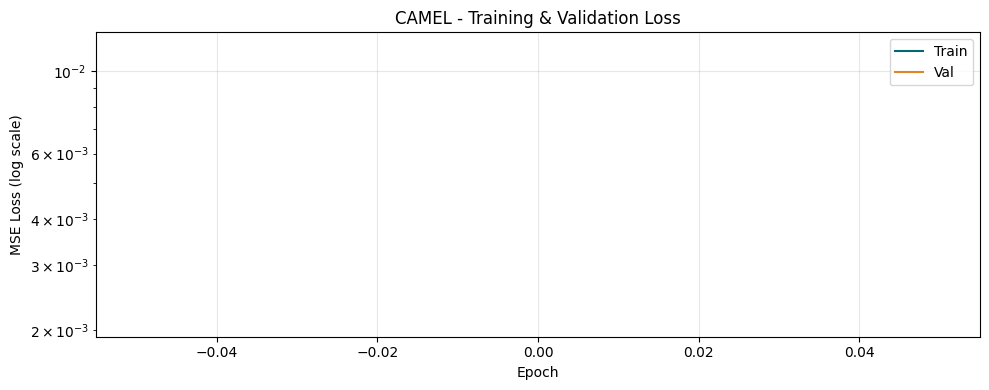

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(camel_train_loss, color="#01696f", linewidth=1.5, label="Train")
ax.plot([i[1] for i in camel_val_loss],   color="#da7101", linewidth=1.5, label="Val", alpha=0.85)
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss (log scale)")
ax.set_title("CAMEL - Training & Validation Loss"); ax.set_yscale("log")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
plt.show()

## 13. Train CoDA  (50 epochs)

In [23]:
# Task-homogeneous loader: each batch contains windows from ONE task only.
# This enables the fast path in CoDaModel.forward(), reducing training
# time from ~38 hours (with mixed-task flat loader + functional_call loop)
# to roughly the same duration as CAMEL.
train_loader_coda = build_task_homogeneous_loader(train_prepared)

for train_seed in range(N_TRAIN_SEEDS):
    set_seed(train_seed)

    coda_model = CoDaModel(n_tasks=len(train_tasks), r=R_DIM, emb_size=R_DIM).to(device)

    _t0 = time.perf_counter()
    coda_train_loss, coda_val_loss, coda_best_state = training_loop(
        coda_model, train_loader_coda, val_prepared, epochs=35, desc="CoDA"
    )
    coda_train_time_s = time.perf_counter() - _t0

    coda_model.load_state_dict(coda_best_state)

    seed_dir = get_seed_dir(train_seed)
    torch.save({"state_dict": coda_best_state,
                "train_loss": coda_train_loss,
                "val_loss":   coda_val_loss},
        os.path.join(seed_dir, "coda_best.pt")
    )

print(f"Seed {train_seed}: CoDA checkpoint saved. Training time: {coda_train_time_s:.1f} s")

  Building loader for 319 tasks — concatenating... 

done. 6,903,787 windows, X=8.3 GB


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fdad27e6440>
Traceback (most recent call last):
  File "/home/mrufolo/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home/mrufolo/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7fdad27e6440>AssertionError
: Traceback (most recent call last):
can only test a child process  File "/home/mrufolo/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__

    self._shutdown_workers()
  File "/home/mrufolo/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_worker

CoDA  Ep    1  Train=0.01070  Val RMSE=0.06538  Best=0.06538
CoDA checkpoint saved.  Training time: 162.2 s


## 14. CoDA Training Curve

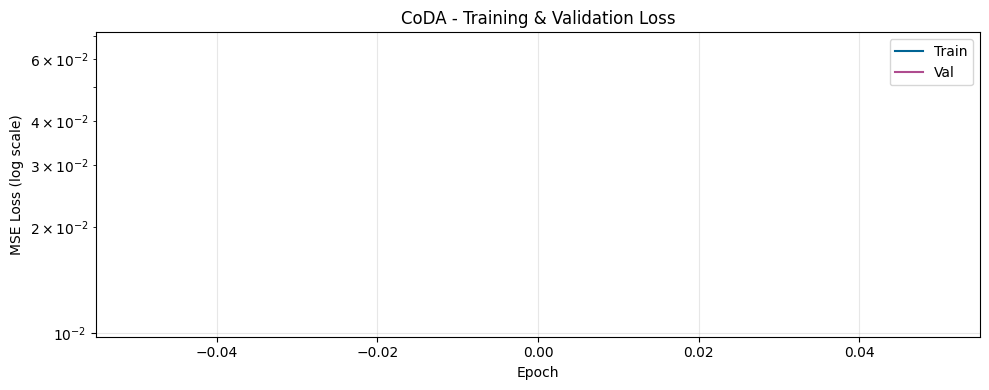

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(coda_train_loss, color="#006494", linewidth=1.5, label="Train")
ax.plot([i[1] for i in coda_val_loss],   color="#a12c7b", linewidth=1.5, label="Val", alpha=0.85)
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss (log scale)")
ax.set_title("CoDA - Training & Validation Loss"); ax.set_yscale("log")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 15. Test - CAMEL Adaptation + KF

Freeze `V(x)`, solve for `omega_new` via ridge regression on `CALIB_FRAC` of each test run.


In [ ]:
camel_results = []
_camel_adapt_times = []

for t in test_prepared:
    X, Y, ts, df = (torch.from_numpy(t["X"]).float().to(device),
                    torch.from_numpy(t["Y"]).float().to(device),
                    t["time"], t["df"])
    Ytrue = Y.cpu().numpy().flatten()
    N  = len(X);  Nc = max(R_DIM + 3, int(CALIB_FRAC * N))

    raw_preds, c_nom_est, seed_adapt_t = [], [], []
    seed_rmses_kf, seed_maes_kf = [], []

    for ts_ in range(N_TRAIN_SEEDS):
        seed_dir = get_seed_dir(ts_)
        ck = torch.load(os.path.join(seed_dir, "camel_best.pt"), map_location=device)
        m  = CAMEL(n_tasks=len(train_tasks), r=R_DIM).to(device)
        m.load_state_dict(ck["state_dict"]); m.eval()

        idx   = get_calib_idx(N, Nc, seed=ts_)   # calib_seed paired to train_seed
        _ta   = time.perf_counter()
        omega = m.adapt(X[idx], Y[idx])
        seed_adapt_t.append(time.perf_counter() - _ta)
        yp_raw = run_inference(X, lambda x: m.predict_with_omega(x, omega))
        raw_preds.append(yp_raw)
        c_nom_est.append(compute_c_nom(df, idx))
        I_arr_s  = df["i"].values[WINDOW_SIZE:].astype(np.float64)
        dt_arr_s = np.diff(ts.astype(np.float64), prepend=ts[0])
        c_nom_s  = compute_c_nom(df, idx)
        Ykf_s    = kalman_filter_coulomb(yp_raw, I_arr_s, dt_arr_s, c_nom=c_nom_s)
        seed_rmses_kf.append(float(np.sqrt(mean_squared_error(Ytrue, Ykf_s))))
        seed_maes_kf.append(float(mean_absolute_error(Ytrue, Ykf_s)))

    _camel_adapt_times.append(float(np.mean(seed_adapt_t)))
    Yraw  = np.mean(raw_preds, axis=0)
    Ystd  = np.std(raw_preds,  axis=0)
    c_nom = float(np.mean(c_nom_est))

    I_arr  = df["i"].values[WINDOW_SIZE:].astype(np.float64)
    dt_arr = np.diff(ts.astype(np.float64), prepend=ts[0])
    Ykf_shared = kalman_filter_coulomb(Yraw, I_arr, dt_arr, c_nom=c_nom)
    Ykf_adhoc  = kalman_filter_coulomb(Yraw, I_arr, dt_arr,
                                       q=KF_Q_CAMEL, r=KF_R_CAMEL, c_nom=c_nom)

    camel_results.append(dict(
        battery=t["battery"], run=t["run_name"],
        true=Ytrue, pred_raw=Yraw, pred_std=Ystd,
        pred_kf=Ykf_shared, pred_kf_adhoc=Ykf_adhoc,
        time=ts, c_nom=c_nom,
        rmse_raw      =float(np.sqrt(mean_squared_error(Ytrue, Yraw))),
        rmse_kf       =float(np.mean(seed_rmses_kf)),
        rmse_kf_std   =float(np.std(seed_rmses_kf)),
        rmse_kf_adhoc =float(np.sqrt(mean_squared_error(Ytrue, Ykf_adhoc))),
        mae_kf        =float(np.mean(seed_maes_kf)),
        mae_kf_std    =float(np.std(seed_maes_kf)),
        mae_kf_adhoc  =float(mean_absolute_error(Ytrue, Ykf_adhoc)),
        seed_rmses_kf =seed_rmses_kf,
    ))

camel_rmse       = float(np.mean([r["rmse_kf"]       for r in camel_results]))
camel_rmse_std   = float(np.mean([r["rmse_kf_std"]   for r in camel_results]))
camel_rmse_adhoc = float(np.mean([r["rmse_kf_adhoc"] for r in camel_results]))
camel_mae        = float(np.mean([r["mae_kf"]        for r in camel_results]))
camel_mae_std    = float(np.mean([r["mae_kf_std"]    for r in camel_results]))
camel_mae_adhoc  = float(np.mean([r["mae_kf_adhoc"]  for r in camel_results]))
camel_adapt_time_ms = float(np.mean(_camel_adapt_times)) * 1e3
print(f"CAMEL shared-KF  RMSE={camel_rmse:.4f} ± {camel_rmse_std:.4f}  "
      f"MAE={camel_mae:.4f} ± {camel_mae_std:.4f}  (train-seed-paired, {N_TRAIN_SEEDS} seeds)")
print(f"CAMEL ad-hoc-KF  RMSE={camel_rmse_adhoc:.4f}")
print(f"CAMEL mean adapt time: {camel_adapt_time_ms:.1f} ms/task  (analytical ridge)")


In [ ]:
# ── 6-task SOC traces with ±1-std seed band ──────────────────────────────────
N_SHOW = min(6, len(camel_results))
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()
for k in range(N_SHOW):
    res = camel_results[k]; ax = axes[k]
    ax.plot(res["time"], res["true"], "k-", lw=2.0, label="True SOC", zorder=3)
    ax.fill_between(res["time"],
                    res["pred_raw"] - res["pred_std"],
                    res["pred_raw"] + res["pred_std"],
                    color="#01696f", alpha=0.18, label=f"Raw NN ±1σ ({N_TRAIN_SEEDS} train-seed-paired evals)")
    ax.plot(res["time"], res["pred_raw"], "-",  color="#01696f", alpha=0.55, lw=0.9)
    ax.plot(res["time"], res["pred_kf"],  "--", color="#01696f", lw=2.0,
            label=f"KF  RMSE={res['rmse_kf']:.3f}±{res['rmse_kf_std']:.3f}")
    ax.set_title(f"{res['battery']} | {res['run']}", fontsize=8)
    ax.set_xlabel("Time (s)", fontsize=8); ax.set_ylabel("SOC", fontsize=8)
    ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=7, loc="lower left"); ax.grid(alpha=0.3)
for k in range(N_SHOW, 6): axes[k].set_visible(False)
plt.suptitle(
    f"CAMEL+KF — 6 sample test tasks  "
    f"(mean RMSE={camel_rmse:.4f} ± {camel_rmse_std:.4f},  {N_TRAIN_SEEDS} train-seed-paired evals)",
    y=1.01)
plt.tight_layout()
# plt.savefig(f"{PLOT_DIR}/camel_6tasks.png", dpi=150, bbox_inches="tight"); plt.show()

# ── RMSE heatmap ──────────────────────────────────────────────────────────────
rmse_vals = np.array([r["rmse_kf"] for r in camel_results])
rmse_std_vals = np.array([r["rmse_kf_std"] for r in camel_results])
n_tasks_test = len(rmse_vals)
side = int(np.ceil(np.sqrt(n_tasks_test)))
grid      = np.full(side * side, np.nan); grid[:n_tasks_test]      = rmse_vals
grid_std  = np.full(side * side, np.nan); grid_std[:n_tasks_test]  = rmse_std_vals
grid      = grid.reshape(side, side); grid_std = grid_std.reshape(side, side)

fig, axes2 = plt.subplots(1, 2, figsize=(16, 6))
for ax2, data, title_sfx in [
        (axes2[0], grid,     "Mean RMSE"),
        (axes2[1], grid_std, "Std RMSE across seeds")]:
    vmax = np.nanpercentile(data, 95)
    im = ax2.imshow(data, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=vmax)
    plt.colorbar(im, ax=ax2, label=title_sfx)
    ax2.set_title(f"CAMEL+KF — {title_sfx} ({n_tasks_test} tasks)")
    ax2.set_xlabel("Task (col)"); ax2.set_ylabel("Task (row)")
plt.tight_layout()
# plt.savefig(f"{PLOT_DIR}/camel_rmse_heatmap.png", dpi=150); plt.show()
print(f"CAMEL: RMSE {rmse_vals.min():.4f}–{rmse_vals.max():.4f}  "
      f"median={np.median(rmse_vals):.4f}  "
      f"mean seed-std={rmse_std_vals.mean():.4f}")


## 16. Test - CoDA Adaptation + KF

In [ ]:
all_coda_adapt_losses = []
coda_results = []
_coda_adapt_times = []

for t in test_prepared:
    X, Y, ts, df = (torch.from_numpy(t["X"]).float().to(device),
                    torch.from_numpy(t["Y"]).float().to(device),
                    t["time"], t["df"])
    Ytrue = Y.cpu().numpy().flatten()
    N  = len(X);  Nc = max(16, int(CALIB_FRAC * N))

    seed_preds, c_nom_est, task_curves, seed_adapt_t = [], [], [], []
    seed_rmses_kf, seed_maes_kf = [], []

    for ts_ in range(N_TRAIN_SEEDS):
        seed_dir = get_seed_dir(ts_)
        ck = torch.load(os.path.join(seed_dir, "coda_best.pt"), map_location=device)
        m  = CoDaModel(n_tasks=len(train_tasks), r=R_DIM, emb_size=R_DIM).to(device)
        m.load_state_dict(ck["state_dict"]); m.eval()

        idx  = get_calib_idx(N, Nc, seed=ts_)   # calib_seed paired to train_seed
        _ta  = time.perf_counter()
        e, loss_curve = m.adapt(X[idx], Y[idx],
                                n_steps=adaptation_step_coda, lr=1e-2)
        seed_adapt_t.append(time.perf_counter() - _ta)
        task_curves.append(loss_curve)
        yp_raw = run_inference(X, lambda x: m.predict_with_emb(x, e))
        seed_preds.append(yp_raw)
        c_nom_est.append(compute_c_nom(df, idx))
        I_arr_s  = df["i"].values[WINDOW_SIZE:].astype(np.float64)
        dt_arr_s = np.diff(ts.astype(np.float64), prepend=ts[0])
        c_nom_s  = compute_c_nom(df, idx)
        Ykf_s    = kalman_filter_coulomb(yp_raw, I_arr_s, dt_arr_s, c_nom=c_nom_s)
        seed_rmses_kf.append(float(np.sqrt(mean_squared_error(Ytrue, Ykf_s))))
        seed_maes_kf.append(float(mean_absolute_error(Ytrue, Ykf_s)))

    all_coda_adapt_losses.append(task_curves)
    _coda_adapt_times.append(float(np.mean(seed_adapt_t)))
    Yraw  = np.mean(seed_preds, axis=0)
    Ystd  = np.std(seed_preds,  axis=0)
    c_nom = float(np.mean(c_nom_est))

    I_arr  = df["i"].values[WINDOW_SIZE:].astype(np.float64)
    dt_arr = np.diff(ts.astype(np.float64), prepend=ts[0])
    Ykf_shared = kalman_filter_coulomb(Yraw, I_arr, dt_arr, c_nom=c_nom)
    Ykf_adhoc  = kalman_filter_coulomb(Yraw, I_arr, dt_arr,
                                       q=KF_Q_CODA, r=KF_R_CODA, c_nom=c_nom)

    coda_results.append(dict(
        battery=t["battery"], run=t["run_name"],
        true=Ytrue, pred_raw=Yraw, pred_std=Ystd,
        pred_kf=Ykf_shared, pred_kf_adhoc=Ykf_adhoc,
        time=ts, c_nom=c_nom,
        rmse_raw      =float(np.sqrt(mean_squared_error(Ytrue, Yraw))),
        rmse_kf       =float(np.mean(seed_rmses_kf)),
        rmse_kf_std   =float(np.std(seed_rmses_kf)),
        rmse_kf_adhoc =float(np.sqrt(mean_squared_error(Ytrue, Ykf_adhoc))),
        mae_kf        =float(np.mean(seed_maes_kf)),
        mae_kf_std    =float(np.std(seed_maes_kf)),
        mae_kf_adhoc  =float(mean_absolute_error(Ytrue, Ykf_adhoc)),
        seed_rmses_kf =seed_rmses_kf,
    ))

coda_rmse       = float(np.mean([r["rmse_kf"]       for r in coda_results]))
coda_rmse_std   = float(np.mean([r["rmse_kf_std"]   for r in coda_results]))
coda_rmse_adhoc = float(np.mean([r["rmse_kf_adhoc"] for r in coda_results]))
coda_mae        = float(np.mean([r["mae_kf"]        for r in coda_results]))
coda_mae_std    = float(np.mean([r["mae_kf_std"]    for r in coda_results]))
coda_mae_adhoc  = float(np.mean([r["mae_kf_adhoc"]  for r in coda_results]))
coda_adapt_time_ms = float(np.mean(_coda_adapt_times)) * 1e3
print(f"CoDA shared-KF  RMSE={coda_rmse:.4f} ± {coda_rmse_std:.4f}  "
      f"MAE={coda_mae:.4f} ± {coda_mae_std:.4f}  (train-seed-paired, {N_TRAIN_SEEDS} seeds)")
print(f"CoDA ad-hoc-KF  RMSE={coda_rmse_adhoc:.4f}")
print(f"CoDA mean adapt time: {coda_adapt_time_ms:.1f} ms/task  "
      f"({adaptation_step_coda} Adam steps)")


In [ ]:
# all_coda_adapt_losses: [n_tasks, N_CALIB_SEEDS, n_steps]
curves = np.array(all_coda_adapt_losses)   # [n_tasks, N_TRAIN_SEEDS, 100]  (one curve per train-seed-paired eval)
mean_over_seeds = curves.mean(axis=1)      # [n_tasks, 100]
global_mean     = mean_over_seeds.mean(axis=0)
global_std      = mean_over_seeds.std(axis=0)
steps = np.arange(1, curves.shape[-1] + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: all task curves + mean ─────────────────────────────────────────────
ax = axes[0]
for curve in mean_over_seeds:
    ax.plot(steps, curve, color="#006494", alpha=0.08, linewidth=0.8)
ax.plot(steps, global_mean, color="#006494", linewidth=2.5, label="Mean across tasks")
ax.fill_between(steps,
                global_mean - global_std,
                global_mean + global_std,
                color="#006494", alpha=0.15, label="±1 std")
ax.set_xlabel("Adaptation step"); ax.set_ylabel("MSE + L1 loss")
ax.set_yscale("log"); ax.set_title("CoDA — Adaptation Loss per Task")
ax.legend(); ax.grid(alpha=0.3, which="both")

# ── Right: seed variance for a single task (first test task) ─────────────────
ax2 = axes[1]
task_idx = 0
for s, curve in enumerate(curves[task_idx]):
    ax2.plot(steps, curve, linewidth=1.5, alpha=0.8,
             label=f"Seed {s}")
ax2.plot(steps, curves[task_idx].mean(axis=0),
         color="black", linewidth=2, linestyle="--", label="Mean")
t0 = coda_results[task_idx]
ax2.set_title(f"Seed variance — Task 0 ({t0['battery']} / {t0['run']})\n"
              f"N_c={max(R_DIM*3, int(CALIB_FRAC * len(test_prepared[0]['X'])))}")
ax2.set_xlabel("Adaptation step"); ax2.set_ylabel("MSE + L1 loss")
ax2.set_yscale("log"); ax2.legend(fontsize=8); ax2.grid(alpha=0.3, which="both")

plt.suptitle(f"CoDA Embedding Adaptation Convergence  |  100 steps  |  lr=5e-3  |  "
             f"{len(coda_results)} test tasks × {N_TRAIN_SEEDS} train-seed-paired evals", fontsize=11)
plt.tight_layout()
# plt.savefig(f"{PLOT_DIR}/coda_adaptation_loss.png", dpi=150)
plt.show()

# Quick convergence check
pct_drop = (global_mean[0] - global_mean[-1]) / global_mean[0] * 100
print(f"Loss drop from step 1 → 100:  {global_mean[0]:.5f} → {global_mean[-1]:.5f}  ({pct_drop:.1f}% reduction)")
print(f"If >90%: 100 steps is enough. If <70%: consider increasing n_steps.")

In [ ]:
N_SHOW = min(6, len(coda_results))
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()
for k in range(N_SHOW):
    res = coda_results[k]; ax = axes[k]
    ax.plot(res["time"], res["true"], "k-", lw=2.0, label="True SOC", zorder=3)
    ax.fill_between(res["time"],
                    res["pred_raw"] - res["pred_std"],
                    res["pred_raw"] + res["pred_std"],
                    color="#006494", alpha=0.18, label=f"Raw NN ±1σ ({N_TRAIN_SEEDS} train-seed-paired evals)")
    ax.plot(res["time"], res["pred_raw"], "-",  color="#006494", alpha=0.55, lw=0.9)
    ax.plot(res["time"], res["pred_kf"],  "--", color="#006494", lw=2.0,
            label=f"KF  RMSE={res['rmse_kf']:.3f}±{res['rmse_kf_std']:.3f}")
    ax.set_title(f"{res['battery']} | {res['run']}", fontsize=8)
    ax.set_xlabel("Time (s)", fontsize=8); ax.set_ylabel("SOC", fontsize=8)
    ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=7, loc="lower left"); ax.grid(alpha=0.3)
for k in range(N_SHOW, 6): axes[k].set_visible(False)
plt.suptitle(
    f"CoDA+KF — 6 sample test tasks  "
    f"(mean RMSE={coda_rmse:.4f} ± {coda_rmse_std:.4f},  {N_TRAIN_SEEDS} train-seed-paired evals)",
    y=1.01)
plt.tight_layout()
# plt.savefig(f"{PLOT_DIR}/coda_6tasks.png", dpi=150, bbox_inches="tight"); plt.show()

rmse_vals_coda     = np.array([r["rmse_kf"]     for r in coda_results])
rmse_std_vals_coda = np.array([r["rmse_kf_std"] for r in coda_results])
n_tasks_test = len(rmse_vals_coda)
side = int(np.ceil(np.sqrt(n_tasks_test)))
grid      = np.full(side * side, np.nan); grid[:n_tasks_test]      = rmse_vals_coda
grid_std  = np.full(side * side, np.nan); grid_std[:n_tasks_test]  = rmse_std_vals_coda
grid      = grid.reshape(side, side); grid_std = grid_std.reshape(side, side)

fig, axes2 = plt.subplots(1, 2, figsize=(16, 6))
for ax2, data, title_sfx in [
        (axes2[0], grid,     "Mean RMSE"),
        (axes2[1], grid_std, "Std RMSE across seeds")]:
    vmax = np.nanpercentile(data, 95)
    im = ax2.imshow(data, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=vmax)
    plt.colorbar(im, ax=ax2, label=title_sfx)
    ax2.set_title(f"CoDA+KF — {title_sfx} ({n_tasks_test} tasks)")
    ax2.set_xlabel("Task (col)"); ax2.set_ylabel("Task (row)")
plt.tight_layout()
# plt.savefig(f"{PLOT_DIR}/coda_rmse_heatmap.png", dpi=150); plt.show()
print(f"CoDA: RMSE {rmse_vals_coda.min():.4f}–{rmse_vals_coda.max():.4f}  "
      f"median={np.median(rmse_vals_coda):.4f}  "
      f"mean seed-std={rmse_std_vals_coda.mean():.4f}")


## 17. Baseline - He et al. (2014): MLP + KF  (trained on test data only)


Train a fresh `BaselineMLP` **from scratch** using only the same `CALIB_FRAC` calibration samples  
available to CAMEL/CoDA — same data budget, no meta-prior.


Key fairness choices applied here:
- Same `CALIB_FRAC` and same `N_CALIB_SEEDS` as the meta-learners.
- Scheduler: `ReduceLROnPlateau` (same as CAMEL/CoDA meta-training).
- Both shared-KF and ad-hoc-KF results are reported (same as meta-learners).


In [17]:
def train_baseline(X_train, Y_train, epochs=1000):
    """
    Train BaselineMLP from scratch on X_train / Y_train.
    Scheduler: ReduceLROnPlateau (same as CAMEL/CoDA meta-training loop).
    Returns (model, list_of_epoch_losses).
    """
    # seed controls BOTH model initialisation and calib draw (set before calling)
    model   = BaselineMLP(dropout=0.1).to(device)
    opt     = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    # ReduceLROnPlateau instead of CosineAnnealingLR — matches CAMEL/CoDA (Issue #7)
    sched   = optim.lr_scheduler.ReduceLROnPlateau(
                  opt, mode="min", factor=0.5, patience=50, min_lr=1e-5)
    dl      = DataLoader(TensorDataset(X_train, Y_train),
                         batch_size=min(512, len(X_train)),
                         shuffle=True, pin_memory=False)
    loss_fn = nn.MSELoss()
    losses  = []
    for _ in range(epochs):
        model.train()
        ep_loss = 0.0
        for X_b, Y_b in dl:
            opt.zero_grad()
            l = loss_fn(model(X_b), Y_b)
            l.backward(); opt.step()
            ep_loss += l.item() * len(X_b)
        epoch_loss = ep_loss / len(X_train)
        sched.step(epoch_loss)   # ReduceLROnPlateau needs the metric
        losses.append(epoch_loss)
    return model, losses


In [ ]:


baseline_results, all_baseline_losses = [], []
_baseline_train_times = []   # seconds per task (mean over seeds)

for i, t in enumerate(test_prepared):
    X, Y, ts, df = (torch.from_numpy(t["X"]).float().to(device),
                    torch.from_numpy(t["Y"]).float().to(device),
                    t["time"], t["df"])
    Ytrue = Y.cpu().numpy().flatten()
    N  = len(X);  Nc = max(R_DIM + 3, int(CALIB_FRAC * N))

    print(f"Task {i+1:3d}/{len(test_prepared)}  total_windows={N:6d}  calib_windows={Nc:4d}  "
          f"{100*Nc/N:.1f}%  x{N_TRAIN_SEEDS} seeds (train-seed-paired)")

    seed_raw_preds, seed_losses, c_nom_est, seed_train_t = [], [], [], []
    seed_rmses_kf, seed_maes_kf = [], []
    for s in range(N_TRAIN_SEEDS):
        # seed s controls BOTH which calib windows are drawn AND the MLP init
        torch.manual_seed(s); np.random.seed(s); random.seed(s)
        idx = get_calib_idx(N, Nc, seed=s)
        _tt = time.perf_counter()
        bl, losses = train_baseline(X[idx], Y[idx], epochs=1000)
        # bl, losses = train_baseline(X[idx], Y[idx], epochs=1)
        seed_train_t.append(time.perf_counter() - _tt)
        seed_losses.append(losses);  bl.eval()
        yp_raw_bl = run_inference(X, lambda x: bl(x).clamp(0, 1))
        seed_raw_preds.append(yp_raw_bl)
        c_nom_est.append(compute_c_nom(df, idx))
        _Ia = df["i"].values[WINDOW_SIZE:].astype(np.float64)
        _dta = np.diff(ts.astype(np.float64), prepend=ts[0])
        _cn = compute_c_nom(df, idx)
        _ykf = kalman_filter_coulomb(yp_raw_bl, _Ia, _dta, c_nom=_cn)
        seed_rmses_kf.append(float(np.sqrt(mean_squared_error(Ytrue, _ykf))))
        seed_maes_kf.append(float(mean_absolute_error(Ytrue, _ykf)))

    Yraw  = np.mean(seed_raw_preds, axis=0)
    Ystd  = np.std(seed_raw_preds,  axis=0)
    c_nom = float(np.mean(c_nom_est))
    all_baseline_losses.append(np.mean(seed_losses, axis=0))
    _baseline_train_times.append(float(np.mean(seed_train_t)))

    I_arr  = df["i"].values[WINDOW_SIZE:].astype(np.float64)
    dt_arr = np.diff(ts.astype(np.float64), prepend=ts[0])

    Ykf_shared = kalman_filter_coulomb(Yraw, I_arr, dt_arr, c_nom=c_nom)
    Ykf_adhoc  = kalman_filter_coulomb(Yraw, I_arr, dt_arr,
                                       q=KF_Q_BL, r=KF_R_BL, c_nom=c_nom)
    Ykf_rw     = kalman_filter_random_walk(Yraw)   # He et al. (2014) exact KF

    baseline_results.append(dict(
        battery=t["battery"], run=t["run_name"],
        true=Ytrue, pred_raw=Yraw, pred_kf=Ykf_shared, pred_kf_adhoc=Ykf_adhoc,
        time=ts, c_nom=c_nom,
        rmse_raw      =float(np.sqrt(mean_squared_error(Ytrue, Yraw))),
        rmse_kf       =float(np.mean(seed_rmses_kf)),
        rmse_kf_std   =float(np.std(seed_rmses_kf)),
        rmse_kf_adhoc =float(np.sqrt(mean_squared_error(Ytrue, Ykf_adhoc))),
        rmse_kf_rw    =float(np.sqrt(mean_squared_error(Ytrue, Ykf_rw))),
        mae_kf        =float(np.mean(seed_maes_kf)),
        mae_kf_std    =float(np.std(seed_maes_kf)),
        mae_kf_adhoc  =float(mean_absolute_error(Ytrue, Ykf_adhoc)),
        pred_std=Ystd, seed_rmses_kf=seed_rmses_kf,
        ntotal=N, ncalib=Nc,
    ))


bl_rmse       = float(np.mean([r["rmse_kf"]       for r in baseline_results]))
bl_rmse_std   = float(np.mean([r["rmse_kf_std"]   for r in baseline_results]))
bl_rmse_adhoc = float(np.mean([r["rmse_kf_adhoc"] for r in baseline_results]))
bl_mae        = float(np.mean([r["mae_kf"]        for r in baseline_results]))
bl_mae_std    = float(np.mean([r["mae_kf_std"]    for r in baseline_results]))
bl_mae_adhoc  = float(np.mean([r["mae_kf_adhoc"]  for r in baseline_results]))
baseline_train_time_s = float(np.mean(_baseline_train_times))
print(f"\nBaseline  shared-KF  RMSE={bl_rmse:.4f} ± {bl_rmse_std:.4f}  "
      f"MAE={bl_mae:.4f} ± {bl_mae_std:.4f}")
print(f"Baseline mean train time per task: {baseline_train_time_s:.1f} s  (500 epochs from scratch)")
print(f"Baseline  ad-hoc-KF  RMSE={bl_rmse_adhoc:.4f}  MAE={bl_mae_adhoc:.4f}")


In [32]:
# ── Data budget + parameter comparison (print once, after the loop) ─────────
baseline_model_params = sum(p.numel() for p in BaselineMLP().parameters())
camel_adapt_params    = R_DIM * 1                # omega is [R_DIM, 1]
coda_adapt_params     = R_DIM                    # embedding e is [1, R_DIM]

avg_n_total = np.mean([r["ntotal"] for r in baseline_results])
avg_n_calib = np.mean([r["ncalib"] for r in baseline_results])

print("\n── Data & Parameter Budget ─────────────────────────────────────")
print(f"  Avg windows per test task (total)     : {avg_n_total:,.0f}")
print(f"  Avg calibration windows used          : {avg_n_calib:,.0f}  ({CALIB_FRAC*100:.0f}% of task)")
print(f"  Baseline trains from scratch on       : {avg_n_calib:,.0f} windows")
print(f"  CAMEL/CoDA adapt on                   : {avg_n_calib:,.0f} windows  (same)")
print(f"")
print(f"  Baseline trainable params             : {baseline_model_params:,}")
print(f"  CAMEL adaptation params (omega)       : {camel_adapt_params}  ({camel_adapt_params/baseline_model_params*100:.2f}% of baseline)")
print(f"  CoDA  adaptation params (embedding e) : {coda_adapt_params}  ({coda_adapt_params/baseline_model_params*100:.2f}% of baseline)")
print(f"  → CAMEL/CoDA adapt {baseline_model_params//camel_adapt_params}× fewer parameters")
print("────────────────────────────────────────────────────────────────")


── Data & Parameter Budget ─────────────────────────────────────
  Avg windows per test task (total)     : 18,744
  Avg calibration windows used          : 1,874  (10% of task)
  Baseline trains from scratch on       : 1,874 windows
  CAMEL/CoDA adapt on                   : 1,874 windows  (same)

  Baseline trainable params             : 23,489
  CAMEL adaptation params (omega)       : 10  (0.04% of baseline)
  CoDA  adaptation params (embedding e) : 10  (0.04% of baseline)
  → CAMEL/CoDA adapt 2348× fewer parameters
────────────────────────────────────────────────────────────────


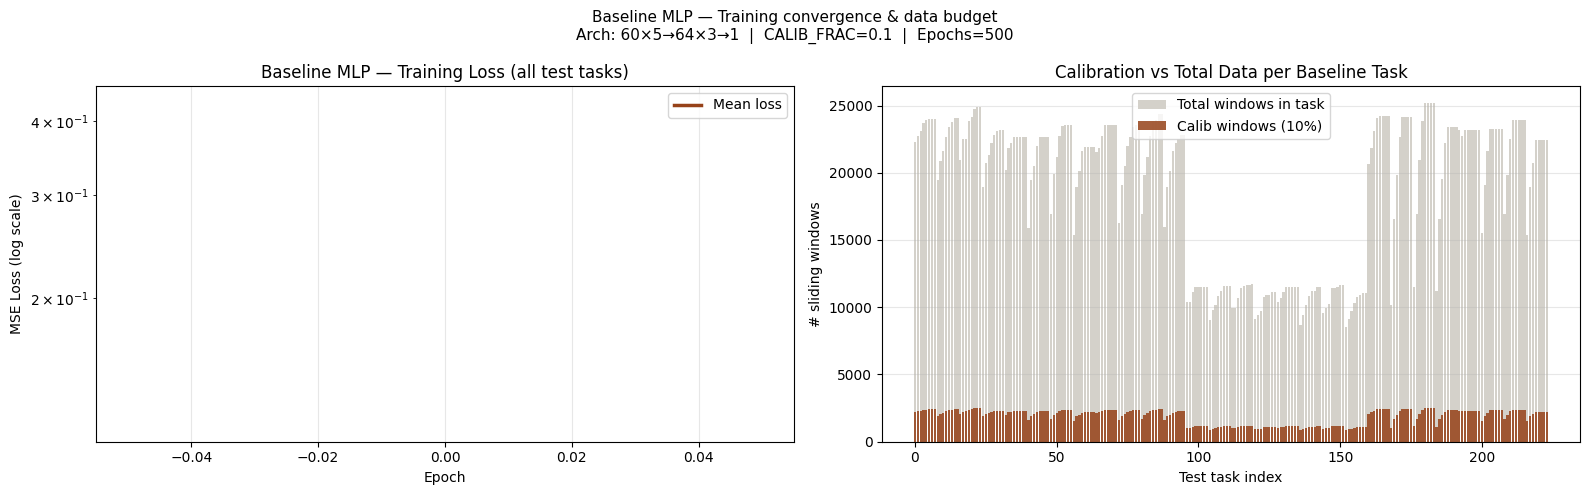

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: all individual curves (light) + mean (bold) ───────────────────────
ax = axes[0]
loss_matrix = np.array(all_baseline_losses)   # [n_tasks, epochs]
for curve in loss_matrix:
    ax.plot(curve, color="#964219", alpha=0.08, linewidth=0.8)
ax.plot(loss_matrix.mean(axis=0), color="#964219", linewidth=2.5, label="Mean loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss (log scale)")
ax.set_yscale("log"); ax.set_title("Baseline MLP — Training Loss (all test tasks)")
ax.legend(); ax.grid(alpha=0.3)

# ── Right: calibration data size per task ────────────────────────────────────
ax2 = axes[1]
n_totals = [r["ntotal"] for r in baseline_results]
n_calibs = [r["ncalib"] for r in baseline_results]
task_ids = range(len(baseline_results))
ax2.bar(task_ids, n_totals, color="#d4d1ca", label="Total windows in task")
ax2.bar(task_ids, n_calibs, color="#964219", alpha=0.85, label=f"Calib windows ({CALIB_FRAC*100:.0f}%)")
ax2.set_xlabel("Test task index"); ax2.set_ylabel("# sliding windows")
ax2.set_title("Calibration vs Total Data per Baseline Task")
ax2.legend(); ax2.grid(axis="y", alpha=0.3)

plt.suptitle(
    f"Baseline MLP — Training convergence & data budget\n"
    f"Arch: {WINDOW_SIZE}×{FEATURE_DIM}→{HIDDEN_DIM}×{NUM_LAYERS}→1  "
    f"|  CALIB_FRAC={CALIB_FRAC}  |  Epochs=500",
    fontsize=11
)
plt.tight_layout()
# plt.savefig(f"{PLOT_DIR}/baseline_loss_and_data.png", dpi=150)
plt.show()

## 19. Side-by-Side Comparison  -  6 Sample Test Tasks

In [ ]:
N_SHOW = min(6, len(test_prepared))
model_data = [
    ("Baseline MLP+KF\n(He et al. 2014)", baseline_results, "#964219"),
    ("CAMEL + KF",                          camel_results,    "#01696f"),
    ("CoDA + KF",                           coda_results,     "#006494"),
]

fig, axes = plt.subplots(N_SHOW, 3, figsize=(21, N_SHOW * 3.5))
if N_SHOW == 1: axes = axes[np.newaxis, :]

for row in range(N_SHOW):
    for col, (label, results, color) in enumerate(model_data):
        ax = axes[row, col]; res = results[row]
        ax.plot(res["time"], res["true"], "k-", lw=2.0, label="True SOC", zorder=3)
        ax.fill_between(res["time"],
                        res["pred_raw"] - res["pred_std"],
                        res["pred_raw"] + res["pred_std"],
                        color=color, alpha=0.15)
        ax.plot(res["time"], res["pred_raw"], "-",  color=color, alpha=0.40, lw=0.8,
                label=f"Raw NN (mean±σ, {N_TRAIN_SEEDS} train-seed-paired evals)")
        ax.plot(res["time"], res["pred_kf"],  "--", color=color, lw=2.0,
                label=f"KF  {res['rmse_kf']:.3f}±{res['rmse_kf_std']:.3f}", zorder=2)
        ax.set_title(f"{label}\n{res['battery']} | {res['run']}", fontsize=8.5)
        ax.set_xlabel("Time (s)", fontsize=8); ax.set_ylabel("SOC", fontsize=8)
        ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=7, loc="lower left"); ax.grid(alpha=0.3)

plt.suptitle(
    f"SOC Comparison — 6 test tasks | calib={CALIB_FRAC*100:.0f}%, {N_TRAIN_SEEDS} train-seed-paired evals\n"
    f"Baseline {bl_rmse:.4f}±{bl_rmse_std:.4f}   "
    f"CAMEL {camel_rmse:.4f}±{camel_rmse_std:.4f}   "
    f"CoDA {coda_rmse:.4f}±{coda_rmse_std:.4f}",
    fontsize=11, y=1.01
)
plt.tight_layout()
# plt.savefig(f"{PLOT_DIR}/comparison_6tasks.png", dpi=150, bbox_inches="tight"); plt.show()
print("Plot saved.")


## 20. RMSE Distribution  (Box Plot  -  All Test Tasks)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: task-level RMSE distribution (box plot) ───────────────────────────
ax = axes[0]
bp = ax.boxplot(
    [[r["rmse_kf"] for r in baseline_results],
     [r["rmse_kf"] for r in camel_results],
     [r["rmse_kf"] for r in coda_results]],
    patch_artist=True, notch=True,
    medianprops=dict(color="white", linewidth=2.5)
)
for patch, color in zip(bp["boxes"], ["#964219", "#01696f", "#006494"]):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_xticklabels(["Baseline\nMLP+KF", "CAMEL\n+KF", "CoDA\n+KF"], fontsize=11)
ax.set_ylabel("RMSE (KF-smoothed)", fontsize=11)
ax.set_title(f"Task-level RMSE Distribution  ({len(test_tasks)} test tasks)", fontsize=11)
ax.grid(axis="y", alpha=0.3)

# ── Right: seed-level variance — mean±std RMSE per model ─────────────────────
ax2 = axes[1]
model_names   = ["Baseline", "CAMEL", "CoDA"]
model_colors  = ["#964219", "#01696f", "#006494"]
model_means   = [bl_rmse,    camel_rmse,    coda_rmse]
model_stds    = [bl_rmse_std, camel_rmse_std, coda_rmse_std]
x = np.arange(len(model_names))
bars = ax2.bar(x, model_means, yerr=model_stds, capsize=8, width=0.5,
               color=model_colors, alpha=0.75,
               error_kw=dict(elinewidth=2, ecolor="black"))
ax2.set_xticks(x); ax2.set_xticklabels(model_names, fontsize=11)
ax2.set_ylabel("Mean RMSE ± std (across calib seeds)", fontsize=11)
ax2.set_title(f"Train-Seed-Paired Variance  ({N_TRAIN_SEEDS} seeds × {len(test_tasks)} tasks)", fontsize=11)
# annotate bars
for xi, (m, s) in enumerate(zip(model_means, model_stds)):
    ax2.text(xi, m + s + 0.001, f"{m:.4f}\n±{s:.4f}", ha="center", va="bottom",
             fontsize=9)
ax2.grid(axis="y", alpha=0.3)

plt.suptitle("RMSE Distribution — Task Variability (left) & Calib-Seed Variance (right)",
             fontsize=12)
plt.tight_layout()
plt.show()


## 20C. Train CoDA-Efficient (LoRA-style lift, `emb_size=10`) — 25% data

CAMEL, CoDA-full, MAML, and Baseline all use 100% of the training data — no capping. `CoDA-Efficient` alone trains on a **25%** subsample, the fraction selected via the standalone validation-based analysis (`coda_efficient_frac_analysis.ipynb`) — the LoRA-style low-rank lift benefits from fewer parameters relative to a smaller training set, and 25% scored best on `val_prepared` among `{10%, 25%, 50%, 75%, 100%}`.

In [ ]:
def subsample_task_windows(tasks_prepared, frac, seed=0):
    """
    Return a new list of task dicts where each task's X/Y/time arrays are
    replaced by a FIXED random `frac` subset of its windows -- the same
    subset every epoch (a one-time cap on the training pool, not a
    per-step resample).
    """
    out = []
    g = np.random.default_rng(seed)
    for t in tasks_prepared:
        n      = len(t["X"])
        n_keep = max(1, int(frac * n))
        idx    = g.choice(n, size=n_keep, replace=False)
        idx.sort()
        t_new         = dict(t)
        t_new["X"]    = t["X"][idx]
        t_new["Y"]    = t["Y"][idx]
        t_new["time"] = t["time"][idx]
        out.append(t_new)
    return out


CODA_EFFICIENT_TRAIN_FRAC = 0.25   # selected via coda_efficient_frac_analysis.ipynb

train_prepared_coda_eff = subsample_task_windows(train_prepared, CODA_EFFICIENT_TRAIN_FRAC, seed=0)
n_full_w = sum(len(t["X"]) for t in train_prepared)
n_eff_w  = sum(len(t["X"]) for t in train_prepared_coda_eff)
print(f"CoDA-Efficient training pool: {n_eff_w:,} windows "
      f"({n_eff_w/n_full_w*100:.1f}% of {n_full_w:,} full)")

train_loader_coda_eff = build_task_homogeneous_loader(train_prepared_coda_eff)

for train_seed in range(N_TRAIN_SEEDS):
    set_seed(train_seed)

    coda_model_efficient = CoDaModelEfficient(n_tasks=len(train_tasks), r=R_DIM,
                                              emb_size=R_DIM).to(device)   # emb_size UNCHANGED

    _t0 = time.perf_counter()
    coda_eff_train_loss, coda_eff_val_loss, coda_eff_best_state = training_loop(
        coda_model_efficient, train_loader_coda_eff, val_prepared, epochs=35,
        desc=f"CoDA-Efficient ({CODA_EFFICIENT_TRAIN_FRAC*100:.0f}%)"
    )
    coda_eff_train_time_s = time.perf_counter() - _t0

    coda_model_efficient.load_state_dict(coda_eff_best_state)

    seed_dir = get_seed_dir(train_seed)
    torch.save({"state_dict": coda_eff_best_state,
                "train_loss": coda_eff_train_loss,
                "val_loss":   coda_eff_val_loss},
        os.path.join(seed_dir, "coda_efficient_best.pt")
    )

print(f"Seed {train_seed}: CoDA-Efficient ({CODA_EFFICIENT_TRAIN_FRAC*100:.0f}%) "
      f"checkpoint saved. Training time: {coda_eff_train_time_s:.1f} s")


## 21. Data Efficiency Curve — Comprehensive Sweep (all variants, train-seed-paired)

Shows every relevant variant on one plot: CAMEL and CoDA-full trained on 100% vs 10% of the data, CoDA-Efficient (LoRA-style lift, 100% data), Baseline, and MAML. Every curve uses the same train-seed-paired methodology (train_seed=k paired with calib_seed=k, averaged over N_TRAIN_SEEDS) — no N_CALIB_SEEDS anywhere.

In [1]:
# ── Comprehensive Data-Efficiency Sweep: 5 variants, train-seed-paired ──────
calib_fracs = [0.001, 0.005, 0.01, 0.05, 0.10]

def _align(*arrays):
    n = min(len(a) for a in arrays)
    return tuple(a[:n] for a in arrays)


def _sweep_eval_camel(model, frac, task_list, seed=0):
    model.eval(); rmses = []
    for t in task_list:
        X     = torch.from_numpy(t["X"]).float().to(device)
        Y     = torch.from_numpy(t["Y"]).float().to(device)
        Ytrue = Y.cpu().numpy().flatten()
        N = len(X); Nc = max(R_DIM + 3, int(frac * N))
        idx   = get_calib_idx(N, Nc, seed=seed)
        omega = model.adapt(X[idx], Y[idx])
        Yraw  = run_inference(X, lambda x: model.predict_with_omega(x, omega))
        c_nom = compute_c_nom(t["df"], idx)
        I_arr  = t["df"]["i"].values[WINDOW_SIZE:].astype(np.float64)
        dt_arr = np.diff(t["time"].astype(np.float64), prepend=t["time"][0])
        Yraw, I_arr, dt_arr = _align(Yraw, I_arr, dt_arr)
        Ytrue_t = Ytrue[:len(Yraw)]
        Ykf = kalman_filter_coulomb(Yraw, I_arr, dt_arr, c_nom=c_nom)
        rmses.append(float(np.sqrt(mean_squared_error(Ytrue_t, Ykf))))
    return float(np.mean(rmses)), float(np.std(rmses))


def _sweep_eval_coda(model, frac, task_list, seed=0):
    model.eval(); rmses = []
    for t in task_list:
        X     = torch.from_numpy(t["X"]).float().to(device)
        Y     = torch.from_numpy(t["Y"]).float().to(device)
        Ytrue = Y.cpu().numpy().flatten()
        N = len(X); Nc = max(16, int(frac * N))
        idx  = get_calib_idx(N, Nc, seed=seed)
        e, _ = model.adapt(X[idx], Y[idx], n_steps=adaptation_step_coda, lr=5e-3)
        Yraw  = run_inference(X, lambda x: model.predict_with_emb(x, e))
        c_nom = compute_c_nom(t["df"], idx)
        I_arr  = t["df"]["i"].values[WINDOW_SIZE:].astype(np.float64)
        dt_arr = np.diff(t["time"].astype(np.float64), prepend=t["time"][0])
        Yraw, I_arr, dt_arr = _align(Yraw, I_arr, dt_arr)
        Ytrue_t = Ytrue[:len(Yraw)]
        Ykf = kalman_filter_coulomb(Yraw, I_arr, dt_arr, c_nom=c_nom)
        rmses.append(float(np.sqrt(mean_squared_error(Ytrue_t, Ykf))))
    return float(np.mean(rmses)), float(np.std(rmses))


def _sweep_eval_baseline(frac, task_list, seed=0):
    rmses = []
    for t in task_list:
        X     = torch.from_numpy(t["X"]).float().to(device)
        Y     = torch.from_numpy(t["Y"]).float().to(device)
        Ytrue = Y.cpu().numpy().flatten()
        N = len(X); Nc = max(10, int(frac * N))
        idx = get_calib_idx(N, Nc, seed=seed)
        bl, _ = train_baseline(X[idx], Y[idx], epochs=1000)
        bl.eval()
        Yraw  = run_inference(X, lambda x: bl(x).clamp(0, 1))
        c_nom = compute_c_nom(t["df"], idx)
        I_arr  = t["df"]["i"].values[WINDOW_SIZE:].astype(np.float64)
        dt_arr = np.diff(t["time"].astype(np.float64), prepend=t["time"][0])
        Yraw, I_arr, dt_arr = _align(Yraw, I_arr, dt_arr)
        Ytrue_t = Ytrue[:len(Yraw)]
        Ykf = kalman_filter_coulomb(Yraw, I_arr, dt_arr, c_nom=c_nom)
        rmses.append(float(np.sqrt(mean_squared_error(Ytrue_t, Ykf))))
    return float(np.mean(rmses)), float(np.std(rmses))


def _sweep_eval_maml(model, best_state, frac, task_list, seed=0,
                      n_inner_steps=MAML_N_INNER, inner_lr=MAML_LR_INNER):
    rmses = []
    for t in task_list:
        X = torch.from_numpy(t["X"]).float().to(device)
        Y = torch.from_numpy(t["Y"]).float().to(device)
        Ytrue = Y.cpu().numpy().flatten()
        N = len(X); Nc = max(10, int(frac * N))
        idx = get_calib_idx(N, Nc, seed=seed)
        x_cal, y_cal = X[idx], Y[idx]

        fast_weights = {n: p.clone().requires_grad_(True) for n, p in best_state.items()}
        for _ in range(n_inner_steps):
            pred = functional_forward(model, x_cal, fast_weights)
            loss = F.mse_loss(pred, y_cal)
            grads = torch.autograd.grad(loss, fast_weights.values(), allow_unused=True)
            fast_weights = {
                n: (w - inner_lr * g).detach().requires_grad_(True)
                for n, w, g in zip(fast_weights.keys(), fast_weights.values(), grads)
            }

        with torch.no_grad():
            Yraw = run_inference(X, lambda x: functional_forward(model, x, fast_weights).clamp(0, 1))
        c_nom = compute_c_nom(t["df"], idx)
        I_arr  = t["df"]["i"].values[WINDOW_SIZE:].astype(np.float64)
        dt_arr = np.diff(t["time"].astype(np.float64), prepend=t["time"][0])
        Yraw, I_arr, dt_arr = _align(Yraw, I_arr, dt_arr)
        Ytrue_t = Ytrue[:len(Yraw)]
        Ykf = kalman_filter_coulomb(Yraw, I_arr, dt_arr, c_nom=c_nom)
        rmses.append(float(np.sqrt(mean_squared_error(Ytrue_t, Ykf))))

    return float(np.mean(rmses)), float(np.std(rmses))



NameError: name 'MAML_N_INNER' is not defined

In [ ]:

# ── Sweep: 5 variants, all train-seed-paired ─────────────────────────────────
# CAMEL, CoDA-full, Baseline, MAML: 100% of training data (no capping).
# CoDA-Efficient: 25% (selected via the standalone validation-based analysis).
variant_names = ["CAMEL", "CoDA", "CoDA-Efficient (25%)", "Baseline", "MAML"]
sweep_mean = {v: [] for v in variant_names}
sweep_std  = {v: [] for v in variant_names}

print(f"Comprehensive sweep: {len(calib_fracs)} fracs x {N_TRAIN_SEEDS} "
      f"train-seed-paired evaluations x {len(test_prepared)} test tasks "
      f"x {len(variant_names)} variants ...")

for f in calib_fracs:
    vals = {v: [] for v in variant_names}

    for ts in range(1):
        seed_dir = get_seed_dir(ts)

        ck = torch.load(os.path.join(seed_dir, "camel_best.pt"), map_location=device)
        m = CAMEL(n_tasks=len(train_tasks), r=R_DIM).to(device)
        m.load_state_dict(ck["state_dict"])
        r, _ = _sweep_eval_camel(m, f, test_prepared, seed=ts)
        vals["CAMEL"].append(r)

        ck = torch.load(os.path.join(seed_dir, "coda_best.pt"), map_location=device)
        m = CoDaModel(n_tasks=len(train_tasks), r=R_DIM, emb_size=R_DIM).to(device)
        m.load_state_dict(ck["state_dict"])
        r, _ = _sweep_eval_coda(m, f, test_prepared, seed=ts)
        vals["CoDA"].append(r)

        ck = torch.load(os.path.join(seed_dir, "coda_efficient_best.pt"), map_location=device)
        m = CoDaModelEfficient(n_tasks=len(train_tasks), r=R_DIM, emb_size=R_DIM).to(device)
        m.load_state_dict(ck["state_dict"])
        r, _ = _sweep_eval_coda(m, f, test_prepared, seed=ts)
        vals["CoDA-Efficient (25%)"].append(r)

        r, _ = _sweep_eval_baseline(f, test_prepared, seed=ts)
        vals["Baseline"].append(r)

        maml_state = torch.load(os.path.join(seed_dir, "maml_windowed_best.pt"), map_location=device)
        m = MAMLWindowedMLP().to(device)
        r, _ = _sweep_eval_maml(m, maml_state, f, test_prepared, seed=ts)
        vals["MAML"].append(r)

    for v in variant_names:
        sweep_mean[v].append(float(np.mean(vals[v])))
        sweep_std[v].append(float(np.std(vals[v])))

    print(f"  frac={f*100:5.2f}%  " + "  ".join(
        f"{v}={sweep_mean[v][-1]:.4f}+/-{sweep_std[v][-1]:.4f}" for v in variant_names))

for v in variant_names:
    sweep_mean[v] = np.array(sweep_mean[v])
    sweep_std[v]  = np.array(sweep_std[v])

# ── Table ─────────────────────────────────────────────────────────────────────
header = " {:>5} ".format("Frac") + "".join(f"{v:>22}" for v in variant_names)
print("\n" + header)
for i, f in enumerate(calib_fracs):
    row = f" {f*100:4.0f}% "
    for v in variant_names:
        row += f"{sweep_mean[v][i]:8.4f}+/-{sweep_std[v][i]:.3f} "[:22].rjust(22)
    print(row)

# ── Plot: mean comparison (top) + grouped bar chart of std (bottom) ─────────
pct = np.array([f * 100 for f in calib_fracs])

style = {
    "CAMEL":                dict(color="#01696f", marker="o", ls="-", alpha=1.0),
    "CoDA":                 dict(color="#006494", marker="s", ls="-", alpha=1.0),
    "CoDA-Efficient (25%)": dict(color="#8e44ad", marker="*", ls="-", alpha=1.0),
    "Baseline":             dict(color="#964219", marker="^", ls="-", alpha=1.0),
    "MAML":                 dict(color="#d62728", marker="D", ls="-", alpha=1.0),
}

fig = plt.figure(figsize=(14, 10))
gs  = fig.add_gridspec(2, 1, height_ratios=[1.2, 1], hspace=0.4)

ax_top = fig.add_subplot(gs[0])
for v in variant_names:
    st = style[v]
    ax_top.plot(pct, sweep_mean[v], marker=st["marker"], ls=st["ls"],
                color=st["color"], lw=2.2, ms=7, alpha=st["alpha"], label=v)
ax_top.axvline(x=CALIB_FRAC * 100, color="gray", lw=1, ls=":", alpha=0.6,
               label=f"Main eval point ({CALIB_FRAC*100:.0f}%)")
ax_top.set_xscale("log")
ax_top.set_xlabel("Calibration data used at test time (% of test run, log scale)", fontsize=10)
ax_top.set_ylabel("Mean RMSE across tasks", fontsize=10)
ax_top.set_title(f"Data Efficiency — CAMEL/CoDA/Baseline/MAML (100% train data) vs "
                  f"CoDA-Efficient (25% train data)\n"
                  f"({N_TRAIN_SEEDS} train-seed-paired evaluations)", fontsize=12)
ax_top.legend(fontsize=9, ncol=3, loc="upper right")
ax_top.grid(alpha=0.3, which="both")

ax_bot   = fig.add_subplot(gs[1])
n_models = len(variant_names)
x_pos    = np.arange(len(calib_fracs))
bar_w    = 0.85 / n_models

for i, v in enumerate(variant_names):
    st = style[v]
    offset = (i - (n_models - 1) / 2) * bar_w
    ax_bot.bar(x_pos + offset, sweep_std[v], width=bar_w, color=st["color"],
               alpha=st["alpha"], label=v, edgecolor="white", linewidth=0.4)

if CALIB_FRAC in calib_fracs:
    eval_idx = calib_fracs.index(CALIB_FRAC)
    ax_bot.axvspan(eval_idx - 0.5, eval_idx + 0.5, color="gray", alpha=0.08, zorder=0)

ax_bot.set_xticks(x_pos)
ax_bot.set_xticklabels([f"{f*100:g}%" for f in calib_fracs], fontsize=9)
ax_bot.set_xlabel("Calibration fraction used at test time", fontsize=10)
ax_bot.set_ylabel("RMSE std (train-seed + calib-seed, paired)", fontsize=10)
ax_bot.set_title("Combined Std — grouped by calibration fraction", fontsize=12)
ax_bot.legend(fontsize=9, ncol=3, loc="upper right")
ax_bot.grid(axis="y", alpha=0.3)

# plt.savefig(f"{PLOT_DIR}/data_efficiency_final.png", dpi=150, bbox_inches="tight")
plt.show()
# print("Saved data_efficiency_final.png")

# Keep original variable names alive for any downstream cell (Section 26,
# sim-to-real gap plot) that still references them
camel_sweep_mean, camel_sweep_std = sweep_mean["CAMEL"], sweep_std["CAMEL"]
coda_sweep_mean,  coda_sweep_std  = sweep_mean["CoDA"],  sweep_std["CoDA"]
bl_sweep_mean,    bl_sweep_std    = sweep_mean["Baseline"], sweep_std["Baseline"]
maml_sweep_mean,  maml_sweep_std  = sweep_mean["MAML"], sweep_std["MAML"]
coda_efficient_sweep_mean, coda_efficient_sweep_std = (
    sweep_mean["CoDA-Efficient (25%)"], sweep_std["CoDA-Efficient (25%)"])


## 21B. Performance Summary Table

In [ ]:
import pandas as pd
import numpy as np

def _fmt(val, fmt=".4f"):
    try: return format(float(val), fmt)
    except Exception: return "n/a"

def _fmt_pm(mean, std, fmt=".4f"):
    try: return f"{float(mean):{fmt}} ± {float(std):{fmt}}"
    except Exception: return "n/a"

def _ms(sec):
    try: return f"{float(sec)*1e3:.1f}"
    except Exception: return "n/a"

def _s(sec):
    try: return f"{float(sec):.1f}"
    except Exception: return "n/a"

def _to_min(sec_str):
    try: return f"{float(sec_str)/60:.1f}"
    except Exception: return "n/a"

def _speedup(adapt_ms, baseline_ms):
    try: return f"{float(baseline_ms)/float(adapt_ms):.1f}×"
    except Exception: return "n/a"

# ── Ad-hoc-KF table ───────────────────────────────────────────────────────────
# Compute adhoc stds directly from results lists (no new variables needed upstream)

def _adhoc_stats(results, key):
    vals = np.array([r[key] for r in results], dtype=float)
    return vals.mean(), vals.std()

bl_rmse_adhoc_mean,    bl_rmse_adhoc_std    = _adhoc_stats(baseline_results, "rmse_kf_adhoc")
bl_mae_adhoc_mean,     bl_mae_adhoc_std     = _adhoc_stats(baseline_results, "mae_kf_adhoc")
camel_rmse_adhoc_mean, camel_rmse_adhoc_std = _adhoc_stats(camel_results,    "rmse_kf_adhoc")
camel_mae_adhoc_mean,  camel_mae_adhoc_std  = _adhoc_stats(camel_results,    "mae_kf_adhoc")
coda_rmse_adhoc_mean,  coda_rmse_adhoc_std  = _adhoc_stats(coda_results,     "rmse_kf_adhoc")
coda_mae_adhoc_mean,   coda_mae_adhoc_std   = _adhoc_stats(coda_results,     "mae_kf_adhoc")

rows_adhoc = [
    ("Baseline MLP+KF (He et al.)",
     _fmt_pm(bl_rmse_adhoc_mean,    bl_rmse_adhoc_std),
     _fmt_pm(bl_mae_adhoc_mean,     bl_mae_adhoc_std),
     str(KF_Q_BL),    str(KF_R_BL)),
    ("CAMEL+KF",
     _fmt_pm(camel_rmse_adhoc_mean, camel_rmse_adhoc_std),
     _fmt_pm(camel_mae_adhoc_mean,  camel_mae_adhoc_std),
     str(KF_Q_CAMEL), str(KF_R_CAMEL)),
    ("CoDA+KF",
     _fmt_pm(coda_rmse_adhoc_mean,  coda_rmse_adhoc_std),
     _fmt_pm(coda_mae_adhoc_mean,   coda_mae_adhoc_std),
     str(KF_Q_CODA),  str(KF_R_CODA)),
]
_maml_rows_adhoc = []
try:
    maml_s_rmse_adhoc_mean, maml_s_rmse_adhoc_std = _adhoc_stats(maml_static_results,  "rmse_kf_adhoc")
    maml_w_rmse_adhoc_mean, maml_w_rmse_adhoc_std = _adhoc_stats(maml_win_results,     "rmse_kf_adhoc")
    _maml_rows_adhoc = [
        ("MAML-Static+KF",
         _fmt_pm(maml_s_rmse_adhoc_mean, maml_s_rmse_adhoc_std), "n/a",
         str(KF_Q_BL), str(KF_R_BL)),
        ("MAML-Windowed+KF",
         _fmt_pm(maml_w_rmse_adhoc_mean, maml_w_rmse_adhoc_std), "n/a",
         str(KF_Q_BL), str(KF_R_BL)),
    ]
except NameError:
    pass

cols_adhoc = ["Model",
              f"RMSE mean±std ({len(baseline_results)} test tasks)",
              f"MAE  mean±std ({len(baseline_results)} test tasks)",
              "KF Q", "KF R"]
summary_adhoc = pd.DataFrame(rows_adhoc + _maml_rows_adhoc, columns=cols_adhoc)
print("\n── Ad-hoc KF (per-model tuned Q/R) ─────────────────────────────────────")
print(summary_adhoc.to_string(index=False))
# ── Shared-KF table ───────────────────────────────────────────────────────────
rows_shared = [
    ("Baseline MLP+KF (He et al.)",
     f"window×{WINDOW_SIZE}",
     _fmt_pm(bl_rmse,    bl_rmse_std),
     _fmt_pm(bl_mae,     bl_mae_std),
     "—", _ms(baseline_train_time_s),
     "500 epochs (scratch)", "No"),
    ("CAMEL+KF",
     f"window×{WINDOW_SIZE}",
     _fmt_pm(camel_rmse, camel_rmse_std),
     _fmt_pm(camel_mae,  camel_mae_std),
     _s(camel_train_time_s), f"{camel_adapt_time_ms:.1f}",
     "analytical (ridge)", "Yes — CAMEL"),
    ("CoDA+KF",
     f"window×{WINDOW_SIZE}",
     _fmt_pm(coda_rmse,  coda_rmse_std),
     _fmt_pm(coda_mae,   coda_mae_std),
     _s(coda_train_time_s), f"{coda_adapt_time_ms:.1f}",
     f"{adaptation_step_coda} Adam steps", "Yes — CoDA"),
]
_maml_rows = []
try:
    _ms_kf_mean, _ms_kf_std = _adhoc_stats(maml_static_results, "rmse_kf")
    _ms_mae_mean, _ms_mae_std = _adhoc_stats(maml_static_results, "mae_kf")
    _mw_kf_mean,  _mw_kf_std  = _adhoc_stats(maml_win_results,    "rmse_kf")
    _mw_mae_mean, _mw_mae_std = _adhoc_stats(maml_win_results,    "mae_kf")

    _maml_rows = [
        ("MAML-Static+KF (Jeong & Bae 2022)",
         "single-step (V,I,T)",
         _fmt_pm(_ms_kf_mean,  _ms_kf_std),
         _fmt_pm(_ms_mae_mean, _ms_mae_std),
         _s(maml_static_train_time_s), f"{maml_static_adapt_time_ms:.1f}",
         f"{MAML_N_INNER} SGD steps", "Yes — MAML (2nd-order)"),
        ("MAML-Windowed+KF",
         f"window×{WINDOW_SIZE}",
         _fmt_pm(_mw_kf_mean,  _mw_kf_std),
         _fmt_pm(_mw_mae_mean, _mw_mae_std),
         _s(maml_win_train_time_s), f"{maml_win_adapt_time_ms:.1f}",
         f"{MAML_N_INNER} SGD steps", "Yes — MAML (2nd-order)"),
    ]
except NameError:
    print("(MAML results not yet available — run MAML cell first)")
cols = ["Model", "Input",
        f"RMSE mean±std ({N_TRAIN_SEEDS} train-seed-paired evals)",
        f"MAE  mean±std ({N_TRAIN_SEEDS} train-seed-paired evals)",
        "Meta-train (s)", "Adapt/task (ms)", "Adapt steps", "Meta-prior"]
summary_shared = pd.DataFrame(rows_shared + _maml_rows, columns=cols)
print(f"── Shared KF — Primary comparison  "
      f"(calib={CALIB_FRAC*100:.0f}%, {N_TRAIN_SEEDS} train-seed-paired evals) ────────────────")
print(summary_shared.to_string(index=False))


# ── Ad-hoc-KF table ───────────────────────────────────────────────────────────
# std over seeds, same as shared-KF table but with per-model Q/R
rows_adhoc = [
    ("Baseline MLP+KF (He et al.)",
     _fmt_pm(bl_rmse_adhoc,    bl_rmse_adhoc_std),
     _fmt_pm(bl_mae_adhoc,     bl_mae_adhoc_std),
     str(KF_Q_BL),    str(KF_R_BL)),
    ("CAMEL+KF",
     _fmt_pm(camel_rmse_adhoc, camel_rmse_adhoc_std),
     _fmt_pm(camel_mae_adhoc,  camel_mae_adhoc_std),
     str(KF_Q_CAMEL), str(KF_R_CAMEL)),
    ("CoDA+KF",
     _fmt_pm(coda_rmse_adhoc,  coda_rmse_adhoc_std),
     _fmt_pm(coda_mae_adhoc,   coda_mae_adhoc_std),
     str(KF_Q_CODA),  str(KF_R_CODA)),
]
_maml_rows_adhoc = []
try:
    _ms_adhoc_mean, _ms_adhoc_std = _adhoc_stats(maml_static_results, "rmse_kf_adhoc")
    _mw_adhoc_mean, _mw_adhoc_std = _adhoc_stats(maml_win_results,    "rmse_kf_adhoc")

    _maml_rows_adhoc = [
        ("MAML-Static+KF",
         _fmt_pm(_ms_adhoc_mean, _ms_adhoc_std), "n/a",
         str(KF_Q_BL), str(KF_R_BL)),
        ("MAML-Windowed+KF",
         _fmt_pm(_mw_adhoc_mean, _mw_adhoc_std), "n/a",
         str(KF_Q_BL), str(KF_R_BL)),
    ]
except NameError:
    pass

cols_adhoc = ["Model",
              f"RMSE mean±std ({N_TRAIN_SEEDS} train-seed-paired evals)",
              f"MAE  mean±std ({N_TRAIN_SEEDS} train-seed-paired evals)",
              "KF Q", "KF R"]
summary_adhoc = pd.DataFrame(rows_adhoc + _maml_rows_adhoc, columns=cols_adhoc)
print("\n── Ad-hoc KF (per-model tuned Q/R) ─────────────────────────────────────")
print(summary_adhoc.to_string(index=False))


# ── Raw NN (no KF) table ──────────────────────────────────────────────────────
# std over test tasks (no calib-seed averaging here — raw predictions are deterministic)
def _task_stats(results, key):
    vals = np.array([r[key] for r in results], dtype=float)
    return vals.mean(), vals.std()

bl_rmse_raw_mean,    bl_rmse_raw_std    = _task_stats(baseline_results, "rmse_raw")
camel_rmse_raw_mean, camel_rmse_raw_std = _task_stats(camel_results,    "rmse_raw")
coda_rmse_raw_mean,  coda_rmse_raw_std  = _task_stats(coda_results,     "rmse_raw")

rows_raw = [
    ("Baseline MLP (no KF)",
     _fmt_pm(bl_rmse_raw_mean,    bl_rmse_raw_std),    "n/a"),
    ("CAMEL (no KF)",
     _fmt_pm(camel_rmse_raw_mean, camel_rmse_raw_std), "n/a"),
    ("CoDA (no KF)",
     _fmt_pm(coda_rmse_raw_mean,  coda_rmse_raw_std),  "n/a"),
]
try:
    _ms_raw_mean, _ms_raw_std = _adhoc_stats(maml_static_results, "rmse_raw")
    _ms_maeraw_mean, _ms_maeraw_std = _adhoc_stats(maml_static_results, "mae_raw")
    _mw_raw_mean, _mw_raw_std = _adhoc_stats(maml_win_results,    "rmse_raw")
    _mw_maeraw_mean, _mw_maeraw_std = _adhoc_stats(maml_win_results,    "mae_raw")

    rows_raw += [
        ("MAML-Static (no KF; CALIB_FRAC budget, NOT paper-exact)",
         _fmt_pm(_ms_raw_mean,    _ms_raw_std),
         _fmt_pm(_ms_maeraw_mean, _ms_maeraw_std)),
        ("MAML-Windowed (no KF; CALIB_FRAC budget)",
         _fmt_pm(_mw_raw_mean,    _mw_raw_std),
         _fmt_pm(_mw_maeraw_mean, _mw_maeraw_std)),
    ]
except NameError:
    pass

# ── MAML-PaperExact: literal Nc=96/9-steps/ReLU/4-layer reproduction ────────
# This row — not the two above — is the one comparable to Jeong & Bae (2022)'s
# own reported protocol. See item #7 in the MAML cell's header comment.
try:
    _mp_raw_mean, _mp_raw_std       = _adhoc_stats(maml_paper_results, "rmse_raw")
    _mp_maeraw_mean, _mp_maeraw_std = _adhoc_stats(maml_paper_results, "mae_raw")
    rows_raw += [
        ("MAML-PaperExact (no KF; Nc=96, 9 steps — literal Jeong & Bae 2022)",
         _fmt_pm(_mp_raw_mean,    _mp_raw_std),
         _fmt_pm(_mp_maeraw_mean, _mp_maeraw_std)),
    ]
except NameError:
    pass

cols_raw = ["Model",
            f"RMSE mean±std ({len(baseline_results)} test tasks)",
            f"MAE  mean±std ({len(baseline_results)} test tasks)"]
summary_raw = pd.DataFrame(rows_raw, columns=cols_raw)
print("\n── Raw NN, no KF ──────────────────────────────────────────────────────")
print("Only the MAML-PaperExact row below uses the paper's own fine-tuning")
print("budget (Nc=96 fixed, 9 steps) — the others use CALIB_FRAC, chosen to")
print("be comparable to CAMEL/CoDA on THIS dataset, not to the paper's numbers.")
print(summary_raw.to_string(index=False))

# ── Direct unit-converted comparison against Table 3 (US06) ─────────────────
try:
    _paper_mse_pct = (_mp_raw_mean ** 2) * 100
    _paper_mae_pct = _mp_maeraw_mean * 100
    print("\n── vs. Jeong & Bae (2022) Table 3 (their units: MSE/MAE ×100 on a [0,1] SOC scale) ──")
    print(f"{'Source':40s} {'MSE(%)':>10s} {'MAE(%)':>10s}")
    print(f"{'Paper (Table 3, US06)':40s} {0.0176:10.4f} {1.0075:10.4f}")
    print(f"{'MAML-PaperExact (this notebook)':40s} {_paper_mse_pct:10.4f} {_paper_mae_pct:10.4f}")
except NameError:
    pass


# ── Timing table ──────────────────────────────────────────────────────────────
# adapt time std: std of per-task adapt times (wall-clock spread across test tasks)
# For Baseline, adapt = per-task from-scratch training time.
# For CAMEL/CoDA/MAML, adapt = per-task fine-tune / ridge solve time.
# These are already stored as scalars (mean over tasks); std requires per-task timing
# arrays. If not available, falls back to "n/a".

def _ms_pm(mean_s, std_s=None):
    try:
        m = float(mean_s) * 1e3
        if std_s is not None:
            s = float(std_s) * 1e3
            return f"{m:.1f} ± {s:.1f}"
        return f"{m:.1f}"
    except Exception:
        return "n/a"

_bl_adapt_ms = _ms(baseline_train_time_s)

rows_timing = [
    ("Baseline MLP",
     "—", "—",
     _ms_pm(baseline_train_time_s,
            getattr(__builtins__, '__dict__', {}).get('baseline_adapt_time_std_s', None)),
     "Train MLP from scratch on calib data", "500 epochs", "1.0× (reference)"),
    ("CAMEL",
     _s(camel_train_time_s), _to_min(_s(camel_train_time_s)),
     _ms_pm(camel_adapt_time_ms / 1e3,
            getattr(__builtins__, '__dict__', {}).get('camel_adapt_time_std_s', None)),
     "Closed-form ridge (analytical)", "0 (analytical)",
     _speedup(f"{camel_adapt_time_ms:.1f}", _bl_adapt_ms)),
    ("CoDA",
     _s(coda_train_time_s), _to_min(_s(coda_train_time_s)),
     _ms_pm(coda_adapt_time_ms / 1e3,
            getattr(__builtins__, '__dict__', {}).get('coda_adapt_time_std_s', None)),
     f"Gradient descent on embedding ({adaptation_step_coda} steps)",
     str(adaptation_step_coda),
     _speedup(f"{coda_adapt_time_ms:.1f}", _bl_adapt_ms)),
]
_maml_timing_rows = []
try:
    _maml_timing_rows = [
        ("MAML-Static",
         _s(maml_static_train_time_s), _to_min(_s(maml_static_train_time_s)),
         _ms_pm(maml_static_adapt_time_ms / 1e3,
                getattr(__builtins__, '__dict__', {}).get('maml_static_adapt_time_std_s', None)),
         f"SGD fine-tuning on calib ({MAML_N_INNER} steps)", str(MAML_N_INNER),
         _speedup(f"{maml_static_adapt_time_ms:.1f}", _bl_adapt_ms)),
        ("MAML-Windowed",
         _s(maml_win_train_time_s), _to_min(_s(maml_win_train_time_s)),
         _ms_pm(maml_win_adapt_time_ms / 1e3,
                getattr(__builtins__, '__dict__', {}).get('maml_win_adapt_time_std_s', None)),
         f"SGD fine-tuning on calib ({MAML_N_INNER} steps)", str(MAML_N_INNER),
         _speedup(f"{maml_win_adapt_time_ms:.1f}", _bl_adapt_ms)),
    ]
except NameError:
    pass

cols_timing = ["Model", "Meta-train (s)", "Meta-train (min)",
               "Adapt/task (ms, mean ± std)",
               "Adapt mechanism", "Adapt steps", "Speedup vs Baseline"]
summary_timing = pd.DataFrame(rows_timing + _maml_timing_rows, columns=cols_timing)
print("\n── Training & Adaptation Timing ─────────────────────────────────────────")
print(summary_timing.to_string(index=False))


# ── Save all four tables ──────────────────────────────────────────────────────
summary_shared.to_csv(f"{PLOT_DIR}/performance_summary_shared_kf.csv",  index=False)
summary_adhoc.to_csv( f"{PLOT_DIR}/performance_summary_adhoc_kf.csv",   index=False)
summary_raw.to_csv(   f"{PLOT_DIR}/performance_summary_raw_nn.csv",      index=False)
summary_timing.to_csv(f"{PLOT_DIR}/performance_summary_timing.csv",      index=False)
print("\nSaved: performance_summary_shared_kf.csv, _adhoc_kf.csv, _raw_nn.csv, _timing.csv")

## 22. (Optional) Load Saved Checkpoints

In [21]:
# ── Checkpoint loader ─────────────────────────────────────────────────────────
# Run this cell INSTEAD of cells 24, 28, and the MAML training block in cell 49
# to restore all models from disk without re-running training.
#
# Loads the LAST training seed (train_seed = N_TRAIN_SEEDS - 1) by default.
# Change `load_seed` to load a different seed.

load_seed = N_TRAIN_SEEDS - 1
seed_dir  = get_seed_dir(load_seed)
print(f"Loading checkpoints from: {seed_dir}")

# ── CAMEL ─────────────────────────────────────────────────────────────────────
camel_ckpt        = torch.load(os.path.join(seed_dir, "camel_best.pt"),
                               map_location=device)
camel_model       = CAMEL(n_tasks=len(train_tasks), r=R_DIM).to(device)
camel_model.load_state_dict(camel_ckpt["state_dict"])
camel_model.eval()
camel_train_loss  = camel_ckpt["train_loss"]
camel_val_loss    = camel_ckpt["val_loss"]
camel_best_state  = camel_ckpt["state_dict"]
camel_train_time_s = 0.0   # unknown after reload; set manually if needed
print("CAMEL loaded.")

# ── CoDA ──────────────────────────────────────────────────────────────────────
coda_ckpt         = torch.load(os.path.join(seed_dir, "coda_best.pt"),
                               map_location=device)
coda_model        = CoDaModel(n_tasks=len(train_tasks), r=R_DIM, emb_size=R_DIM).to(device)
coda_model.load_state_dict(coda_ckpt["state_dict"])
coda_model.eval()
coda_train_loss   = coda_ckpt["train_loss"]
coda_val_loss     = coda_ckpt["val_loss"]
coda_best_state   = coda_ckpt["state_dict"]
coda_train_time_s = 0.0
print("CoDA loaded.")

# ── MAML-Static ───────────────────────────────────────────────────────────────
maml_static_best  = torch.load(os.path.join(seed_dir, "maml_static_best.pt"),
                               map_location=device)
maml_static_model = MAMLStaticMLP().to(device)
maml_static_model.load_state_dict(maml_static_best)
maml_static_model.eval()
maml_static_train_time_s = 0.0
print("MAML-Static loaded.")

# ── MAML-Windowed ─────────────────────────────────────────────────────────────
maml_win_best     = torch.load(os.path.join(seed_dir, "maml_windowed_best.pt"),
                               map_location=device)
maml_windowed_model = MAMLWindowedMLP().to(device)
maml_windowed_model.load_state_dict(maml_win_best)
maml_windowed_model.eval()
maml_win_train_time_s = 0.0
print("MAML-Windowed loaded.")

print(f"\nAll models loaded from seed {load_seed}.")
print("You can now run the test eval cells (33, 36, 40, 49) and the sweep (50) directly.")


## 23. Sim-to-Real Data-Efficiency Sweep

Evaluates the same sweep procedure used on `test_prepared` (Section 21), but on the dedicated **sim-to-real holdout** (`sim2real_prepared`) — real experimental data from `A123 - simtoreal`, carved out before the train/val/test split so it was never seen by any model during training, validation, or the main test evaluation.

**Requires**: run Section 21 (Data-Efficiency Sweep) first, so the sweep functions `_sweep_eval_camel` / `_sweep_eval_coda` / `_sweep_eval_baseline` / `_sweep_eval_maml` and `calib_fracs` / `SWEEP_SEEDS` are defined. Also run the checkpoint loader (Section 22) if you did not just finish training in this session.

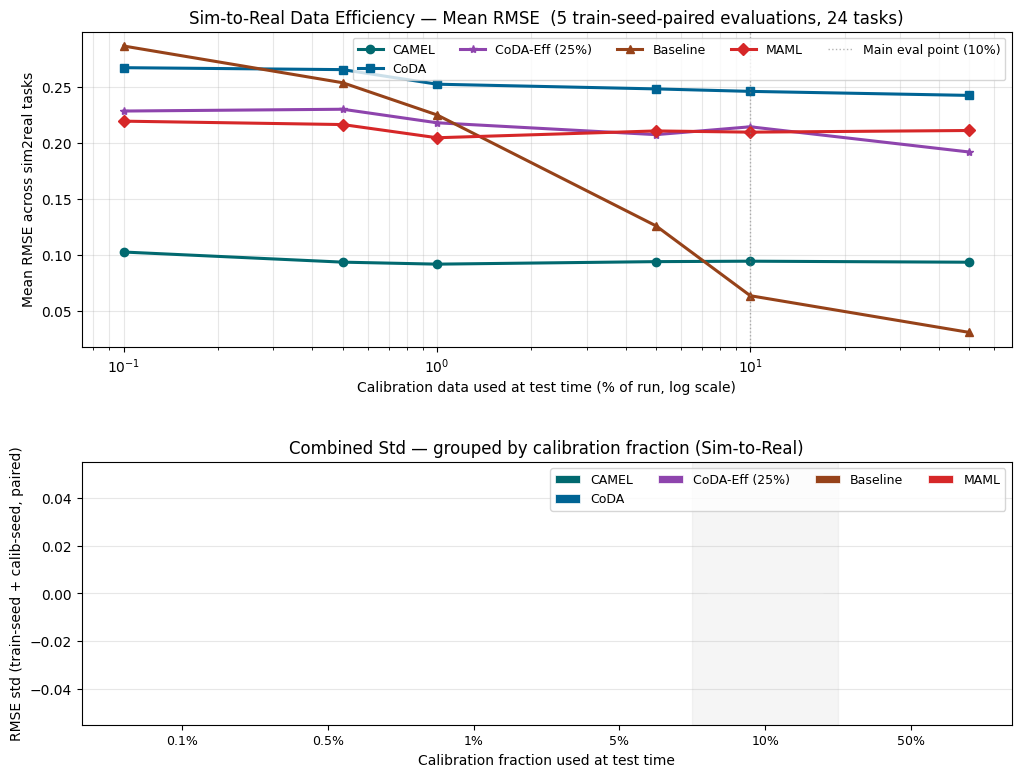

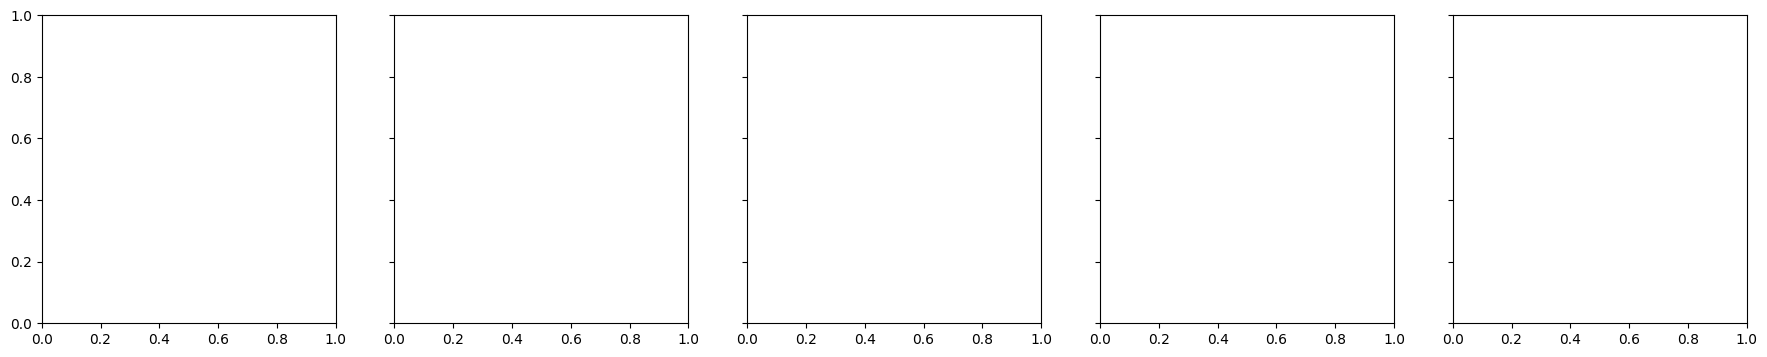

In [ ]:
# ── Sim-to-Real Data-Efficiency Sweep (train-seed-paired) ───────────────────
#
# Same train-seed-paired methodology as Section 21: for each calib_frac,
# loop over train_seed in range(N_TRAIN_SEEDS), load that seed's checkpoint,
# pair with calib_seed=train_seed. No N_CALIB_SEEDS/SWEEP_SEEDS anywhere.

import pandas as pd

assert len(sim2real_prepared) > 0, (
    "sim2real_prepared is empty — check SIM2REAL_BATTERY_NAMES matches a key "
    "in dataset_runs, and that the window-precomputation cell has been re-run "
    "since updating the split cell."
)

print(f"Sim-to-Real sweep: {len(calib_fracs)} fracs x {N_TRAIN_SEEDS} "
      f"train-seed-paired evaluations x {len(sim2real_prepared)} sim2real tasks ...")

camel_s2r_mean, camel_s2r_std = [], []
coda_s2r_mean,  coda_s2r_std  = [], []
coda_eff_s2r_mean, coda_eff_s2r_std = [], []
bl_s2r_mean,    bl_s2r_std    = [], []
maml_s2r_mean,  maml_s2r_std  = [], []

for f in calib_fracs:
    camel_vals, coda_vals, coda_eff_vals, bl_vals, maml_vals = [], [], [], [], []

    for ts in range(1):
        seed_dir = get_seed_dir(ts)

        maml_state = torch.load(os.path.join(seed_dir, "maml_windowed_best.pt"), map_location=device)
        m = MAMLWindowedMLP().to(device)
        mean_rmse, _ = _sweep_eval_maml(m, maml_state, f, sim2real_prepared, seed=ts)
        maml_vals.append(mean_rmse)
        

        ck = torch.load(os.path.join(seed_dir, "camel_best.pt"), map_location=device)
        m = CAMEL(n_tasks=len(train_tasks), r=R_DIM).to(device)
        m.load_state_dict(ck["state_dict"])
        mean_rmse, _ = _sweep_eval_camel(m, f, sim2real_prepared, seed=ts)
        camel_vals.append(mean_rmse)

        ck = torch.load(os.path.join(seed_dir, "coda_best.pt"), map_location=device)
        m = CoDaModel(n_tasks=len(train_tasks), r=R_DIM, emb_size=R_DIM).to(device)
        m.load_state_dict(ck["state_dict"])
        mean_rmse, _ = _sweep_eval_coda(m, f, sim2real_prepared, seed=ts)
        coda_vals.append(mean_rmse)

        ck = torch.load(os.path.join(seed_dir, "coda_efficient_best.pt"), map_location=device)
        m = CoDaModelEfficient(n_tasks=len(train_tasks), r=R_DIM, emb_size=R_DIM).to(device)
        m.load_state_dict(ck["state_dict"])
        mean_rmse, _ = _sweep_eval_coda(m, f, sim2real_prepared, seed=ts)
        coda_eff_vals.append(mean_rmse)


        mean_rmse, _ = _sweep_eval_baseline(f, sim2real_prepared, seed=ts)
        bl_vals.append(mean_rmse)


    camel_s2r_mean.append(np.mean(camel_vals)); camel_s2r_std.append(np.std(camel_vals))
    coda_s2r_mean.append(np.mean(coda_vals));   coda_s2r_std.append(np.std(coda_vals))
    coda_eff_s2r_mean.append(np.mean(coda_eff_vals)); coda_eff_s2r_std.append(np.std(coda_eff_vals))
    bl_s2r_mean.append(np.mean(bl_vals));       bl_s2r_std.append(np.std(bl_vals))
    maml_s2r_mean.append(np.mean(maml_vals));   maml_s2r_std.append(np.std(maml_vals))

camel_s2r_mean = np.array(camel_s2r_mean); camel_s2r_std = np.array(camel_s2r_std)
coda_s2r_mean  = np.array(coda_s2r_mean);  coda_s2r_std  = np.array(coda_s2r_std)
coda_eff_s2r_mean = np.array(coda_eff_s2r_mean); coda_eff_s2r_std = np.array(coda_eff_s2r_std)
bl_s2r_mean    = np.array(bl_s2r_mean);    bl_s2r_std    = np.array(bl_s2r_std)
maml_s2r_mean  = np.array(maml_s2r_mean);  maml_s2r_std  = np.array(maml_s2r_std)

# ── Table ─────────────────────────────────────────────────────────────────────
print(f"\n {'Frac':>5}  {'CAMEL':>10}  {'CoDA':>10}  {'CoDA-Eff(25%)':>14}  {'Baseline':>10}  {'MAML':>10}")
for i, f in enumerate(calib_fracs):
    print(f"  {f*100:4.0f}%  "
          f"{camel_s2r_mean[i]:.4f}+/-{camel_s2r_std[i]:.4f}  "
          f"{coda_s2r_mean[i]:.4f}+/-{coda_s2r_std[i]:.4f}  "
          f"{coda_eff_s2r_mean[i]:.4f}+/-{coda_eff_s2r_std[i]:.4f}  "
          f"{bl_s2r_mean[i]:.4f}+/-{bl_s2r_std[i]:.4f}  "
          f"{maml_s2r_mean[i]:.4f}+/-{maml_s2r_std[i]:.4f}")

# ── Plot 1: sim-to-real mean+std, same two-panel style as the test-data plot ─
pct = np.array([f * 100 for f in calib_fracs])
models_s2r = [
    ("CAMEL",            camel_s2r_mean,     camel_s2r_std,     "#01696f", "o"),
    ("CoDA",              coda_s2r_mean,      coda_s2r_std,      "#006494", "s"),
    ("CoDA-Eff (25%)",    coda_eff_s2r_mean,  coda_eff_s2r_std,  "#8e44ad", "*"),
    ("Baseline",          bl_s2r_mean,        bl_s2r_std,        "#964219", "^"),
    ("MAML",              maml_s2r_mean,      maml_s2r_std,      "#d62728", "D"),
]

fig = plt.figure(figsize=(12, 9))
gs  = fig.add_gridspec(2, 1, height_ratios=[1.2, 1], hspace=0.4)

ax_top = fig.add_subplot(gs[0])
for name, mean, std, color, marker in models_s2r:
    ax_top.plot(pct, mean, f"{marker}-", color=color, lw=2.2, ms=6, label=name)
ax_top.axvline(x=CALIB_FRAC * 100, color="gray", lw=1, ls=":", alpha=0.6,
               label=f"Main eval point ({CALIB_FRAC*100:.0f}%)")
ax_top.set_xscale("log")
ax_top.set_xlabel("Calibration data used at test time (% of run, log scale)", fontsize=10)
ax_top.set_ylabel("Mean RMSE across sim2real tasks", fontsize=10)
ax_top.set_title(f"Sim-to-Real Data Efficiency — Mean RMSE  "
                  f"({N_TRAIN_SEEDS} train-seed-paired evaluations, "
                  f"{len(sim2real_prepared)} tasks)",
                  fontsize=12)
ax_top.legend(fontsize=9, ncol=5, loc="upper right")
ax_top.grid(alpha=0.3, which="both")

ax_bot   = fig.add_subplot(gs[1])
n_models = len(models_s2r)
x_pos    = np.arange(len(calib_fracs))
bar_w    = 0.8 / n_models
for i, (name, mean, std, color, marker) in enumerate(models_s2r):
    offset = (i - (n_models - 1) / 2) * bar_w
    ax_bot.bar(x_pos + offset, std, width=bar_w, color=color, label=name,
               edgecolor="white", linewidth=0.5)
if CALIB_FRAC in calib_fracs:
    eval_idx = calib_fracs.index(CALIB_FRAC)
    ax_bot.axvspan(eval_idx - 0.5, eval_idx + 0.5, color="gray", alpha=0.08, zorder=0)
ax_bot.set_xticks(x_pos)
ax_bot.set_xticklabels([f"{f*100:g}%" for f in calib_fracs], fontsize=9)
ax_bot.set_xlabel("Calibration fraction used at test time", fontsize=10)
ax_bot.set_ylabel("RMSE std (train-seed + calib-seed, paired)", fontsize=10)
ax_bot.set_title("Combined Std — grouped by calibration fraction (Sim-to-Real)",
                  fontsize=12)
ax_bot.legend(fontsize=9, ncol=4, loc="upper right")
ax_bot.grid(axis="y", alpha=0.3)

# plt.savefig(f"{PLOT_DIR}/data_efficiency_sim2real.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sim-to-real data efficiency plot saved.")

# ── Plot 2: Simulated-test vs Sim-to-Real gap, per model ─────────────────────
try:
    fig2, axes2 = plt.subplots(1, 5, figsize=(22, 4), sharey=True)
    pairs = [
        ("CAMEL",         camel_sweep_mean,          camel_s2r_mean,     "#01696f"),
        ("CoDA",          coda_sweep_mean,            coda_s2r_mean,      "#006494"),
        ("CoDA-Eff (25%)",coda_efficient_sweep_mean,  coda_eff_s2r_mean,  "#8e44ad"),
        ("Baseline",      bl_sweep_mean,              bl_s2r_mean,        "#964219"),
        ("MAML",          maml_sweep_mean,            maml_s2r_mean,      "#d62728"),
    ]
    for ax, (name, test_mean, s2r_mean, color) in zip(axes2, pairs):
        ax.plot(pct, test_mean, "o-",  color=color, lw=2, label="Simulated (test)")
        ax.plot(pct, s2r_mean,  "s--", color=color, lw=2, alpha=0.6, label="Sim-to-Real")
        ax.set_xscale("log")
        ax.set_title(name, fontsize=11)
        ax.set_xlabel("Calib %", fontsize=9)
        ax.grid(alpha=0.3, which="both")
        ax.legend(fontsize=8)
    axes2[0].set_ylabel("Mean RMSE", fontsize=10)
    plt.suptitle("Simulated Test vs. Sim-to-Real Gap, per Model", fontsize=13, y=1.05)
    plt.tight_layout()
    # plt.savefig(f"{PLOT_DIR}/sim_vs_sim2real_gap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Sim vs sim-to-real gap plot saved.")
except NameError:
    print("(Simulated test sweep variables not found in this session — run "
          "Section 21 first to also get the sim-vs-real gap comparison plot.)")

# ── Save results to CSV ──────────────────────────────────────────────────────
summary_s2r = pd.DataFrame({
    "calib_frac":        calib_fracs,
    "CAMEL_mean":        camel_s2r_mean,     "CAMEL_std":        camel_s2r_std,
    "CoDA_mean":         coda_s2r_mean,      "CoDA_std":         coda_s2r_std,
    "CoDA_Eff25_mean":   coda_eff_s2r_mean,  "CoDA_Eff25_std":   coda_eff_s2r_std,
    "Baseline_mean":     bl_s2r_mean,        "Baseline_std":     bl_s2r_std,
    "MAML_mean":         maml_s2r_mean,      "MAML_std":         maml_s2r_std,
})
summary_s2r.to_csv(f"{PLOT_DIR}/sim2real_summary.csv", index=False)
print("Saved sim2real_summary.csv")


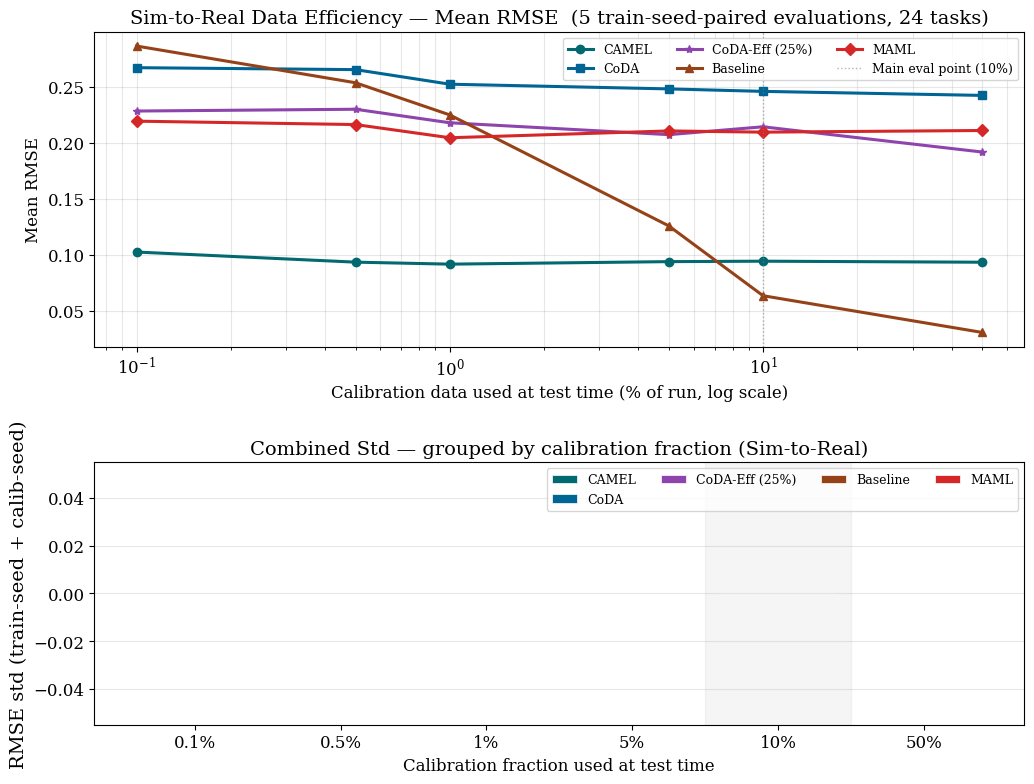

In [ ]:
tex_fonts = {
    # Use LaTeX to write all text
   "text.usetex": False,
   "font.family": "serif",
    # Use 10pt font in plots, to match 10pt font in document
   "axes.labelsize": 14,
   "font.size": 14,
   "legend.fontsize": 12,
   "xtick.labelsize": 12,
   "ytick.labelsize": 12
}
plt.rcParams.update(tex_fonts)
pct = np.array([f * 100 for f in calib_fracs])
models_s2r = [
    ("CAMEL",            camel_s2r_mean,     camel_s2r_std,     "#01696f", "o"),
    ("CoDA",              coda_s2r_mean,      coda_s2r_std,      "#006494", "s"),
    ("CoDA-Eff (25%)",    coda_eff_s2r_mean,  coda_eff_s2r_std,  "#8e44ad", "*"),
    ("Baseline",          bl_s2r_mean,        bl_s2r_std,        "#964219", "^"),
    ("MAML",              maml_s2r_mean,      maml_s2r_std,      "#d62728", "D"),
]

fig = plt.figure(figsize=(12, 9))
gs  = fig.add_gridspec(2, 1, height_ratios=[1.2, 1], hspace=0.4)

ax_top = fig.add_subplot(gs[0])
for name, mean, std, color, marker in models_s2r:
    ax_top.plot(pct, mean, f"{marker}-", color=color, lw=2.2, ms=6, label=name)
ax_top.axvline(x=CALIB_FRAC * 100, color="gray", lw=1, ls=":", alpha=0.6,
               label=f"Main eval point ({CALIB_FRAC*100:.0f}%)")
ax_top.set_xscale("log")
ax_top.set_xlabel("Calibration data used at test time (% of run, log scale)", fontsize=12)
ax_top.set_ylabel("Mean RMSE", fontsize=12)
ax_top.set_title(f"Sim-to-Real Data Efficiency — Mean RMSE  "
                  f"({N_TRAIN_SEEDS} train-seed-paired evaluations, "
                  f"{len(sim2real_prepared)} tasks)",
                  fontsize=14)
ax_top.legend(fontsize=9, ncol=3, loc="upper right")
ax_top.grid(alpha=0.3, which="both")

ax_bot   = fig.add_subplot(gs[1])
n_models = len(models_s2r)
x_pos    = np.arange(len(calib_fracs))
bar_w    = 0.8 / n_models
for i, (name, mean, std, color, marker) in enumerate(models_s2r):
    offset = (i - (n_models - 1) / 2) * bar_w
    ax_bot.bar(x_pos + offset, std, width=bar_w, color=color, label=name,
               edgecolor="white", linewidth=0.5)
if CALIB_FRAC in calib_fracs:
    eval_idx = calib_fracs.index(CALIB_FRAC)
    ax_bot.axvspan(eval_idx - 0.5, eval_idx + 0.5, color="gray", alpha=0.08, zorder=0)
ax_bot.set_xticks(x_pos)
ax_bot.set_xticklabels([f"{f*100:g}%" for f in calib_fracs], fontsize=12)
ax_bot.set_xlabel("Calibration fraction used at test time", fontsize=12)
ax_bot.set_ylabel("RMSE std (train-seed + calib-seed)", fontsize=14)
ax_bot.set_title("Combined Std — grouped by calibration fraction (Sim-to-Real)",
                  fontsize=14)
ax_bot.legend(fontsize=9, ncol=4, loc="upper right")
ax_bot.grid(axis="y", alpha=0.3)

# plt.savefig(f"{PLOT_DIR}/data_efficiency_sim2real.pdf", bbox_inches="tight")
plt.show()
print("Sim-to-real data efficiency plot saved.")


## 26. Combined Seed Robustness (paired training + calibration seeds)

Training seed `k` is paired with calibration seed `k` — each of the `N_TRAIN_SEEDS` evaluations reflects both a specific retrained model *and* a specific calibration draw simultaneously, giving one blended, robust mean±std per method that accounts for both sources of randomness together.

Requires `N_TRAIN_SEEDS > 1` (set to 3 in Section 1) and the CAMEL, CoDA-full, CoDA-Efficient, and MAML-Windowed training cells to have been run so checkpoints exist for all 3 seeds. **Baseline is excluded**: it retrains from scratch per test task per calibration seed already, so its variance already blends both sources by construction.

In [ ]:
# ── Explicit single-seed evaluation, PAIRED to the training seed ────────────
def _eval_fixed_seed_camel(model, frac, task_list, seed):
    model.eval(); rmses = []
    for t in task_list:
        X     = torch.from_numpy(t["X"]).float().to(device)
        Y     = torch.from_numpy(t["Y"]).float().to(device)
        Ytrue = Y.cpu().numpy().flatten()
        N = len(X); Nc = max(R_DIM + 3, int(frac * N))
        idx   = get_calib_idx(N, Nc, seed=seed)
        omega = model.adapt(X[idx], Y[idx])
        Yraw  = run_inference(X, lambda x: model.predict_with_omega(x, omega))
        c_nom = compute_c_nom(t["df"], idx)
        I_arr  = t["df"]["i"].values[WINDOW_SIZE:].astype(np.float64)
        dt_arr = np.diff(t["time"].astype(np.float64), prepend=t["time"][0])
        Yraw, I_arr, dt_arr = _align(Yraw, I_arr, dt_arr)
        Ytrue_t = Ytrue[:len(Yraw)]
        Ykf = kalman_filter_coulomb(Yraw, I_arr, dt_arr, c_nom=c_nom)
        rmses.append(float(np.sqrt(mean_squared_error(Ytrue_t, Ykf))))
    return float(np.mean(rmses)), float(np.std(rmses))


def _eval_fixed_seed_coda(model, frac, task_list, seed):
    model.eval(); rmses = []
    for t in task_list:
        X     = torch.from_numpy(t["X"]).float().to(device)
        Y     = torch.from_numpy(t["Y"]).float().to(device)
        Ytrue = Y.cpu().numpy().flatten()
        N = len(X); Nc = max(16, int(frac * N))
        idx  = get_calib_idx(N, Nc, seed=seed)
        e, _ = model.adapt(X[idx], Y[idx], n_steps=adaptation_step_coda)
        Yraw  = run_inference(X, lambda x: model.predict_with_emb(x, e))
        c_nom = compute_c_nom(t["df"], idx)
        I_arr  = t["df"]["i"].values[WINDOW_SIZE:].astype(np.float64)
        dt_arr = np.diff(t["time"].astype(np.float64), prepend=t["time"][0])
        Yraw, I_arr, dt_arr = _align(Yraw, I_arr, dt_arr)
        Ytrue_t = Ytrue[:len(Yraw)]
        Ykf = kalman_filter_coulomb(Yraw, I_arr, dt_arr, c_nom=c_nom)
        rmses.append(float(np.sqrt(mean_squared_error(Ytrue_t, Ykf))))
    return float(np.mean(rmses)), float(np.std(rmses))


def _eval_fixed_seed_maml(model, best_state, frac, task_list, seed,
                          n_inner_steps=MAML_N_INNER, inner_lr=MAML_LR_INNER):
    rmses = []
    for t in task_list:
        X = torch.from_numpy(t["X"]).float().to(device)
        Y = torch.from_numpy(t["Y"]).float().to(device)
        Ytrue = Y.cpu().numpy().flatten()
        N = len(X); Nc = max(10, int(frac * N))
        idx = get_calib_idx(N, Nc, seed=seed)
        x_cal, y_cal = X[idx], Y[idx]

        fast_weights = {n: p.clone().requires_grad_(True) for n, p in best_state.items()}
        for _ in range(n_inner_steps):
            pred = functional_forward(model, x_cal, fast_weights)
            loss = F.mse_loss(pred, y_cal)
            grads = torch.autograd.grad(loss, fast_weights.values(), allow_unused=True)
            fast_weights = {
                n: (w - inner_lr * g).detach().requires_grad_(True)
                for n, w, g in zip(fast_weights.keys(), fast_weights.values(), grads)
            }

        with torch.no_grad():
            Yraw = run_inference(X, lambda x: functional_forward(model, x, fast_weights).clamp(0, 1))
        c_nom = compute_c_nom(t["df"], idx)
        I_arr  = t["df"]["i"].values[WINDOW_SIZE:].astype(np.float64)
        dt_arr = np.diff(t["time"].astype(np.float64), prepend=t["time"][0])
        Yraw, I_arr, dt_arr = _align(Yraw, I_arr, dt_arr)
        Ytrue_t = Ytrue[:len(Yraw)]
        Ykf = kalman_filter_coulomb(Yraw, I_arr, dt_arr, c_nom=c_nom)
        rmses.append(float(np.sqrt(mean_squared_error(Ytrue_t, Ykf))))

    return float(np.mean(rmses)), float(np.std(rmses))

print(f"Explicit single-seed eval functions ready. train_seed=k paired with "
      f"calib_seed=k for each of the {N_TRAIN_SEEDS} evaluations below.")


# ── Paired evaluation: train_seed=k, calib_seed=k ────────────────────────────
methods_to_check = ["CAMEL", "CoDA-full", "CoDA-Efficient", "MAML-Windowed"]
per_seed_mean = {m: [] for m in methods_to_check}

for ts in range(N_TRAIN_SEEDS):
    seed_dir = get_seed_dir(ts)

    ck = torch.load(os.path.join(seed_dir, "camel_best.pt"), map_location=device)
    m = CAMEL(n_tasks=len(train_tasks), r=R_DIM).to(device)
    m.load_state_dict(ck["state_dict"]); m.eval()
    mean_rmse, _ = _eval_fixed_seed_camel(m, CALIB_FRAC, test_prepared, seed=ts)
    per_seed_mean["CAMEL"].append(mean_rmse)

    ck = torch.load(os.path.join(seed_dir, "coda_best.pt"), map_location=device)
    m = CoDaModel(n_tasks=len(train_tasks), r=R_DIM, emb_size=R_DIM).to(device)
    m.load_state_dict(ck["state_dict"]); m.eval()
    mean_rmse, _ = _eval_fixed_seed_coda(m, CALIB_FRAC, test_prepared, seed=ts)
    per_seed_mean["CoDA-full"].append(mean_rmse)

    ck = torch.load(os.path.join(seed_dir, "coda_efficient_best.pt"), map_location=device)
    m = CoDaModelEfficient(n_tasks=len(train_tasks), r=R_DIM, emb_size=R_DIM).to(device)
    m.load_state_dict(ck["state_dict"]); m.eval()
    mean_rmse, _ = _eval_fixed_seed_coda(m, CALIB_FRAC, test_prepared, seed=ts)
    per_seed_mean["CoDA-Efficient"].append(mean_rmse)

    maml_state = torch.load(os.path.join(seed_dir, "maml_windowed_best.pt"), map_location=device)
    m = MAMLWindowedMLP().to(device)
    mean_rmse, _ = _eval_fixed_seed_maml(m, maml_state, CALIB_FRAC, test_prepared, seed=ts)
    per_seed_mean["MAML-Windowed"].append(mean_rmse)

    print(f"Seed pair (train={ts}, calib={ts}): " +
          "  ".join(f"{name}={per_seed_mean[name][-1]:.4f}" for name in methods_to_check))

# ── Combined robustness estimate: mean +/- std over the N_TRAIN_SEEDS paired runs ─
print(f"\n{'Method':<15} {'Mean RMSE':>12} {'Combined std':>14}")
combined_mean = {}
combined_std  = {}
for name in methods_to_check:
    vals = np.array(per_seed_mean[name])
    combined_mean[name] = vals.mean()
    combined_std[name]  = vals.std()
    print(f"{name:<15} {vals.mean():12.4f} {vals.std():14.4f}")

# ── Plot: one bar per method, combined std as error bar ─────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(methods_to_check))
colors = ["#01696f", "#006494", "#4a90a4", "#d62728"]
ax.bar(x, [combined_mean[m] for m in methods_to_check],
       yerr=[combined_std[m] for m in methods_to_check],
       capsize=6, color=colors, alpha=0.85,
       error_kw=dict(elinewidth=2, ecolor="black"))
ax.set_xticks(x); ax.set_xticklabels(methods_to_check, fontsize=10)
ax.set_ylabel("Mean RMSE +/- combined std", fontsize=10)
ax.set_title(f"Robustness Across Paired (Train, Calib) Seeds  "
             f"(calib={CALIB_FRAC*100:.0f}%, {N_TRAIN_SEEDS} seed pairs)", fontsize=11)
for xi, name in zip(x, methods_to_check):
    ax.text(xi, combined_mean[name] + combined_std[name] + 0.0005,
            f"{combined_mean[name]:.4f}\n+/-{combined_std[name]:.4f}",
            ha="center", va="bottom", fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
# plt.savefig(f"{PLOT_DIR}/combined_seed_variance.png", dpi=150, bbox_inches="tight")
plt.show()
# print("Saved combined_seed_variance.png")
